In [1]:
import pypsa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB
import os
import pypsatopo
import warnings
warnings.filterwarnings("ignore")
import cartopy.crs as ccrs
from shapely.errors import ShapelyDeprecationWarning
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning)   

### PyPSA Technology Database

In [2]:
year = 2030
url = f"https://raw.githubusercontent.com/PyPSA/technology-data/master/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "CO2 intensity": 0,
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

costs.at["OCGT", "fuel"] = costs.at["gas", "fuel"]
costs.at["OCGT", "CO2 intensity"] = costs.at["gas", "CO2 intensity"]

- all costs are annualised

In [3]:
def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)

costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"];

annuity = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1);

costs["capital_cost"] = (annuity + costs["FOM"] / 100) * costs["investment"]

### Weather Data

In [4]:
os.getcwd()
os.chdir("C:/Users/Pulin/Desktop/Msc_Thesis_Greenlab_Skive")
os.getcwd()

'C:\\Users\\Pulin\\Desktop\\Msc_Thesis_Greenlab_Skive'

In [5]:
# 1. Load the dataset
PV_data = pd.read_csv("Re_Ninja_PV_data_DK.csv", 
    skiprows=3, sep=None, engine='python',
    compression='infer')
# 2. Convert 'time' to datetime and remove timezone offset (+00:00)
# This makes it compatible with standard DK1/DK2 weather data
PV_data['time'] = pd.to_datetime(PV_data['time']).dt.tz_localize(None)
# 3. Set the index as a DatetimeIndex and drop the helper column
PV_data.index = pd.DatetimeIndex(PV_data['time'])
PV_data.drop(columns=['time'], inplace=True)
# 4. Clean column names (removes "Unnamed" or accidental whitespace)
PV_data.columns = PV_data.columns.str.strip()
# Display the first few rows to verify
print(PV_data.head())

                     DK01  DK02  DK03  DK04  DK05
time                                             
1980-01-01 00:00:00   0.0   0.0   0.0   0.0   0.0
1980-01-01 01:00:00   0.0   0.0   0.0   0.0   0.0
1980-01-01 02:00:00   0.0   0.0   0.0   0.0   0.0
1980-01-01 03:00:00   0.0   0.0   0.0   0.0   0.0
1980-01-01 04:00:00   0.0   0.0   0.0   0.0   0.0


<Axes: xlabel='time'>

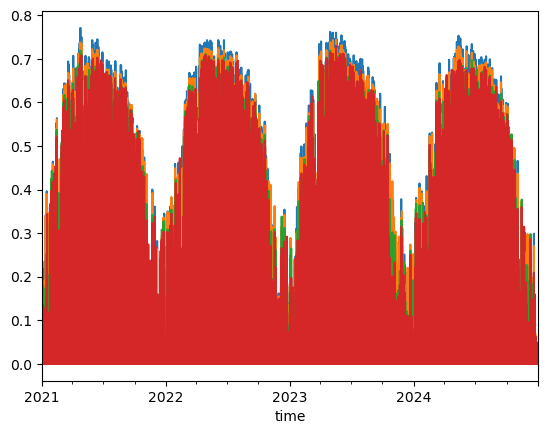

In [6]:
PV_data["DK01"]["2021":"2024"].plot()
PV_data["DK02"]["2021":"2024"].plot()
PV_data["DK03"]["2021":"2024"].plot()
PV_data["DK04"]["2021":"2024"].plot()

In [7]:
CF_solar = PV_data.mean(axis = 1) # average all the years

<Axes: xlabel='time'>

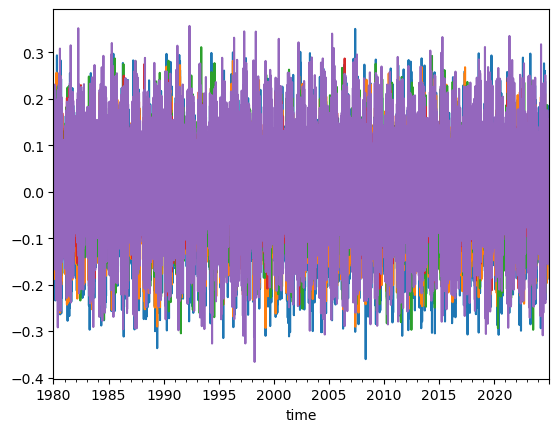

In [8]:
(CF_solar - PV_data["DK01"]).plot()
(CF_solar - PV_data["DK02"]).plot()
(CF_solar - PV_data["DK03"]).plot()
(CF_solar - PV_data["DK04"]).plot()
(CF_solar - PV_data["DK05"]).plot()

In [9]:
OnshoreWind_Data = pd.read_csv("Re_Ninja_WindOnshore_data_DK.csv",
    skiprows=3, sep=None, engine='python',
    compression='infer')

OnshoreWind_Data["time"] = pd.to_datetime(OnshoreWind_Data["time"]).dt.tz_localize(None)
OnshoreWind_Data.index = pd.DatetimeIndex(OnshoreWind_Data["time"])
OnshoreWind_Data.drop(columns = ["time"], inplace = True)
OnshoreWind_Data.columns = OnshoreWind_Data.columns.str.strip()

print(OnshoreWind_Data.head())

                     NATIONAL      DK01      DK02      DK03      DK04  \
time                                                                    
1980-01-01 00:00:00  0.100020  0.169258  0.154797  0.058525  0.082945   
1980-01-01 01:00:00  0.095627  0.157692  0.155743  0.059855  0.076598   
1980-01-01 02:00:00  0.090815  0.145822  0.156026  0.060255  0.070185   
1980-01-01 03:00:00  0.082520  0.134984  0.153629  0.058150  0.058770   
1980-01-01 04:00:00  0.071892  0.122622  0.150896  0.054550  0.042691   

                         DK05  
time                           
1980-01-01 00:00:00  0.120442  
1980-01-01 01:00:00  0.112279  
1980-01-01 02:00:00  0.103703  
1980-01-01 03:00:00  0.092318  
1980-01-01 04:00:00  0.080078  


In [10]:
CF_wind = OnshoreWind_Data.mean(axis = 1) # average of all years for the different datasets

<Axes: xlabel='time'>

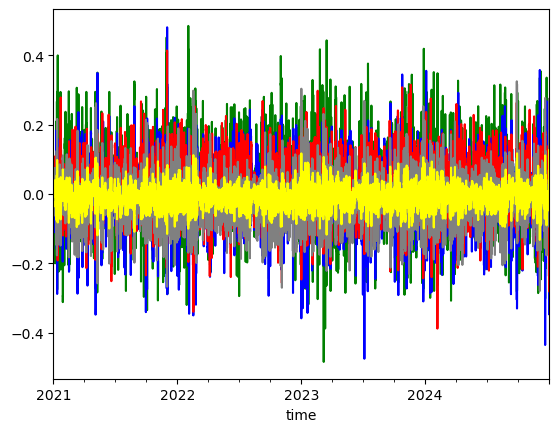

In [11]:
(CF_wind["2021":"2024"] - OnshoreWind_Data["DK01"]["2021":"2024"]).plot(color = "green")
(CF_wind["2021":"2024"] - OnshoreWind_Data["DK02"]["2021":"2024"]).plot(color = "blue")
(CF_wind["2021":"2024"] - OnshoreWind_Data["DK03"]["2021":"2024"]).plot(color = "red")
(CF_wind["2021":"2024"] - OnshoreWind_Data["DK04"]["2021":"2024"]).plot(color = "grey")
(CF_wind["2021":"2024"] - OnshoreWind_Data["NATIONAL"]["2021":"2024"]).plot(color = "yellow")

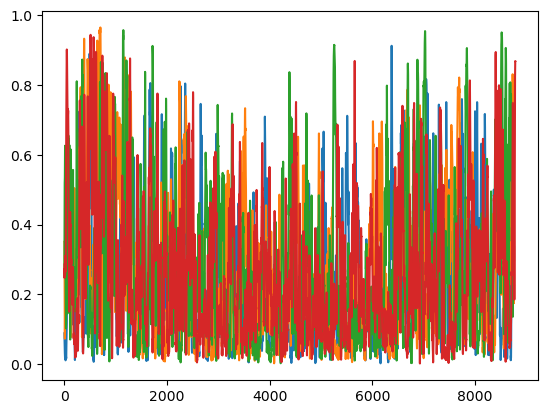

In [12]:
plt.plot(CF_wind["2021"].values)
plt.plot(CF_wind["2022"].values)
plt.plot(CF_wind["2023"].values)
plt.plot(CF_wind["2024"].values)
plt.show()

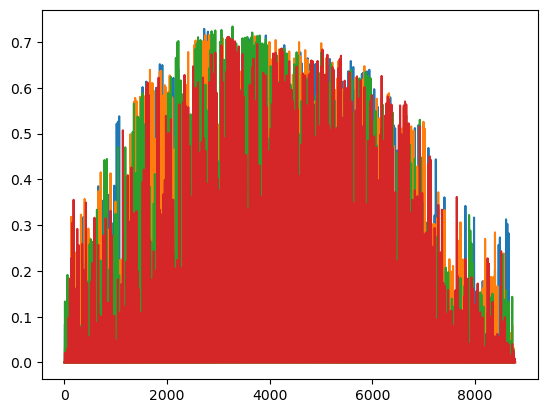

In [13]:
plt.plot(CF_solar["2021"].values)
plt.plot(CF_solar["2022"].values)
plt.plot(CF_solar["2023"].values)
plt.plot(CF_solar["2024"].values)
plt.show()

### Natural Gas Prices

In [15]:
current_dir = os.getcwd()

In [16]:
gas_file = os.path.join(current_dir, 'GasDailyBalancingPrice.xlsx')

- Pre Oct 2021, Gas Prices were constant daily from 6:00 - 6:00, per day

In [ ]:
# units is in DKK/kWh
gas_price_pre_oct_2021 = pd.read_excel("GasSystemBalanceUntil20221001.xlsx")
gas_price_pre_oct_2021.tail()

,GasDay,Created,BalanceType,Balance,ProductCode,greenZoneMin,greenZoneMax,YellowZoneMin,YellowZoneMax,GasBuyingPriceDKK,GasBuyPriceDescription,GasSellingPriceDKK,GasSellPriceDescription
15861,2022-09-30 00:00:00,2022-10-01 01:45:15,ESCB,3166032,Non valid ordinary,-3758094,12241906,-53575500,53575500,NaN,NaN,NaN,NaN
15862,2022-09-30 00:00:00,2022-09-30 22:45:23,ESCB,3537232,Non valid ordinary,-3758094,12241906,-53575500,53575500,NaN,NaN,NaN,NaN
15863,2022-09-30 00:00:00,2022-10-31 07:28:17,SCB,9310742,Valid ordinary,-3758094,12241906,-53575500,53575500,1.2558,"Adjustment of balance purchase step 1, NG-WD *...",1.2684,"Adjustment of balance sale step 1, NG-WD * ADJ..."
15864,2022-09-30 00:00:00,2022-11-09 13:28:53,SCB,9310742,Valid ordinary,-3758094,12241906,-53575500,53575500,1.2558,"Adjustment of balance purchase step 1, NG-WD *...",1.2684,"Adjustment of balance sale step 1, NG-WD * ADJ..."
15865,2022-09-30 00:00:00,2022-09-30 06:46:05,ESCB,-4450243,Non valid ordinary,-3758094,12241906,-53575500,53575500,NaN,NaN,NaN,NaN


In [19]:
# 1. Clean and Deduplicate as you did
gas_price_pre_oct_2021["GasDay"] = pd.to_datetime(gas_price_pre_oct_2021["GasDay"]).dt.tz_localize(None)
gas_price_pre_oct_2021.index = pd.DatetimeIndex(gas_price_pre_oct_2021["GasDay"])
gas_price_pre_oct_2021 = gas_price_pre_oct_2021.groupby(level=0).mean(numeric_only=True)

# 2. Add a "dummy" row to ensure the LAST day gets all 24 hours
# This adds one more day at the very end of your existing index
last_day = gas_price_pre_oct_2021.index.max()
next_day = last_day + pd.Timedelta(days=1)
gas_price_pre_oct_2021.loc[next_day] = None 

# 3. Apply the 6-hour offset for the Danish Gas Day
gas_price_pre_oct_2021.index = gas_price_pre_oct_2021.index + pd.Timedelta(hours=6)

# 4. Resample and Forward Fill
# This propagates the 06:00 price through all 24 hours of that gas day
gas_price_pre_oct_2021_hourly = gas_price_pre_oct_2021.resample('h').ffill()

# 5. Drop the very last hour (which belongs to the dummy day's 06:00 start)
gas_price_pre_oct_2021_hourly = gas_price_pre_oct_2021_hourly.iloc[:-1]

Text(0, 0.5, 'Gas Price [DKK/kWh]')

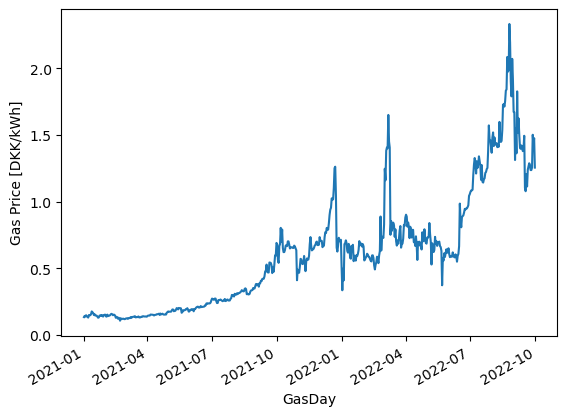

In [23]:
gas_price_pre_oct_2021["GasBuyingPriceDKK"].plot()
plt.ylabel("Gas Price [DKK/kWh]")

In [21]:
gas_price_data = pd.read_excel(gas_file)

In [22]:
# 1. Convert the 'GasDay' column to datetime and remove timezone offset
gas_price_data["GasDay"] = pd.to_datetime(gas_price_data["GasDay"]).dt.tz_localize(None)
# 2. Set the 'GasDay' column as the index
gas_price_data.index = pd.DatetimeIndex(gas_price_data["GasDay"])
# 3. Resample to hourly to match solar_pv_data (forward fill daily prices)
gas_price_hourly = gas_price_data.resample('h').ffill()

In [24]:
EUR_DKK_exchangerate =(gas_price_hourly["ExchangeRateEUR_DKK"]/100)

Text(0, 0.5, 'Gas Price [EUR/MWh]')

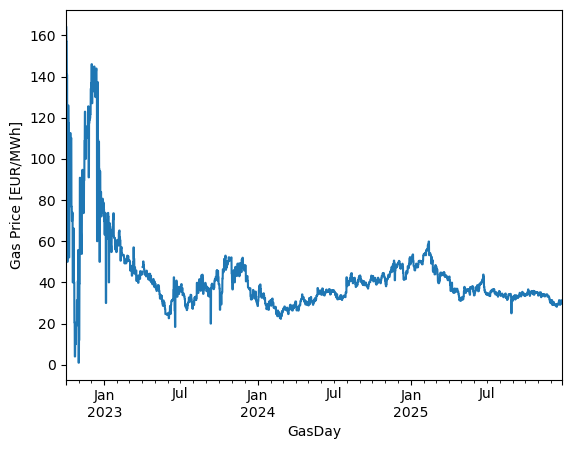

In [26]:
((gas_price_hourly["MarginalPurchasePriceDKK_kWh"]/EUR_DKK_exchangerate)*1000).plot() # EUR/MWh
plt.ylabel("Gas Price [EUR/MWh]")

In [27]:
gas_price_hourly["MarginalPurchasePriceEUR_MWh"] = ((gas_price_hourly["MarginalPurchasePriceDKK_kWh"]/EUR_DKK_exchangerate)*1000)
gas_price_hourly["MarginalPurchasePriceEUR_MWh"] 

GasDay
2022-10-01 00:00:00    164.176696
2022-10-01 01:00:00    164.176696
2022-10-01 02:00:00    164.176696
2022-10-01 03:00:00    164.176696
2022-10-01 04:00:00    164.176696
                          ...    
2025-12-26 20:00:00     30.641750
2025-12-26 21:00:00     30.641750
2025-12-26 22:00:00     30.641750
2025-12-26 23:00:00     30.641750
2025-12-27 00:00:00     29.731466
Freq: h, Name: MarginalPurchasePriceEUR_MWh, Length: 28393, dtype: float64

(462336.0, 462408.0)

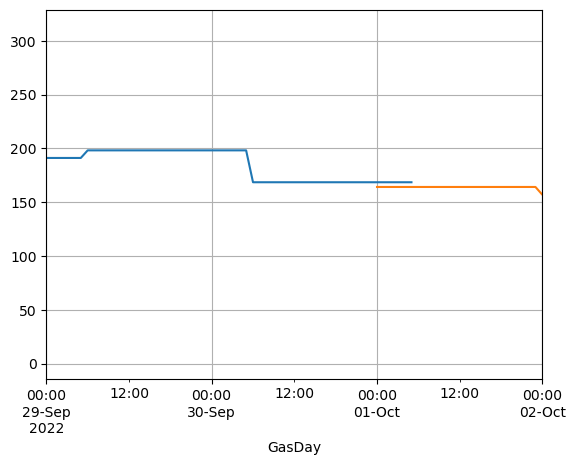

In [28]:
(gas_price_pre_oct_2021_hourly["GasBuyingPriceDKK"]*(1000/7.45)).plot()
gas_price_hourly["MarginalPurchasePriceEUR_MWh"].plot()
#elspotprices["SpotPriceEUR"].plot()
plt.grid()
plt.xlim("2022-09-29","2022-10-02")

- merging the two gas price dataset into one

In [29]:
part1 = gas_price_pre_oct_2021_hourly["GasBuyingPriceDKK"][:"2022-09-30"]*(1000/7.45)  # DKK/kwh -> EUR/MWh
part2 = gas_price_hourly["MarginalPurchasePriceEUR_MWh"] # EUR/MWh

NG_price = pd.concat([part1, part2], axis=1)

# keep='last' prioritizes data from 'part2' for the overlapping hours
NG_price = NG_price[~NG_price.index.duplicated(keep='last')].sort_index()

# 4. Fill any remaining tiny gaps (just in case)
NG_price = NG_price.resample('H').ffill()

# 1. Fill missing values in the EUR_MWh column with the DKK column values
NG_price["MarginalPurchasePriceEUR_MWh"] = NG_price["MarginalPurchasePriceEUR_MWh"].fillna(NG_price["GasBuyingPriceDKK"])

# 2. Drop the original DKK column if you no longer need it
NG_price = NG_price.drop(columns=["GasBuyingPriceDKK"])

In [30]:
gas_price_pre_oct_2021_hourly["GasBuyingPriceDKK"].isna().sum()

0

In [31]:
gas_price_hourly["MarginalPurchasePriceEUR_MWh"].isna().sum()

24

In [32]:
gas_price_hourly["MarginalPurchasePriceEUR_MWh"][gas_price_hourly["MarginalPurchasePriceEUR_MWh"].isna()]

GasDay
2023-04-01 00:00:00   NaN
2023-04-01 01:00:00   NaN
2023-04-01 02:00:00   NaN
2023-04-01 03:00:00   NaN
2023-04-01 04:00:00   NaN
2023-04-01 05:00:00   NaN
2023-04-01 06:00:00   NaN
2023-04-01 07:00:00   NaN
2023-04-01 08:00:00   NaN
2023-04-01 09:00:00   NaN
2023-04-01 10:00:00   NaN
2023-04-01 11:00:00   NaN
2023-04-01 12:00:00   NaN
2023-04-01 13:00:00   NaN
2023-04-01 14:00:00   NaN
2023-04-01 15:00:00   NaN
2023-04-01 16:00:00   NaN
2023-04-01 17:00:00   NaN
2023-04-01 18:00:00   NaN
2023-04-01 19:00:00   NaN
2023-04-01 20:00:00   NaN
2023-04-01 21:00:00   NaN
2023-04-01 22:00:00   NaN
2023-04-01 23:00:00   NaN
Freq: h, Name: MarginalPurchasePriceEUR_MWh, dtype: float64

- we were missing data for one of the days, so we will interpolate the missing data

<Axes: xlabel='GasDay'>

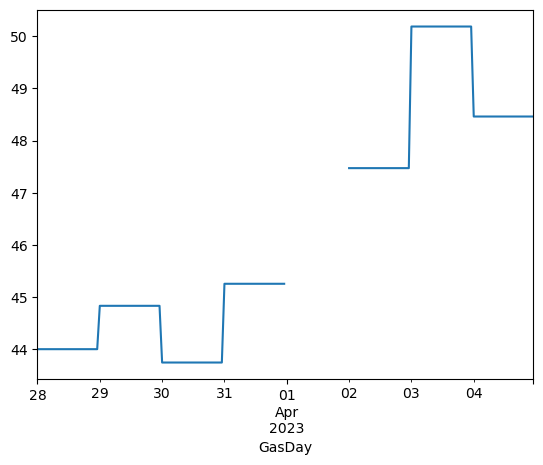

In [33]:
gas_price_hourly["MarginalPurchasePriceEUR_MWh"]["2023-03-28":"2023-04-04"].plot()

<Axes: xlabel='GasDay'>

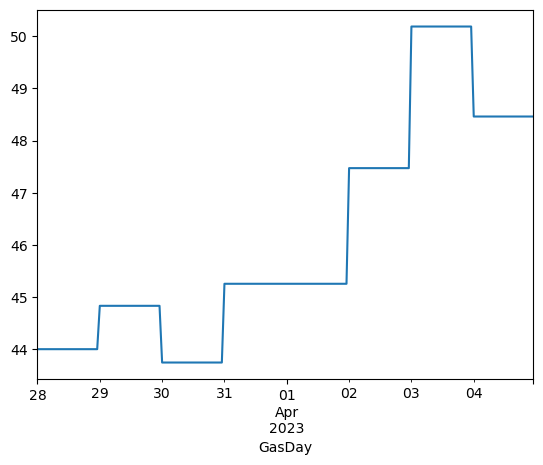

In [34]:
NG_price["MarginalPurchasePriceEUR_MWh"]["2023-03-28":"2023-04-04"].ffill().plot()

In [36]:
NG_price["MarginalPurchasePriceEUR_MWh"] = NG_price["MarginalPurchasePriceEUR_MWh"].ffill() 

<Axes: xlabel='GasDay'>

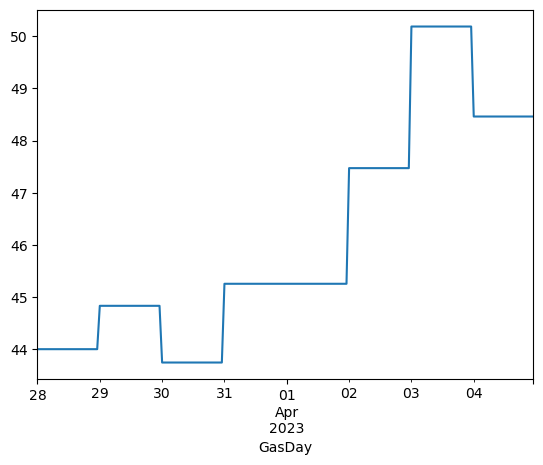

In [37]:
NG_price["MarginalPurchasePriceEUR_MWh"]["2023-03-28":"2023-04-04"].plot()

In [39]:
NG_price.isna().sum()

MarginalPurchasePriceEUR_MWh    0
dtype: int64

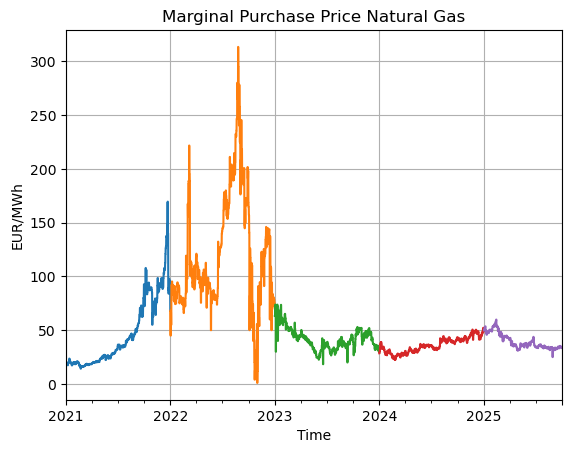

In [42]:
NG_price["MarginalPurchasePriceEUR_MWh"]["2021"].plot()
NG_price["MarginalPurchasePriceEUR_MWh"]["2022"].plot()
NG_price["MarginalPurchasePriceEUR_MWh"]["2023"].plot()
NG_price["MarginalPurchasePriceEUR_MWh"]["2024"].plot()
NG_price["MarginalPurchasePriceEUR_MWh"]["2025"].plot()
#elspotprices["SpotPriceEUR"].plot()
plt.xlabel("Time")
plt.ylabel("EUR/MWh")
plt.xlim("2021-01-01", "2025-09-30")
plt.title("Marginal Purchase Price Natural Gas")
plt.grid()

### Electricity Spot Prices

In [49]:
"full spot price data el DK1";
elspotprices = pd.read_excel("Elspotprices1999_onwards.xlsx", index_col=0, parse_dates=True) # EUR/MWh

In [44]:
DKK_Euro = 7.468  #https://www.ecb.europa.eu/stats/policy_and_exchange_rates/euro_reference_exchange_rates/html/eurofxref-graph-dkk.en.html

el_transmission_tariff = 4.3 / 100 * 1000 / DKK_Euro   # from energinet inputs in Ore/kWh DKK/MWh, bef 7.5
el_system_tariff = 7.2 / 100 * 1000 / DKK_Euro   # bef 5.1
el_afgift =  0.8 / 100 * 1000 / DKK_Euro         # bef 76.1 https://skm.dk/tal-og-metode/satser/satser-og-beloebsgraenser-i-lovgivningen/elafgiftsloven  https://elberegner.dk/guides/elafgift/
 
# DSO Tariff -  for 60/10kV transformer (A_low customer) #Staring from January 2026 https://n1.dk/elnetkunder/kommende-priser
el_net_tariff_low = 1.54  / 100 * 1000 / DKK_Euro   # Ore/kWh to eur/MWh
el_net_tariff_high = 4.63 / 100 * 1000 / DKK_Euro
el_net_tariff_peak = 9.27 / 100 * 1000 / DKK_Euro

VAT = 0.25 # 25 % VAT (Value Added Tax)

- function to generate import/export prices

In [ ]:
"Historical transmission and system tariffs";
#  https://view.officeapps.live.com/op/view.aspx?src=https%3A%2F%2Fenerginet.dk%2Fmedia%2Flgomsk12%2Feltarif-arkiv-2026.xlsx&wdOrigin=BROWSELINK
"Historical Peak Load tariffs";
#  https://n1.dk/elnetkunder/tidligere-priser

In [47]:
from types import SimpleNamespace

In [84]:
"øre/kWh";
tariff_el_use = {
    "2021": {
        "el_transmission_tariff": 4.9,
        "el_system_tariff": 6.1,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.123)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 2.09,         # Net Tariff: Lavlast
        "el_tariff_high": 4.80,        # Net Tariff: Højlast
        "el_tariff_peak": 7.92         # Net Tariff: Spidslast
    },
     "2022": {
        "el_transmission_tariff": 4.9,
        "el_system_tariff": 6.1,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.116)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 4.51,         # Net Tariff: Lavlast
        "el_tariff_high": 8.32,        # Net Tariff: Højlast
        "el_tariff_peak": 12.15         # Net Tariff: Spidslast
    },
    "2023": {
        "el_transmission_tariff": 5.8,
        "el_system_tariff": 5.4,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.16)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 2.43,         # Net Tariff: Lavlast
        "el_tariff_high": 4.80,        # Net Tariff: Højlast
        "el_tariff_peak": 7.33         # Net Tariff: Spidslast
    },
    "2024": {
        "el_transmission_tariff": 7.4,
        "el_system_tariff": 5.1,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.24)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 0.85,         # Net Tariff: Lavlast
        "el_tariff_high": 2.54,        # Net Tariff: Højlast
        "el_tariff_peak": 5.08,         # Net Tariff: Spidslast
    }

}

In [83]:
tariff_el_use["2023"]["el_transmission_tariff"]
#tariff_el_use["2022"]["el_prod_tariff"]

5.8

In [110]:
import pandas as pd
def build_electricity_grid_price_w_tariff(Elspotprices, tariff_dict, year):
    # 1. Year Filter & Column Selection (Fixes DateParseError)
    year_str = str(year)
    spot = Elspotprices.loc[Elspotprices.index.year == int(year_str), "SpotPriceEUR"]
    
    # 2. Settings & Conversion (øre/kWh to EUR/MWh)
    d = tariff_dict[year_str]
    DKK_to_EUR_MWh = 10 / 7.45 
    
    # 3. Define Logic Windows
    hours = spot.index
    is_winter = hours.month.isin([1, 2, 3, 10, 11, 12])
    is_peak_time = hours.hour.isin(range(17, 21)) # 17:00 to 20:59
    is_day_time = hours.hour.isin(range(6, 24))   # 06:00 to 23:59

    # 4. Apply Net Tariff Levels
    net_tariff = pd.Series(d["el_tariff_low"], index=hours)
    net_tariff.loc[is_day_time] = d["el_tariff_high"]
    net_tariff.loc[is_winter & is_peak_time] = d["el_tariff_peak"]

    # 5. Calculate Final Prices
    fixed_fees = d["el_transmission_tariff"] + d["el_system_tariff"] + d["el_tax"]
    buy_price = spot + (fixed_fees + net_tariff) * DKK_to_EUR_MWh
    
    # Selling = Spot minus production costs
    sell_price = -spot + (d["el_prod_tariff"] * DKK_to_EUR_MWh)

    return buy_price, sell_price

In [111]:
import_price21, export_price21 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2021")
import_price22, export_price22 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2022")
import_price23, export_price23 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2023")
import_price24, export_price24 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2024")



<Axes: xlabel='HourUTC'>

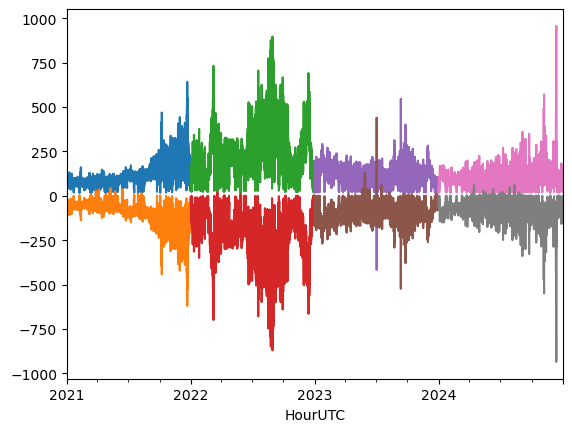

In [123]:

#elspotprices["2021":"2024"].plot(color = "black", linestyle = "--")
import_price21.plot()
export_price21.plot()
import_price22.plot()
export_price22.plot()
import_price23.plot()
export_price23.plot()
import_price24.plot()
export_price24.plot()

Text(0, 0.5, 'EUR/MWh')

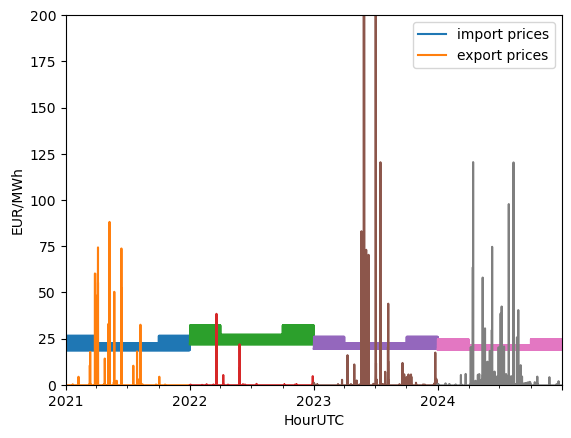

In [136]:
(import_price21 - elspotprices["SpotPriceEUR"]["2021"]).plot(label = "import prices")
(abs(export_price21) - elspotprices["SpotPriceEUR"]["2021"]).plot(label = "export prices")
plt.legend()
(import_price22 - elspotprices["SpotPriceEUR"]["2022"]).plot()
(abs(export_price22) - elspotprices["SpotPriceEUR"]["2022"]).plot()
(import_price23 - elspotprices["SpotPriceEUR"]["2023"]).plot()
(abs(export_price23) - elspotprices["SpotPriceEUR"]["2023"]).plot()
(import_price24 - elspotprices["SpotPriceEUR"]["2024"]).plot()
(abs(export_price24) - elspotprices["SpotPriceEUR"]["2024"]).plot()
plt.ylim(0,200)
plt.ylabel("EUR/MWh")

In [ ]:
def build_electricity_grid_price_w_tariff(Elspotprices, year_data, price_year, DKK_Euro=7.45):
    """
    Inputs:
        Elspotprices : pd.Series (EUR/MWh) indexed by DatetimeIndex
        year_data    : Dict containing tariffs for a specific year (in øre/kWh)
        price_year   : Integer (e.g., 2017) to define seasonal splits
    """
    
    # --- 1. CONVERSION HELPER ---
    # Converts øre/kWh to EUR/MWh
    def to_eur_mwh(ore_kwh):
        return (ore_kwh / 100) * 1000 / DKK_Euro

    # --- 2. FIXED COMPONENTS ---
    # These apply to every hour regardless of time
    fixed_buy_charge = to_eur_mwh(
        year_data["el_transmission_tariff"] + 
        year_data["el_system_tariff"] + 
        year_data["el_tax"]
    )
    
    # Production tariff reduces the revenue you get from selling
    prod_charge = to_eur_mwh(year_data["el_prod_tariff"])

    # --- 3. SEASONAL DEFINITIONS ---
    hours = Elspotprices.index
    summer_start = pd.Timestamp(f"{price_year}-04-01 00:00", tz=hours.tz)
    summer_end   = pd.Timestamp(f"{price_year}-10-01 00:00", tz=hours.tz)
    
    is_summer = (hours >= summer_start) & (hours < summer_end)
    is_weekend = hours.weekday >= 5
    
    # --- 4. TARIFF LOGIC ---
    # Define ranges for Lavlast, Højlast, and Spidslast
    peak_hours = range(17, 21) # 17:00-20:59 (Standard Danish Spidslast)
    high_hours = range(6, 24)  # 06:00-23:59 (Standard Danish Højlast)

    def get_net_tariff(h):
        hr = h.hour
        month_is_summer = (h >= summer_start) and (h < summer_end)
        weekend = h.weekday() >= 5

        if not month_is_summer:
            # WINTER
            if not weekend and hr in peak_hours:
                return year_data["el_tariff_peak"]
            elif hr in high_hours:
                return year_data["el_tariff_high"]
            else:
                return year_data["el_tariff_low"]
        else:
            # SUMMER
            if not weekend and hr in high_hours:
                return year_data["el_tariff_high"]
            else:
                return year_data["el_tariff_low"]

    # Generate the time-varying network tariff
    net_tariffs_ore = pd.Series([get_net_tariff(h) for h in hours], index=hours)
    net_tariffs_eur = net_tariffs_ore.apply(to_eur_mwh)

    # --- 5. FINAL PRICES ---
    final_buy_price = Elspotprices + fixed_buy_charge + net_tariffs_eur
    
    # Selling Price = Spot Price - Production Tariffs
    final_sell_price = Elspotprices - prod_charge

    return final_buy_price, final_sell_price

In [48]:
p = SimpleNamespace(

    # Model year (for defining summer/winter periods)
    En_price_year = 2017,

    # Full analysis period
    start_date = "2017-01-01",
    end_date   = "2018-01-01",

    # Fixed tariffs (constant every hour)
    el_transmission_tariff =  4.3 / 100 * 1000 / DKK_Euro , # 
    el_system_tariff       =  7.2 / 100 * 1000 / DKK_Euro,
    el_afgift              = 0.8 / 100 * 1000 / DKK_Euro   ,

    # Selling tariff (when exporting to grid)
    el_tariff_sell = (0.5 + 0.53)/100 * 1000 / DKK_Euro,  # Average of 0.5 and 0.53 DKK/kWh

    # Variable tariff levels
    el_net_tariff_low  = 1.54  / 100 * 1000 / DKK_Euro,
    el_net_tariff_high = 4.63 / 100 * 1000 / DKK_Euro,
    el_net_tariff_peak = 9.27 / 100 * 1000 / DKK_Euro
)

# 2. PRICE CALCULATION FUNCTION
# ============================================================
def build_electricity_grid_price_w_tariff(Elspotprices):
    """
    Inputs:
        Elspotprices : pd.Series indexed by DatetimeIndex (HourUTC)
    Output:
        (final_grid_buy_price, grid_sell_price)
    """
    # ---- Base buy price (fixed tariffs only) ----
    base_price = (Elspotprices
        + p.el_transmission_tariff
        + p.el_system_tariff
        + p.el_afgift)

    # ---- Grid selling price ----
    sell_price = -Elspotprices + p.el_tariff_sell

    # Use timestamps directly from your Series
    hours = Elspotprices.index

    # ---- SUMMER ----
    summer_start = pd.Timestamp(f"{p.En_price_year}-04-01 00:00", tz=hours.tz)
    summer_end   = pd.Timestamp(f"{p.En_price_year}-10-01 00:00", tz=hours.tz)

    summer = hours[(hours >= summer_start) & (hours < summer_end)]

    # ---- WINTER = all other hours ----
    winter = hours.difference(summer)

    # Remove Feb 29
    winter = winter[~((winter.month == 2) & (winter.day == 29))]

    # ---- Tariff rules ----
    peak_hours          = range(7, 22)     # 06–21
    high_wd_winter      = range(22, 25)    # 21–23
    high_we_winter      = range(7, 25)     # 06–23
    high_wd_summer      = range(7, 25)     # 06–23

    # ---- Tariff decision function ----
    def tariff(h):
        wd = h.weekday()   # 0=Mon … 6=Sun
        hr = h.hour

        if h in winter:
            # WINTER
            if wd >= 5:  # weekend
                return p.el_net_tariff_high if hr in high_we_winter else p.el_net_tariff_low
            else:
                if hr in peak_hours:
                    return p.el_net_tariff_peak
                elif hr in high_wd_winter:
                    return p.el_net_tariff_high
                else:
                    return p.el_net_tariff_low

        else:
            # SUMMER
            if wd >= 5:  # weekend
                return p.el_net_tariff_low
            else:
                return p.el_net_tariff_high if hr in high_wd_summer else p.el_net_tariff_low

    # ---- Hourly tariff series ----
    tariffs = pd.Series({h: tariff(h) for h in hours})

    # ---- Final buy price ----
    final_price = base_price + tariffs

    return final_price, sell_price

In [50]:
import_price, export_price = build_electricity_grid_price_w_tariff(elspotprices["SpotPriceEUR"])

<Axes: xlabel='HourUTC'>

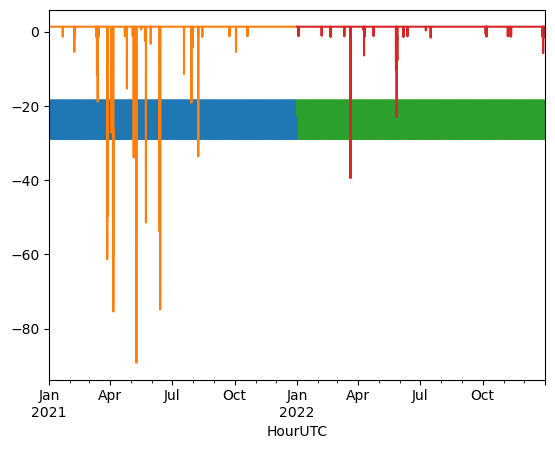

In [69]:
(elspotprices["SpotPriceEUR"]["2021"] - import_price["2021"]).plot()
(elspotprices["SpotPriceEUR"]["2021"] - abs(export_price["2021"])).plot()
(elspotprices["SpotPriceEUR"]["2022"] - import_price["2022"]).plot()
(elspotprices["SpotPriceEUR"]["2022"] - abs(export_price["2022"])).plot()

<Axes: xlabel='HourUTC'>

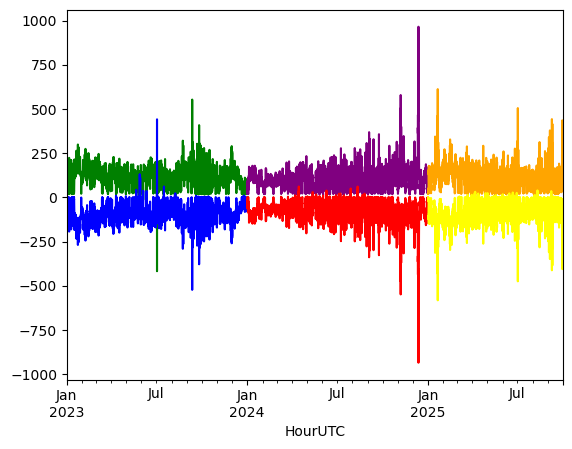

In [51]:
import_price["2023"].plot(color = "green")
import_price["2024"].plot(color = "purple")
import_price["2025"].plot(color = "orange")
export_price["2023"].plot(color = "blue")
export_price["2024"].plot(color = "red")
export_price["2025"].plot(color = "yellow")

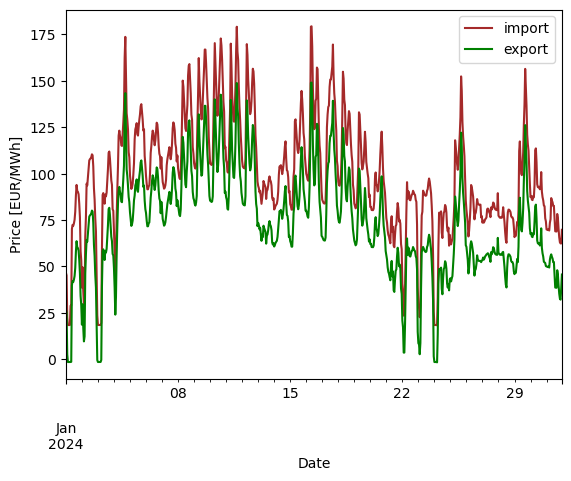

In [52]:
import_price["2024-01-01":"2024-01-31"].plot(color = "brown", label = "import")
(-export_price["2024-01-01":"2024-01-31"]).plot(color = "green", label = "export") 
plt.xlabel("Date")
plt.ylabel("Price [EUR/MWh]")
plt.legend()

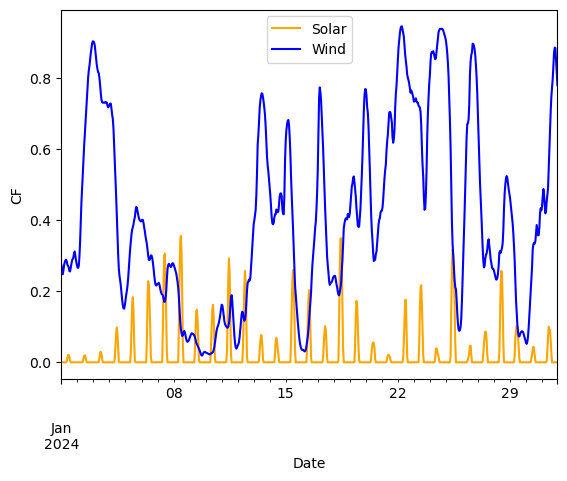

In [53]:
CF_solar["2024-01-01":"2024-01-31"].plot(color = "orange", label = "Solar")
CF_wind["2024-01-01":"2024-01-31"].plot(color = "blue", label = "Wind") 
plt.xlabel("Date")
plt.ylabel("CF")
plt.legend()

## HeatMaps

In [241]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_pypsa_heatmap(data, title="PyPSA Heatmap", unit="Value", cmap="viridis", ax=None, vmin=None, vmax=None):
    """
    Added vmin and vmax for manual scale control.
    """
    if isinstance(data, pd.DataFrame):
        plot_data = data.mean(axis=1)
    else:
        plot_data = data

    df = plot_data.to_frame(name="values")
    df["date"] = df.index.date
    df["hour"] = df.index.hour
    
    pivot = df.pivot_table(index="date", columns="hour", values="values", aggfunc='mean')

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))

    # Pass vmin and vmax here
    sns.heatmap(pivot, cmap=cmap, cbar_kws={'label': unit}, ax=ax, 
                rasterized=True, vmin=vmin, vmax=vmax)
    
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Date")

### Intialisation of Model and Components

In [137]:
def get_time_period(start='2017-01-01', end='2017-12-31', freq='h', tz_naive=True):
    """
    Generates a pandas DatetimeIndex for a specified period.

    Args:
        start (str): Start date/time (e.g., '2017-01-01' or '2017-01-01 00:00Z')
        end (str): End date/time
        freq (str): Frequency (default 'h' for hourly)
        tz_naive (bool): If True, removes timezone info (localized to None)
        
    Returns:
        pd.DatetimeIndex
    """
    # Create the range
    dr = pd.date_range(start=start, end=end, freq=freq)
    
    # Strip timezone if requested
    if tz_naive and dr.tz is not None:
        dr = dr.tz_localize(None)
    elif tz_naive and dr.tz is None:
        # Even if not localized, ensure it's naive if strings had offsets
        dr = dr.tz_localize(None)
        
    return dr

In [138]:
time_period = get_time_period('2023-01-01 00:00Z', '2023-12-31 23:00Z', freq = "h")
time_period

DatetimeIndex(['2023-01-01 00:00:00', '2023-01-01 01:00:00',
               '2023-01-01 02:00:00', '2023-01-01 03:00:00',
               '2023-01-01 04:00:00', '2023-01-01 05:00:00',
               '2023-01-01 06:00:00', '2023-01-01 07:00:00',
               '2023-01-01 08:00:00', '2023-01-01 09:00:00',
               ...
               '2023-12-31 14:00:00', '2023-12-31 15:00:00',
               '2023-12-31 16:00:00', '2023-12-31 17:00:00',
               '2023-12-31 18:00:00', '2023-12-31 19:00:00',
               '2023-12-31 20:00:00', '2023-12-31 21:00:00',
               '2023-12-31 22:00:00', '2023-12-31 23:00:00'],
              dtype='datetime64[ns]', length=8760, freq=None)

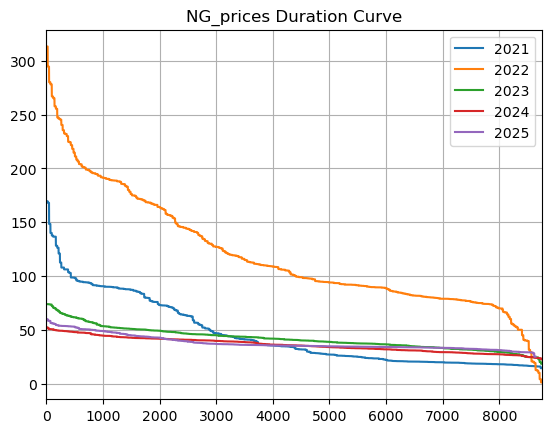

In [139]:
plt.plot(np.sort(NG_price["MarginalPurchasePriceEUR_MWh"]["2021"])[::-1])
plt.plot(np.sort(NG_price["MarginalPurchasePriceEUR_MWh"]["2022"])[::-1])
plt.plot(np.sort(NG_price["MarginalPurchasePriceEUR_MWh"]["2023"])[::-1])
plt.plot(np.sort(NG_price["MarginalPurchasePriceEUR_MWh"]["2024"])[::-1])
plt.plot(np.sort(NG_price["MarginalPurchasePriceEUR_MWh"]["2025"])[::-1])
plt.legend(["2021", "2022", "2023", "2024", "2025"])
plt.title("NG_prices Duration Curve")
#plt.ylim(-200,800)
plt.xlim(0,8760)
plt.grid()

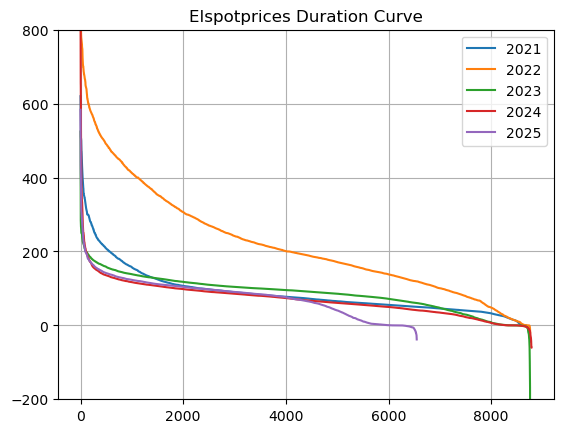

In [140]:
plt.plot(np.sort(elspotprices2["SpotPriceEUR"]["2021"])[::-1])
plt.plot(np.sort(elspotprices2["SpotPriceEUR"]["2022"])[::-1])
plt.plot(np.sort(elspotprices2["SpotPriceEUR"]["2023"])[::-1])
plt.plot(np.sort(elspotprices2["SpotPriceEUR"]["2024"])[::-1])
plt.plot(np.sort(elspotprices2["SpotPriceEUR"]["2025"])[::-1])
plt.legend(["2021", "2022", "2023", "2024", "2025"])
plt.title("Elspotprices Duration Curve")
plt.ylim(-200,800)
#plt.xlim(0,1000)
plt.grid()

In [170]:
def add_carriers(n):
    #n.add("Carrier",'electricity grid im')
    #n.add("Carrier","electricity grid ex") 
    n.add("Carrier","onshorewind")
    n.add("Carrier","solar")
    n.add("Carrier","electric boiler")
    #n.add("Carrier","Rondo charge")
    #n.add("Carrier","Rondo store")
    #n.add("Carrier","Rondo discharge")
    n.add("Carrier","heat")
    n.add("Carrier","battery storage")
    n.add("Carrier","electricity")
    n.add("Carrier","gas") # co2_emissions=0.206tonnes/MWh   # for NG boiler # Assume that methane gas emits 0.198 tCO2 per MWh of thermal energy contained in the gas. 
    n.add("Carrier", "pellets") 
    n.add("Carrier", "CO2") #co2_emissions=-0.164 (tCO2/MWh_pell) #for biochar # -0.164 ????
    n.add("Carrier", "pyrolysis")
    n.add("Carrier", "hydrogen")
    n.add("Carrier", "methanol")

In [171]:
def add_skive_generators(n,s_cf,w_cf):

    # EuroWind Owns These Assets
    n.add("Generator", "Skive_Solar", carrier="solar",
        bus = "EuroWind" ,
        capital_cost=costs.at["solar", "capital_cost"],
        marginal_cost=costs.at["solar", "marginal_cost"], 
        p_max_pu= s_cf, 
        p_nom = 36)


    n.add("Generator","Skive_Onshore_Wind", carrier="onshorewind",
        bus = "EuroWind",
        capital_cost=costs.at["onwind", "capital_cost"],
        marginal_cost=costs.at["onwind", "marginal_cost"],
        p_max_pu= w_cf,
        p_nom = 54)

    #--------------------------------
    # PPA link
    n.add("Link", "PPA",
          bus0="EuroWind",
          bus1="Greenlab",
          p_nom_extendable=True,
          efficiency=0.97,
          p_min_pu=0,
          p_max_pu=1.0,
          carrier="electricity")

In [172]:
def add_grid(n, price_import, price_export):
    #------ IMPORTS ----------------------------
    n.add("Generator", "Grid_Generator",
          bus="Grid_Import",
          p_nom_extendable=True,
          efficiency=1.0,
          marginal_cost=5e-6,
          capital_cost=0.0,
          carrier="electricity")

    n.add("Link", "Imports",
          bus0="Grid_Import",
          bus1="EuroWind",
          p_nom=84,
          p_nom_extendable=False,
          efficiency=0.97,
          p_min_pu=0,
          p_max_pu=1.0,
          carrier="electricity",
          marginal_cost=price_import)

    #------- EXPORTS -----------------------
    n.add("Store", "Grid_Store",
          bus="Grid_Export",
          e_nom_extendable=True,
          capital_cost=0.0,
          standing_loss=0.0,
          carrier="electricity")

    n.add("Link", "Exports",
          bus0="EuroWind",
          bus1="Grid_Export",
          p_nom=84,
          p_nom_extendable=False,
          efficiency=0.97,
          p_min_pu=0,
          p_max_pu=1.0,
          carrier="electricity",
          marginal_cost=price_export)

In [173]:
def add_battery(n,P_nom, max_t, cyclic_operation = True):
    n.add("StorageUnit",
        "Skive_Battery",
        bus="EuroWind",  # Use your electricity bus name
        carrier="battery storage",
        max_hours= max_t,  # 22 MW * 2 h = 44 MWh
        capital_cost=costs.at["battery inverter", "capital_cost"] + 4 * costs.at["battery storage", "capital_cost"],
        efficiency_store = 0.90, # Charging Efficiency
        efficiency_dispatch=costs.at["battery inverter", "efficiency"], # Discharging Efficiency
        p_nom= P_nom,  # 22 MW
        p_nom_extendable=False,
        cyclic_state_of_charge=cyclic_operation)

In [174]:
"High Temprature Bus (350)";
def add_TES_rondo(n,e_nom_store = 100, p_nom_charge= 24,p_nom_discharge = 7):
    n.add("Store", "Rondo_Concrete_Heat_Storage",
        bus="TES_Rondo",
        e_nom= e_nom_store, # MWh
        e_nom_extendable=False,
        e_initial=0,
        e_cyclic=True,
        standing_loss= 1.2/100, # 1.2% per hour
        capital_cost=costs.at["Concrete-store", "capital_cost"] )      

    # "Charging of Rondo ,  El_Bus -> TES_Rondo";
    n.add("Link",
        "El_to_TES_Rondo",
        bus0="Greenlab",
        bus1="TES_Rondo",
        p_nom_extendable=False,
        p_nom = p_nom_charge, # MW
        efficiency=0.98,
        carrier = "electricity",
        capital_cost=costs.at["Concrete-charger", "capital_cost"])

    # "Discharging of Rondo , TES_Rondo -> Heat_Bus_Skive";
    n.add("Link",
        "TES_Rondo_to_Heat_Bus_Skive",
        bus0="TES_Rondo",
        bus1="Heat_Exchanger_Bus",
        p_nom = p_nom_discharge,
        p_nom_extendable=False,
        efficiency=0.90,
        capital_cost=costs.at["Concrete-discharger", "capital_cost"])

In [175]:
# 2 Heat Exchanger hence effincecy = 0.9*0.9 = 0.81
def add_heat_exchanger(n):
    n.add("Link", "Heat_Exchanger_Rondo",
     bus0="Heat_Exchanger_Bus",
     bus1="Heat_MT", 
     carrier="heat", 
     p_nom_extendable=True , 
     efficiency=0.8)

In [176]:
"Medium Temprature (150 C)";
def  add_electric_boiler(n):
    "Boiler at Skive";
    n.add("Link","Boiler_Skive",
        bus0 = "Greenlab",
        bus1="Heat_MT",
        p_nom = 10, # MW
        efficiency=0.9,
        carrier = "electric boiler",
        capital_cost=costs.at["electric boiler steam","capital_cost"])

In [177]:
# DH_Price = 40 - 60 EUR/MWh
def add_heat_load(n,p_load,DH_cost):

    n.add("Link","MT_Heat_Supply",
        bus0="Heat_MT",
        bus1="Heat_Sink",
        p_nom_extendable=True,
        carrier = "heat",
        marginal_cost = -DH_cost,) # MWh

    n.add("Load", "Skive_Heat_Load", 
        bus="Heat_Sink",
        p_nom_extendable=False,
        carrier = "heat",
        p_set = p_load) # MWh

In [178]:
def add_NG_boiler(n,CO2tax, NG_price):
     n.add("Generator",
        "NG grid",
        bus="NG",
        carrier="gas",
        p_nom = 6,
        marginal_cost = NG_price + CO2tax, #0.206  tCO2/MWh *  80EUR/tC02 + VOM 1.007EUR/MWh
        p_nom_extendable=False,)

     n.add("Link","NG boiler",
        bus0="NG",
        bus1="Heat_MT",
        efficiency=0.98,
        p_nom=6,
        p_nom_extendable=False,
        capital_cost=5772) 
    

In [179]:
def add_SkyClean(n,CO2tax):  
    n.add("Generator",
        "pellets input",
        bus="pellets",
        carrier="pellets",
        p_nom_extendable=True,
        marginal_cost= 62) #€/MWh (Price of straw pellets 380 €/t
    
    n.add("Link",
        "pyrolysis",
        bus0="pellets",
        bus1="Heat_MT",
        bus2="Greenlab",
        bus3="biochar",
        efficiency= 3.7859/7.6748, #"biochar pyrolysis", "heat output" (MWh_th/t_CO2)/ "biochar pyrolysis", "biomass input (MWh_biomass/t_CO2), #bus1 devided by bus0.
        efficiency2= -0.3184/7.6748,   #-"biochar pyrolysis", "electricity input"] (MWh_e/t_CO2) / "biochar pyrolysis", "biomass input"(MWh_biomass/t_CO2),
        efficiency3=  1/7.6748,  #1 / "biochar pyrolysis", "biomass input,
        marginal_cost= 2.5909/7.6748, #"biomass HOP", "VOM" (EUR/MWh)/ "biochar pyrolysis", "biomass input"(MWh_biomass/t_CO2)? #     
        p_nom_extendable=False,
        p_nom=2,
        carrier="pyrolysis",
        capital_cost=233477) 

    
    n.add("Link",
        "biochar sequestration",
        bus0="biochar",
        bus1="biochar sequestration",
        efficiency=1,
        p_nom_extendable = True,
        marginal_cost=-0.164*CO2tax,   #CO2 tax   or -0.164 (tCO2/MWh_pell)?  # -1  * co2_credits #-13.12eur/MWh
        carrier="CO2") 

    n.add(
        "Store",
        "biochar sequestred",
        bus="biochar sequestration",
        e_nom_extendable=True,
        e_cyclic=False,
        carrier="CO2")

In [180]:
eff_h2 = 1 / costs.at["methanolisation", "hydrogen-input"]
costs.at["methanolisation", "capital_cost"] * eff_h2

76923.19118253235

In [181]:
"Methanolisation";
def add_methanolisation(n):
    n.add("Link",
     "methanolisation",
     bus0 = "H2_Bus",
     bus1 = "methanol_bus",
     bus2 = "Greenlab",
     bus3 = "biochar sequestration",
     p_nom = 10, # 10 MW methanol plant
     p_min_pu = 0.2,
     carrier = "methanol",
     capital_cost = costs.at["methanolisation", "capital_cost"] * eff_h2,
     efficiency = eff_h2, 
     efficiency2 = -costs.at["methanolisation", "electricity-input"]*eff_h2,
     efficiency3 = -costs.at["methanolisation", "carbondioxide-input"]*eff_h2, 
     )

    n.add("Store",
    "methanol storage",
    bus="methanol_bus",
    carrier="methanol",
    capital_cost=costs.at["General liquid hydrocarbon storage (crude)", "capital_cost"] / (15.6 * 1000 / 3600),
    e_nom_extendable=True,
    e_cyclic=True,
)

In [182]:
"Adding Electrolyser"
def add_electrolyser(n, P_elec):
    n.add("Link",
    "Electrolyser",
    bus0 = "Greenlab",
    bus1 = "H2_Bus",
    p_nom = P_elec,
    p_nom_extendable = True,
    #p_nom_min = , 
    #p_nom_max = ,
    capital_cost = costs.at["Alkaline electrolyzer medium size", "capital_cost"],
    marginal_cost = costs.at["Alkaline electrolyzer medium size", "marginal_cost"],
    efficiency = 0.6,)

    n.add("Store",
    "H2_Storage",
    bus = "H2_Bus",
    e_nom_extendable = True,
    e_cylic = True)

In [183]:
#Fixed demand
def add_el_load(n,p_el):
    "Adding the Localised Demand in Greenlab Skive";
    n.add("Load",  "Skive_el_Load", 
        bus="Greenlab", 
        p_set= p_el,
        carrier = "electricity") #MWh

In [206]:
def build_network(P_el,P_heat,CO2_tax1, CO2_tax2,p_import,p_export,NG_price,horizon):
     
    n = pypsa.Network()
    #hours = get_time_period('2023-01-01 00:00Z', '2023-12-31 23:00Z', freq = "h")
    #n.set_snapshots(hours)½
    n.set_snapshots(NG_price.index)


    # Use .loc[n.snapshots] to ensure data perfectly matches the network's time index
    s_cf = CF_solar.loc[n.snapshots].values
    w_cf = CF_wind.loc[n.snapshots].values
    p_import = p_import.loc[n.snapshots].values
    p_export = p_export.loc[n.snapshots].values

    add_carriers(n)

    n.add("Bus", "Greenlab", carrier = "electricity")
    n.add("Bus", "EuroWind", carrier = "electricity")
    n.add("Bus", "Grid_Import", carrier = "electricity")
    n.add("Bus", "Grid_Export", carrier = "electricity")
    
    n.add("Bus", "H2_Bus", carrier = "hydrogen")

    n.add("Bus", "Heat_Exchanger_Bus", carrier = "heat")
    n.add("Bus","TES_Rondo", carrier = "heat")
    n.add("Bus", "Heat_MT", carrier = "heat")
    n.add("Bus","Heat_Sink", carrier = "heat")

    n.add("Bus", "NG", carrier = "gas")
    n.add("Bus", "pellets", carrier="pellets")
    n.add("Bus", "biochar", carrier="CO2")
    n.add("Bus", "biochar sequestration", carrier="CO2")

    #n.add("Bus", "methanol_bus", carrier="methanol")


    add_battery(n,P_nom = 22, max_t = 2, cyclic_operation = True)
    add_skive_generators(n,s_cf,w_cf) # 90 EUR/MWh
    add_grid(n,p_import,p_export)

    add_el_load(n,P_el)
    add_heat_load(n,P_heat,DH_cost = 0) # 50 EUR/MWh

    add_electrolyser(n, P_elec = 12)

    add_TES_rondo(n,e_nom_store = 100, p_nom_charge= 24,p_nom_discharge = 7)
    add_heat_exchanger(n)
    add_electric_boiler(n)
    add_NG_boiler(n,CO2_tax1,NG_price)
    add_SkyClean(n,CO2_tax2)

    #add_methanolisation(n)

    #print(n.consistency_check())
    # 3. Optimize and return the actual network object 'n'
    # SOLVING
    if horizon is not None:
        # Solving in chunks (useful for large datasets or limited memory)
        n.optimize.optimize_with_rolling_horizon(solver_name="gurobi", horizon=horizon)
    else:
        # Solving the full year at once
        n.optimize(solver_name="gurobi")

    return n

In [192]:
NG_price["MarginalPurchasePriceEUR_MWh"]["2021"]

GasDay
2021-01-01 06:00:00    17.879195
2021-01-01 07:00:00    17.879195
2021-01-01 08:00:00    17.879195
2021-01-01 09:00:00    17.879195
2021-01-01 10:00:00    17.879195
                         ...    
2021-12-31 19:00:00    68.062640
2021-12-31 20:00:00    68.062640
2021-12-31 21:00:00    68.062640
2021-12-31 22:00:00    68.062640
2021-12-31 23:00:00    68.062640
Freq: h, Name: MarginalPurchasePriceEUR_MWh, Length: 8754, dtype: float64

In [193]:
import_price["2021"] 

HourUTC
2021-01-01 00:00:00    66.722404
2021-01-01 01:00:00    63.212405
2021-01-01 02:00:00    61.452403
2021-01-01 03:00:00    58.922404
2021-01-01 04:00:00    58.732406
                         ...    
2021-12-31 19:00:00    62.843234
2021-12-31 20:00:00    61.963237
2021-12-31 21:00:00    61.223235
2021-12-31 22:00:00    52.430059
2021-12-31 23:00:00    72.720058
Length: 8760, dtype: float64

In [194]:
CF_solar["2021"]

time
2021-01-01 00:00:00    0.0
2021-01-01 01:00:00    0.0
2021-01-01 02:00:00    0.0
2021-01-01 03:00:00    0.0
2021-01-01 04:00:00    0.0
                      ... 
2021-12-31 19:00:00    0.0
2021-12-31 20:00:00    0.0
2021-12-31 21:00:00    0.0
2021-12-31 22:00:00    0.0
2021-12-31 23:00:00    0.0
Length: 8760, dtype: float64

In [195]:
CF_wind["2021"]

time
2021-01-01 00:00:00    0.088753
2021-01-01 01:00:00    0.080665
2021-01-01 02:00:00    0.071514
2021-01-01 03:00:00    0.061485
2021-01-01 04:00:00    0.052379
                         ...   
2021-12-31 19:00:00    0.267740
2021-12-31 20:00:00    0.269965
2021-12-31 21:00:00    0.280798
2021-12-31 22:00:00    0.309923
2021-12-31 23:00:00    0.334850
Length: 8760, dtype: float64

In [208]:
n21 = build_network(P_el = 2,P_heat = 5,CO2_tax1 = 80, CO2_tax2 = 80,p_import = import_price["2021"] ,p_export = export_price["2021"],NG_price = NG_price["MarginalPurchasePriceEUR_MWh"]["2021"] ,horizon= None)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 11/11 [00:00<00:00, 12.08it/s]
INFO:linopy.io: Writing time: 5.93s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 73375 iterations and 8.00 seconds (1.19 work units)


INFO:gurobipy:Solved in 73375 iterations and 8.00 seconds (1.19 work units)


Optimal objective -7.327042624e+06


INFO:gurobipy:Optimal objective -7.327042624e+06
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 245123 primals, 577774 duals
Objective: -7.33e+06
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


In [207]:
n22 = build_network(P_el = 2,P_heat = 5,CO2_tax1 = 80, CO2_tax2 = 80,p_import = import_price["2022"] ,p_export = export_price["2022"],NG_price = NG_price["MarginalPurchasePriceEUR_MWh"]["2022"] ,horizon= None)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 11/11 [00:00<00:00, 12.10it/s]
INFO:linopy.io: Writing time: 6.43s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 68477 iterations and 8.15 seconds (1.14 work units)


INFO:gurobipy:Solved in 68477 iterations and 8.15 seconds (1.14 work units)


Optimal objective -2.114360973e+07


INFO:gurobipy:Optimal objective -2.114360973e+07
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 245291 primals, 578170 duals
Objective: -2.11e+07
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


In [223]:
n23 = build_network(P_el = 2,P_heat = 5,CO2_tax1 = 80, CO2_tax2 = 80,p_import = import_price["2023"] ,p_export = export_price["2023"],NG_price = NG_price["MarginalPurchasePriceEUR_MWh"]["2023"] ,horizon= None)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 11/11 [00:00<00:00, 12.36it/s]
INFO:linopy.io: Writing time: 6.15s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 66284 iterations and 8.49 seconds (1.25 work units)


INFO:gurobipy:Solved in 66284 iterations and 8.49 seconds (1.25 work units)


Optimal objective -8.129202649e+06


INFO:gurobipy:Optimal objective -8.129202649e+06
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 245291 primals, 578170 duals
Objective: -8.13e+06
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


In [224]:
n24 = build_network(P_el = 2,P_heat = 5,CO2_tax1 = 80, CO2_tax2 = 80,p_import = import_price["2024"] ,p_export = export_price["2024"],NG_price = NG_price["MarginalPurchasePriceEUR_MWh"]["2024"] ,horizon= None)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 11/11 [00:00<00:00, 12.24it/s]
INFO:linopy.io: Writing time: 6.05s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 70482 iterations and 8.41 seconds (1.24 work units)


INFO:gurobipy:Solved in 70482 iterations and 8.41 seconds (1.24 work units)


Optimal objective -6.592899371e+06


INFO:gurobipy:Optimal objective -6.592899371e+06
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 245963 primals, 579754 duals
Objective: -6.59e+06
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


In [211]:
[n21.objective/1e6,n22.objective/1e6,n23.objective/1e6,n24.objective/1e6]

[-7.3270426244601605, -21.143609726116264]

In [217]:
n21.buses_t.marginal_price["Heat_Sink"]

Bus,Greenlab,EuroWind,Grid_Import,Grid_Export,H2_Bus,Heat_Exchanger_Bus,TES_Rondo,Heat_MT,Heat_Sink,NG,pellets,biochar,biochar sequestration
snapshot,,,,,,,,,,,,,
2021-01-01 06:00:00,62.304613,60.435474,0.000005,0.0,104.239188,55.381878,54.550022,69.227347,69.227347,97.879195,62.0,13.12,0.0
2021-01-01 07:00:00,69.015716,66.945245,0.000005,0.0,0.000000,61.347303,55.212573,76.684129,76.684129,97.879195,62.0,13.12,0.0
2021-01-01 08:00:00,69.853964,67.758345,0.000005,0.0,0.000000,62.092412,55.883171,77.615515,77.615515,97.879195,62.0,13.12,0.0
2021-01-01 09:00:00,70.702392,68.581321,0.000005,0.0,0.000000,62.846571,56.561914,78.558214,78.558214,97.879195,62.0,13.12,0.0
2021-01-01 10:00:00,71.561126,69.414292,0.000005,0.0,0.000000,63.609890,57.248901,79.512362,79.512362,97.879195,62.0,13.12,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-31 19:00:00,55.723312,54.051612,0.000005,0.0,0.000000,49.531833,51.354636,61.914791,61.914791,148.062640,62.0,13.12,0.0
2021-12-31 20:00:00,55.723312,54.051612,0.000005,0.0,0.000000,49.531833,51.978376,61.914791,61.914791,148.062640,62.0,13.12,0.0
2021-12-31 21:00:00,55.723312,54.051612,0.000005,0.0,0.000000,49.531833,52.609693,61.914791,61.914791,148.062640,62.0,13.12,0.0


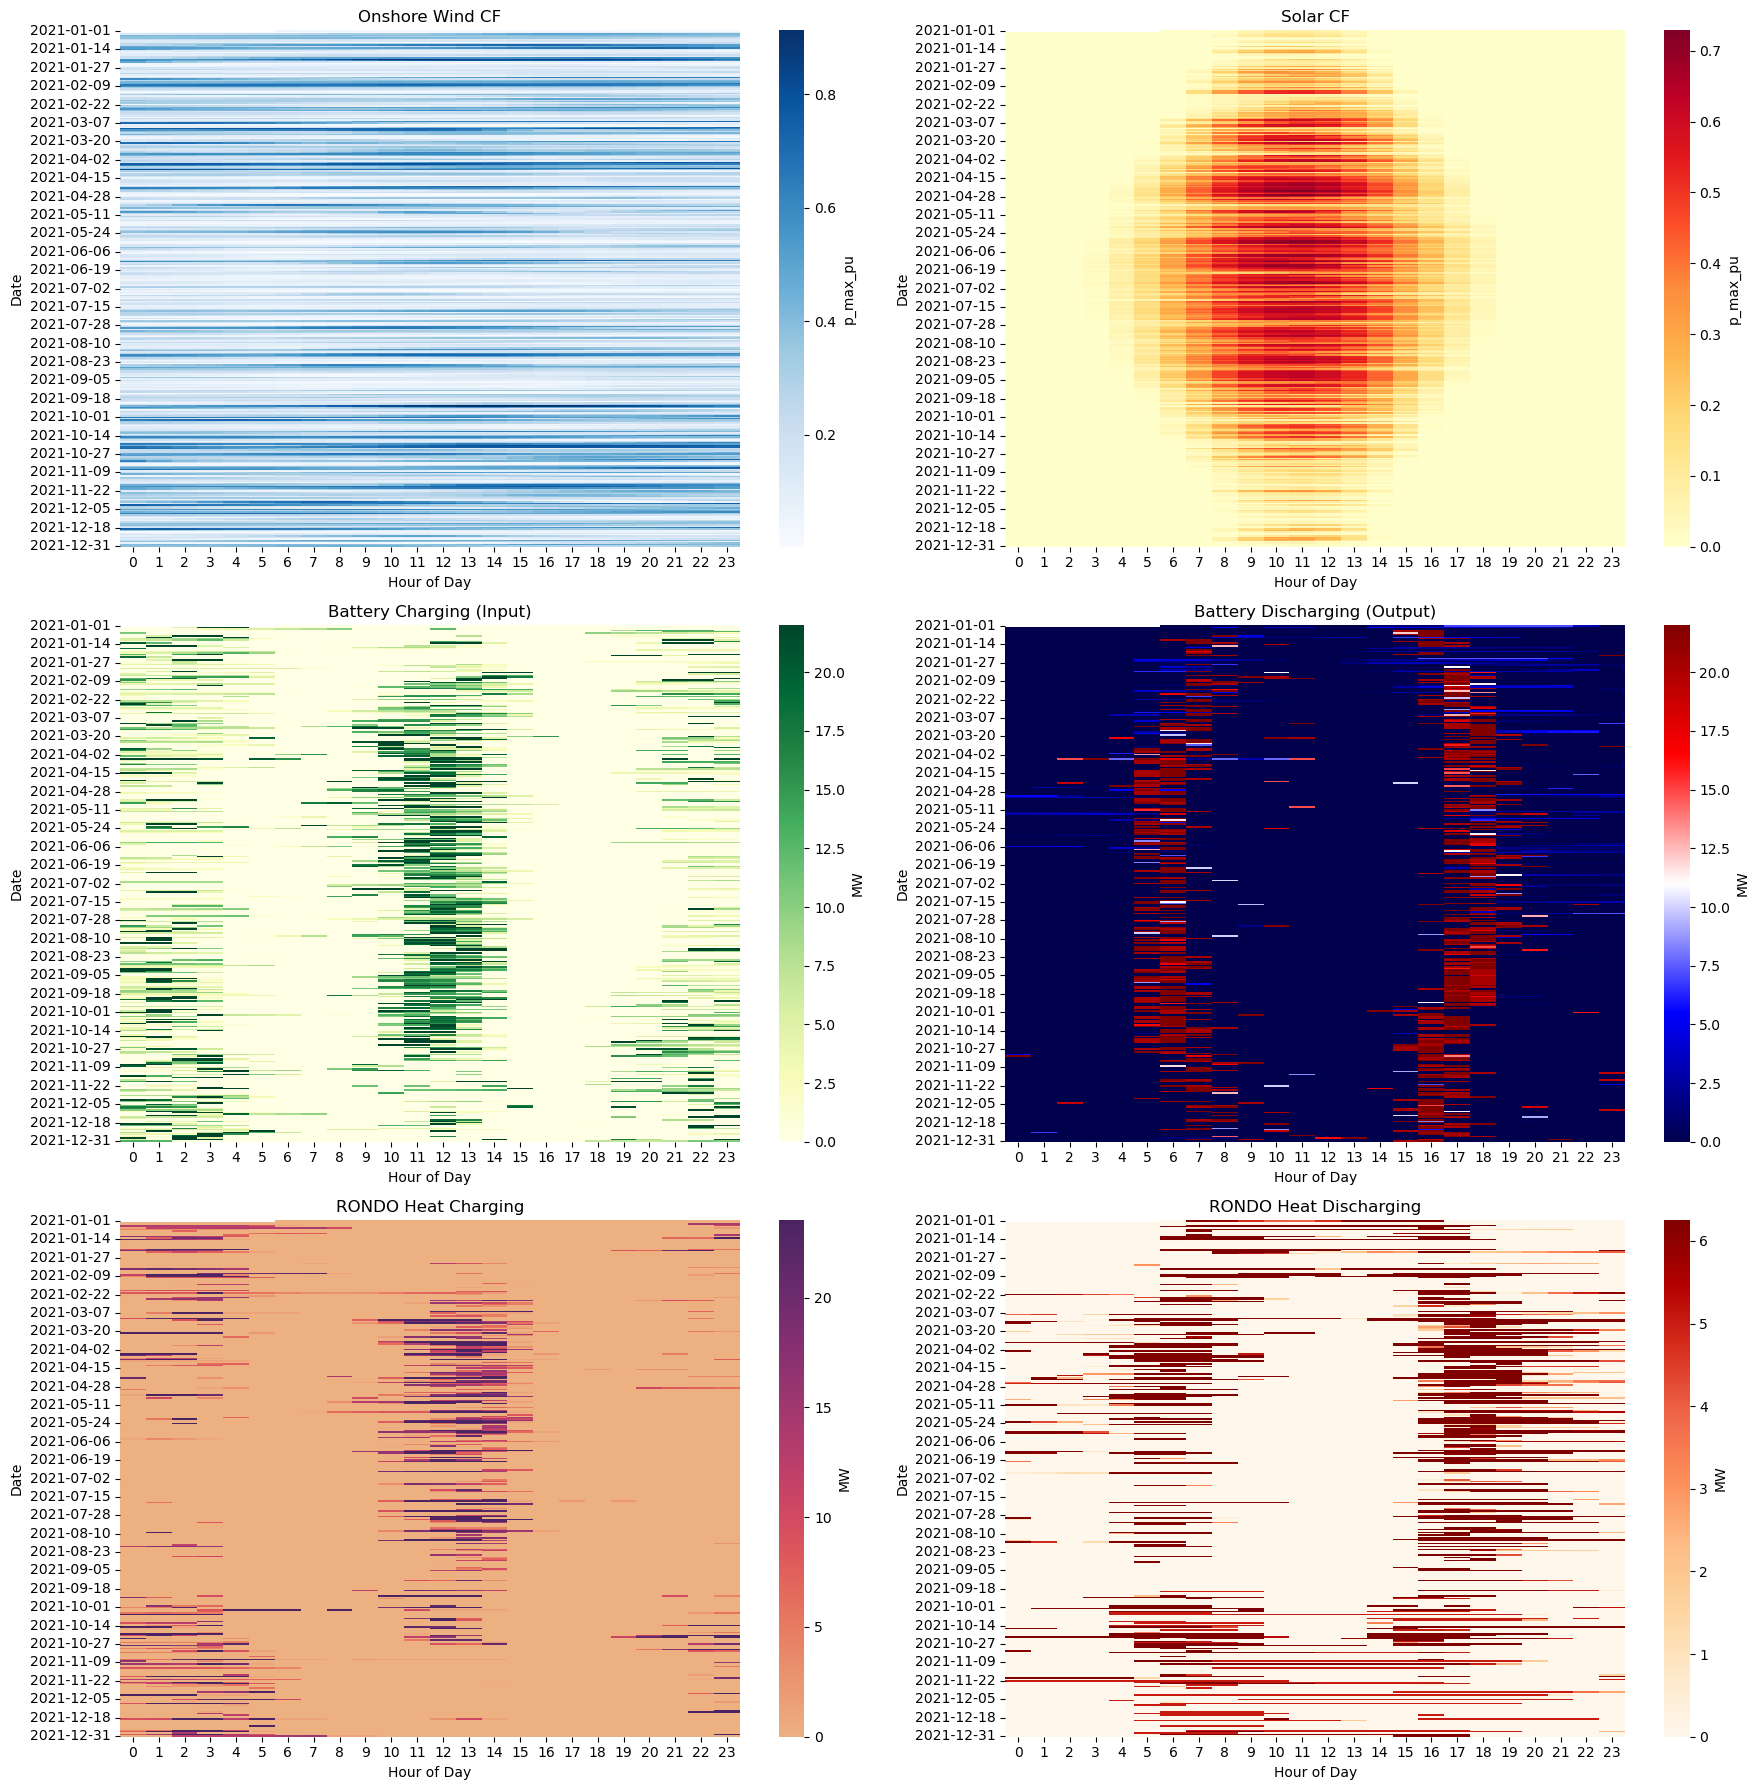

In [237]:
# Create a 3x2 figure
fig, axes = plt.subplots(3, 2, figsize=(18, 18))
axes = axes.flatten()

# ROW 1: RENEWABLES
plot_pypsa_heatmap(n21.generators_t.p_max_pu.loc[:, n21.generators.carrier == 'onshorewind'], 
                   title="Onshore Wind CF", unit="p_max_pu", cmap="Blues", ax=axes[0])

plot_pypsa_heatmap(n21.generators_t.p_max_pu.loc[:, n21.generators.carrier == 'solar'], 
                   title="Solar CF", unit="p_max_pu", cmap="YlOrRd", ax=axes[1])

# ROW 2: BATTERY (Skive)
plot_pypsa_heatmap(n21.storage_units_t.p_store["Skive_Battery"], 
                   title="Battery Charging (Input)", unit="MW", cmap="YlGn", ax=axes[2])

plot_pypsa_heatmap(n21.storage_units_t.p_dispatch["Skive_Battery"], 
                   title="Battery Discharging (Output)", unit="MW", cmap="seismic", ax=axes[3])

# ROW 3: RONDO THERMAL
plot_pypsa_heatmap(-n21.links_t.p1["El_to_TES_Rondo"], 
                   title="RONDO Heat Charging", unit="MW", cmap="flare", ax=axes[4])

plot_pypsa_heatmap(-n21.links_t.p1["TES_Rondo_to_Heat_Bus_Skive"], 
                   title="RONDO Heat Discharging", unit="MW", cmap="OrRd", ax=axes[5])

plt.tight_layout()
plt.show()

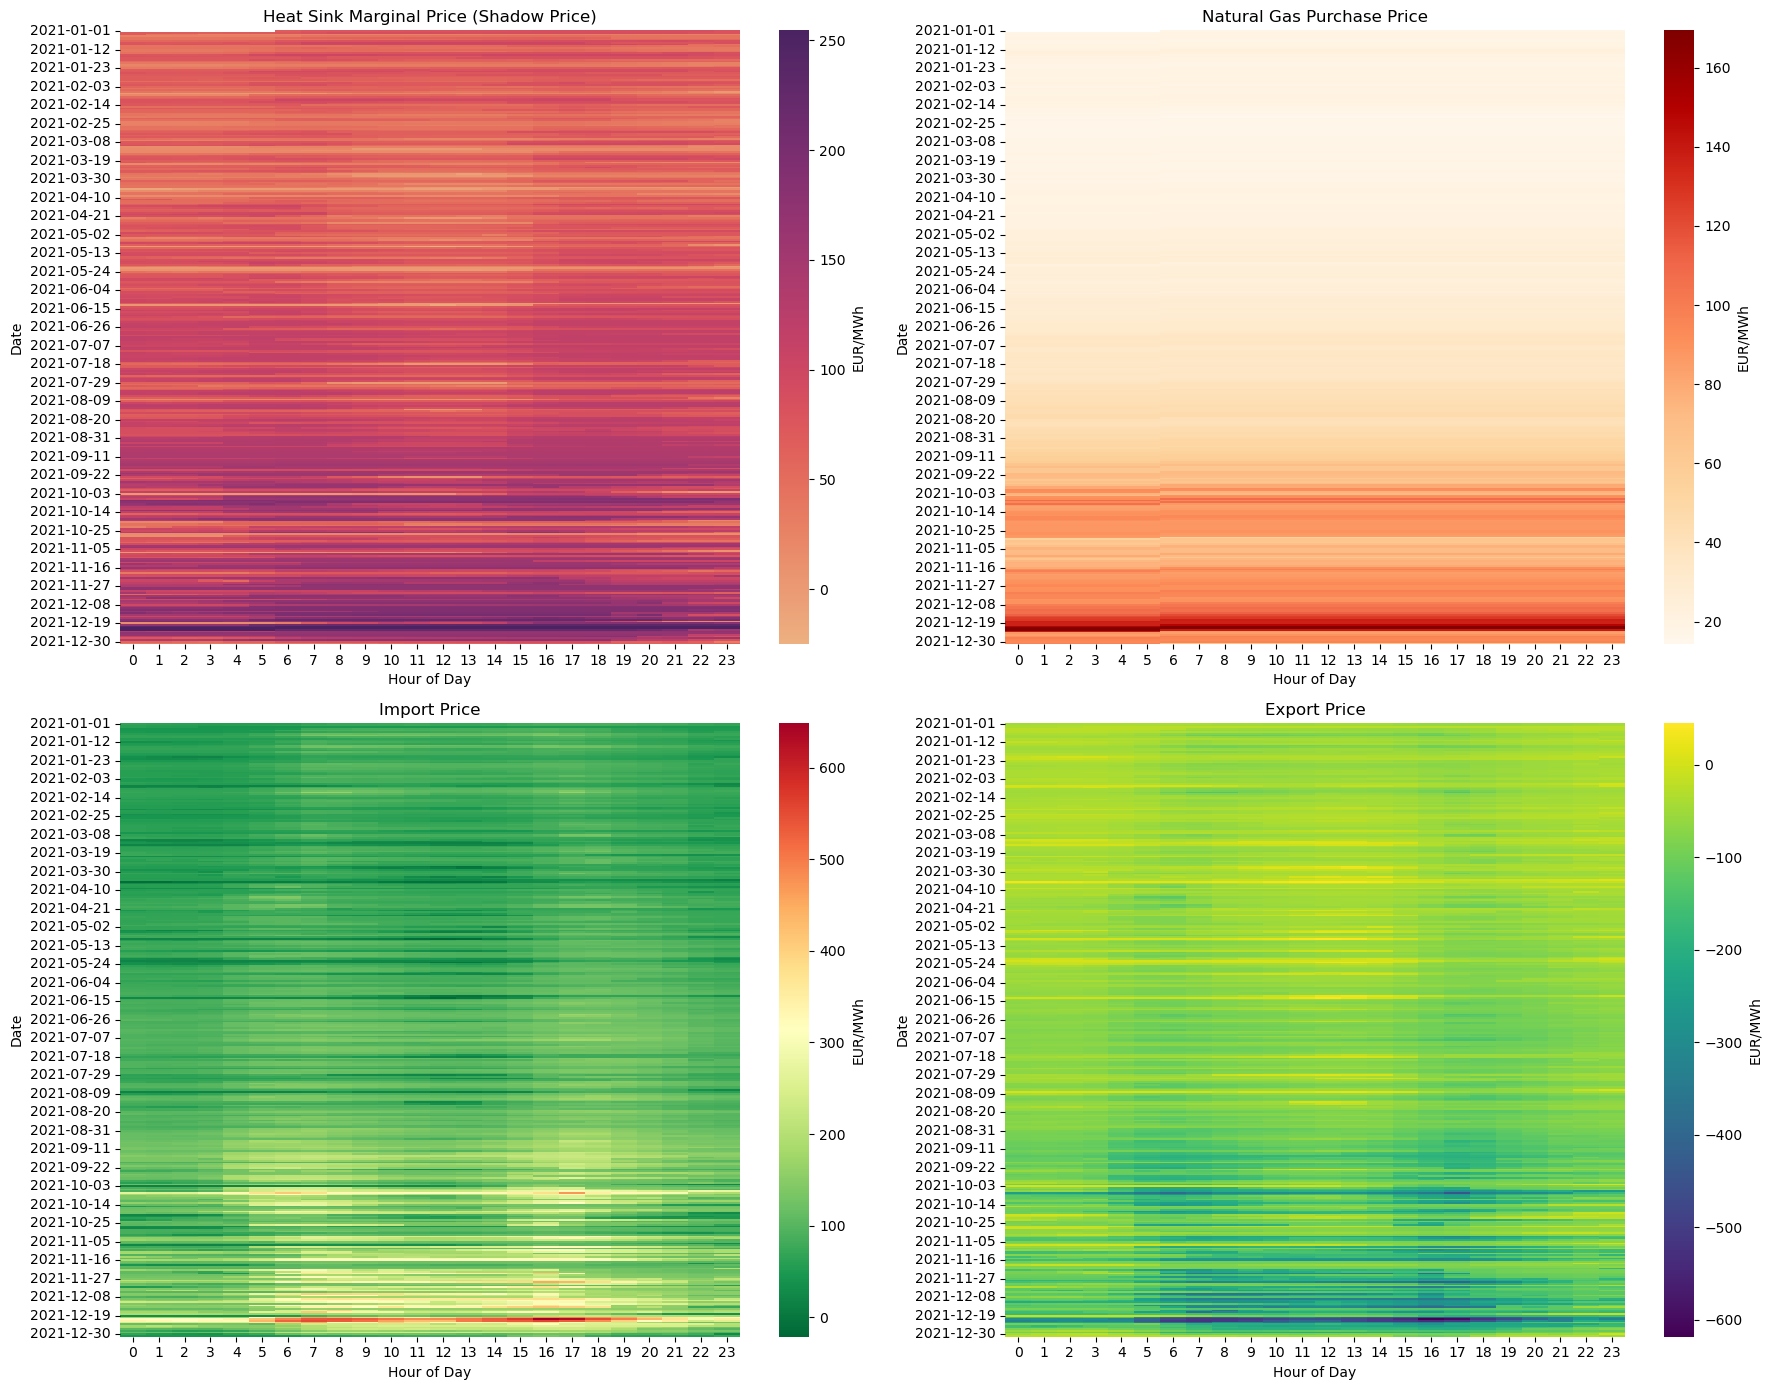

In [221]:
# Create a 2x2 figure for the 2021 Economic Drivers
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

# 1. HEAT SINK MARGINAL PRICE (Shadow Price)
# This shows the locational marginal price of heat at the sink
plot_pypsa_heatmap(n21.buses_t.marginal_price["Heat_Sink"], 
                   title="Heat Sink Marginal Price (Shadow Price)", 
                   unit="EUR/MWh", cmap="flare", ax=axes[0])

# 2. NATURAL GAS PRICE
# The marginal purchase price of gas for 2021
plot_pypsa_heatmap(NG_price.loc["2021", "MarginalPurchasePriceEUR_MWh"], 
                   title="Natural Gas Purchase Price", 
                   unit="EUR/MWh", cmap="OrRd", ax=axes[1])

# 3. ELECTRICITY IMPORT PRICE (Buy Price)
# Includes Spot + Transmission + System + Tax + Net Tariff
plot_pypsa_heatmap(import_price["2021"], 
                   title="Import Price", 
                   unit="EUR/MWh", cmap="RdYlGn_r", ax=axes[2])

# 4. ELECTRICITY EXPORT PRICE (Sell Price)
# Includes Spot - Production Tariffs
plot_pypsa_heatmap(export_price["2021"], 
                   title="Export Price", 
                   unit="EUR/MWh", cmap="viridis", ax=axes[3])

plt.tight_layout()
plt.show()

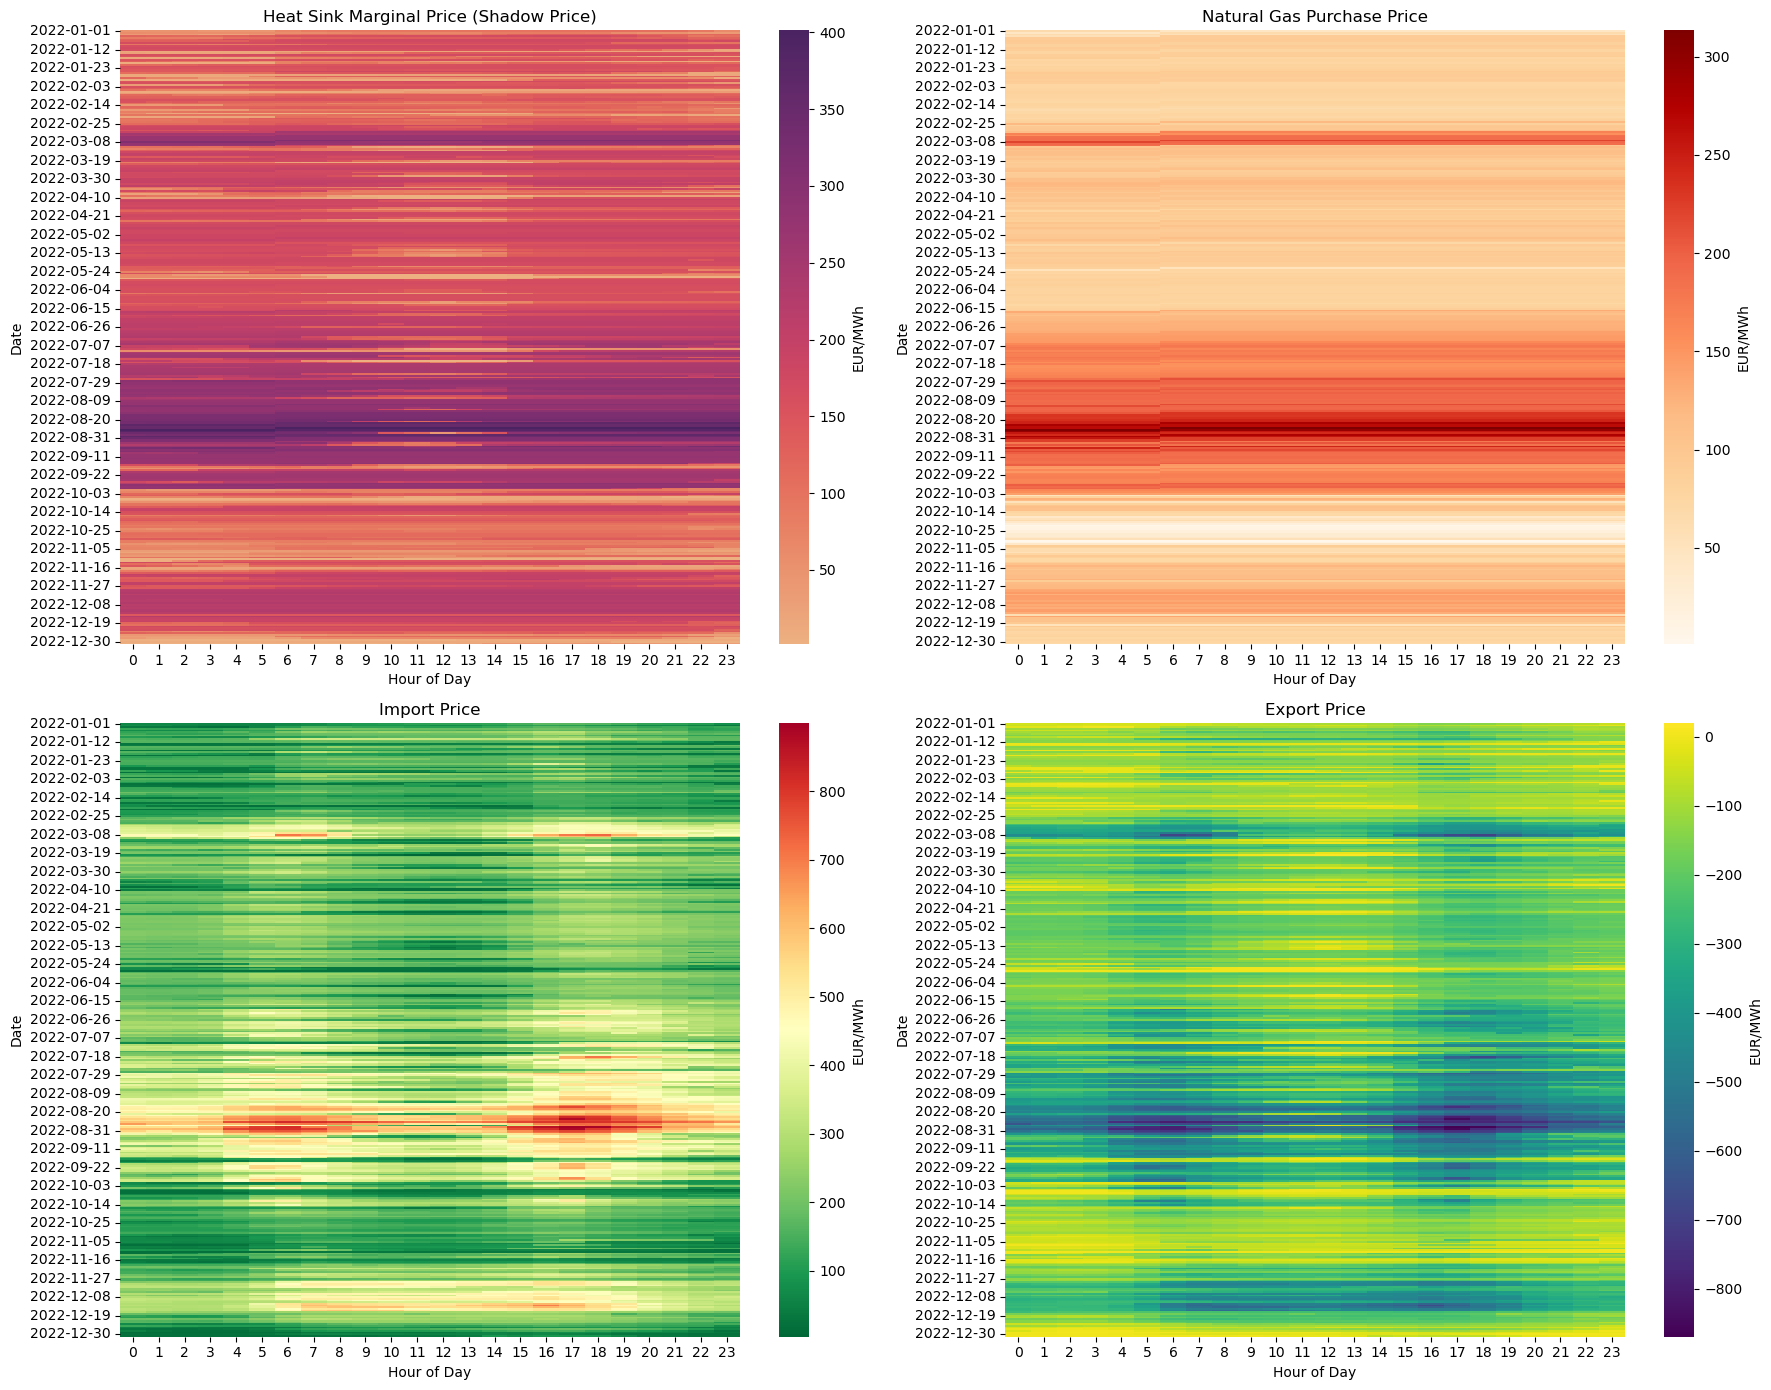

In [222]:
# Create a 2x2 figure for the 2021 Economic Drivers
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

# 1. HEAT SINK MARGINAL PRICE (Shadow Price)
# This shows the locational marginal price of heat at the sink
plot_pypsa_heatmap(n22.buses_t.marginal_price["Heat_Sink"], 
                   title="Heat Sink Marginal Price (Shadow Price)", 
                   unit="EUR/MWh", cmap="flare", ax=axes[0])

# 2. NATURAL GAS PRICE
# The marginal purchase price of gas for 2021
plot_pypsa_heatmap(NG_price.loc["2022", "MarginalPurchasePriceEUR_MWh"], 
                   title="Natural Gas Purchase Price", 
                   unit="EUR/MWh", cmap="OrRd", ax=axes[1])

# 3. ELECTRICITY IMPORT PRICE (Buy Price)
# Includes Spot + Transmission + System + Tax + Net Tariff
plot_pypsa_heatmap(import_price["2022"], 
                   title="Import Price", 
                   unit="EUR/MWh", cmap="RdYlGn_r", ax=axes[2])

# 4. ELECTRICITY EXPORT PRICE (Sell Price)
# Includes Spot - Production Tariffs
plot_pypsa_heatmap(export_price["2022"], 
                   title="Export Price", 
                   unit="EUR/MWh", cmap="viridis", ax=axes[3])

plt.tight_layout()
plt.show()

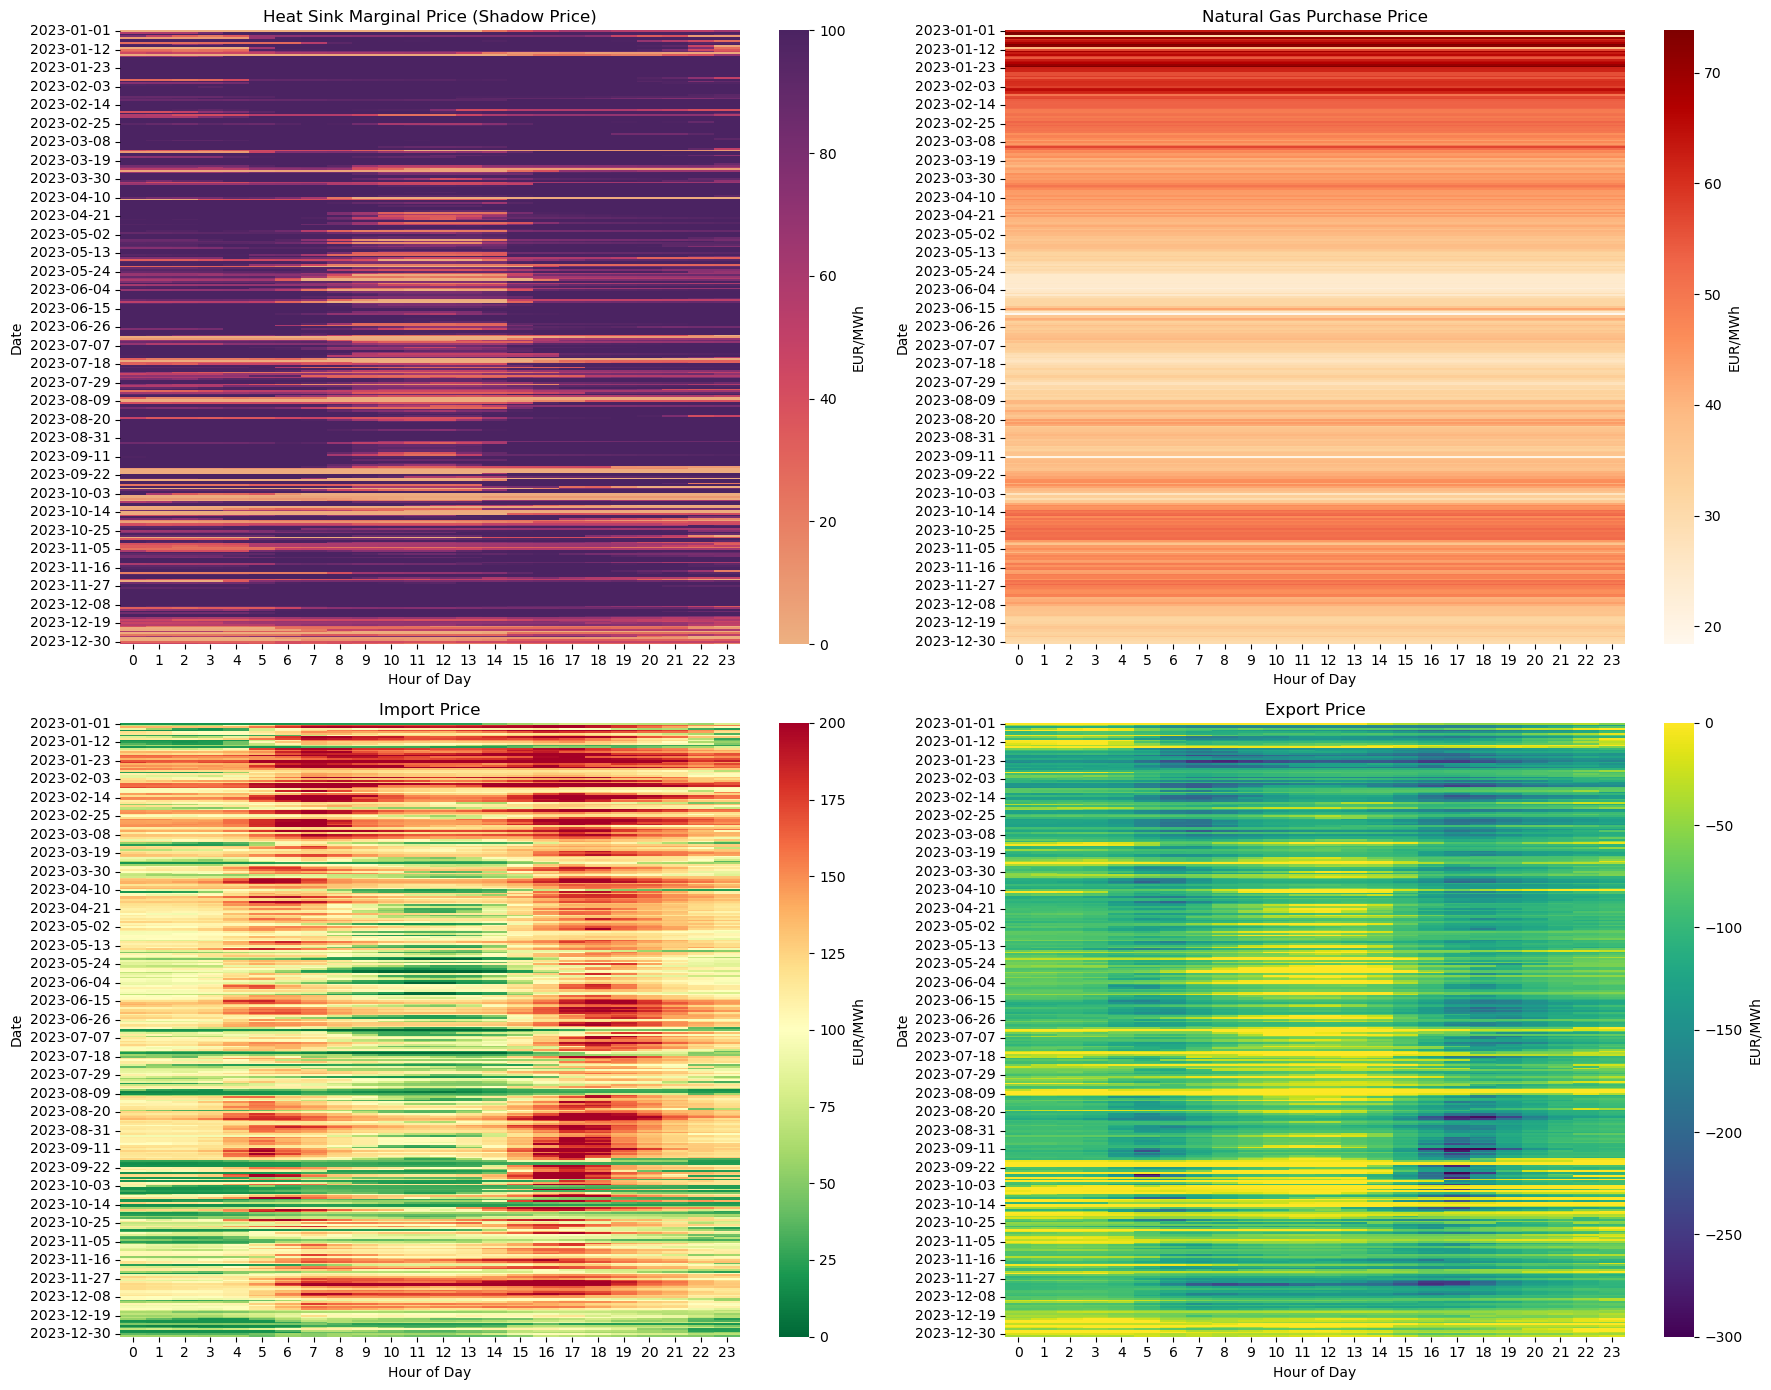

In [265]:
# Create a 2x2 figure for the 2021 Economic Drivers
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

# 1. HEAT SINK MARGINAL PRICE (Shadow Price)
# This shows the locational marginal price of heat at the sink
plot_pypsa_heatmap(n23.buses_t.marginal_price["Heat_Sink"], 
                   title="Heat Sink Marginal Price (Shadow Price)", 
                   unit="EUR/MWh", cmap="flare", ax=axes[0],vmin = 0, vmax = 100)

# 2. NATURAL GAS PRICE
# The marginal purchase price of gas for 2021
plot_pypsa_heatmap(NG_price.loc["2023", "MarginalPurchasePriceEUR_MWh"], 
                   title="Natural Gas Purchase Price", 
                   unit="EUR/MWh", cmap="OrRd", ax=axes[1])

# 3. ELECTRICITY IMPORT PRICE (Buy Price)
# Includes Spot + Transmission + System + Tax + Net Tariff
plot_pypsa_heatmap(import_price["2023"], 
                   title="Import Price", 
                   unit="EUR/MWh", cmap="RdYlGn_r", ax=axes[2], vmin = 0, vmax = 200)

# 4. ELECTRICITY EXPORT PRICE (Sell Price)
# Includes Spot - Production Tariffs
plot_pypsa_heatmap(export_price["2023"], 
                   title="Export Price", 
                   unit="EUR/MWh", cmap="viridis", ax=axes[3],vmin = -300, vmax = 0)

plt.tight_layout()
plt.show()

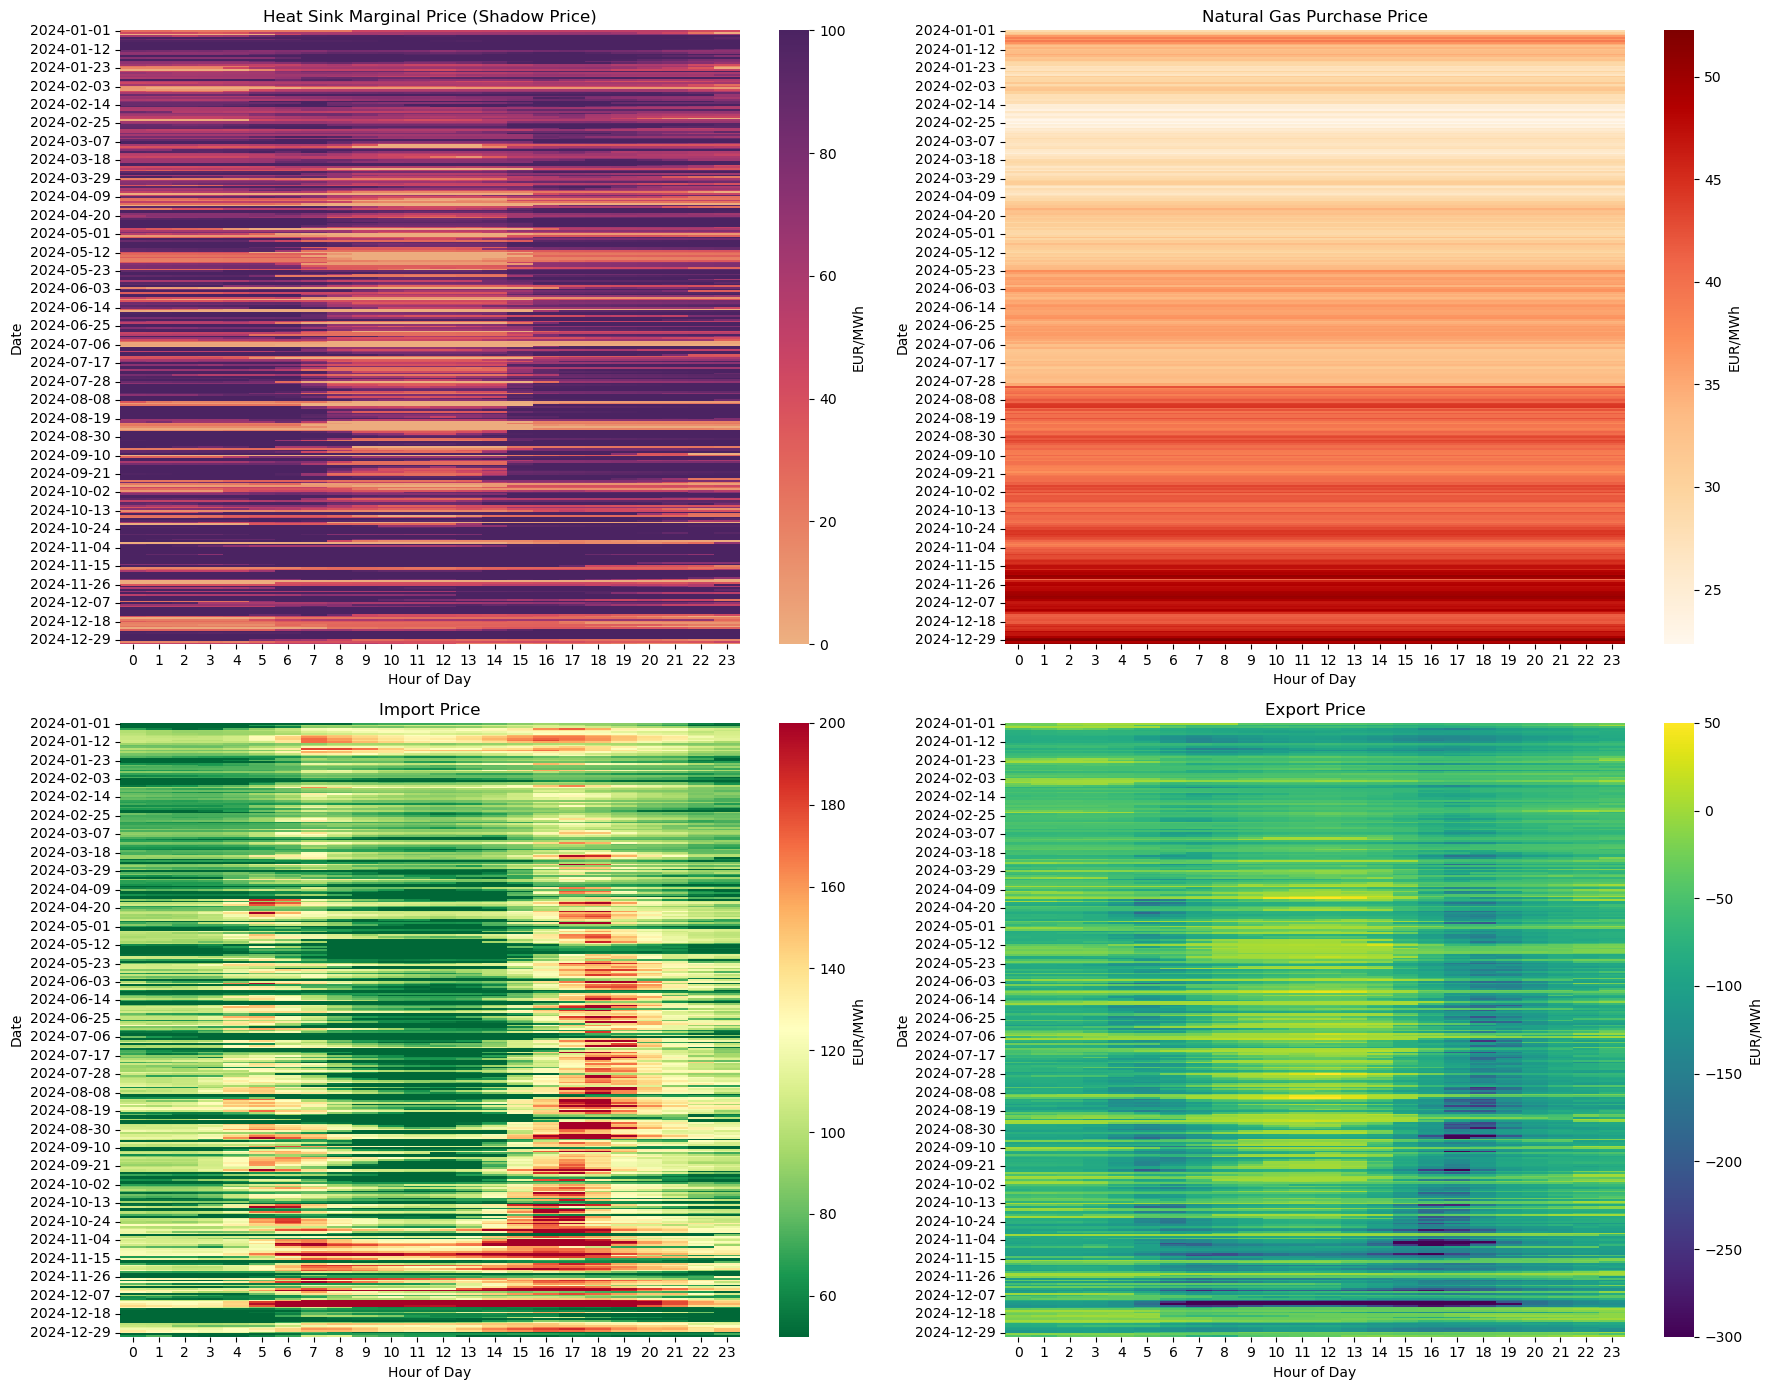

In [267]:
# Create a 2x2 figure for the 2021 Economic Drivers
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

# 1. HEAT SINK MARGINAL PRICE (Shadow Price)
# This shows the locational marginal price of heat at the sink
plot_pypsa_heatmap(n24.buses_t.marginal_price["Heat_Sink"], 
                   title="Heat Sink Marginal Price (Shadow Price)", 
                   unit="EUR/MWh", cmap="flare", ax=axes[0],vmin = 0,vmax = 100)

# 2. NATURAL GAS PRICE
# The marginal purchase price of gas for 2021
plot_pypsa_heatmap(NG_price.loc["2024", "MarginalPurchasePriceEUR_MWh"], 
                   title="Natural Gas Purchase Price", 
                   unit="EUR/MWh", cmap="OrRd", ax=axes[1])

# 3. ELECTRICITY IMPORT PRICE (Buy Price)
# Includes Spot + Transmission + System + Tax + Net Tariff
plot_pypsa_heatmap(import_price["2024"], 
                   title="Import Price", 
                   unit="EUR/MWh", cmap="RdYlGn_r", ax=axes[2],vmin = 50, vmax = 200)

# 4. ELECTRICITY EXPORT PRICE (Sell Price)
# Includes Spot - Production Tariffs
plot_pypsa_heatmap(export_price["2024"], 
                   title="Export Price", 
                   unit="EUR/MWh", cmap="viridis", ax=axes[3],vmin = -300, vmax = 50)

plt.tight_layout()
plt.show()

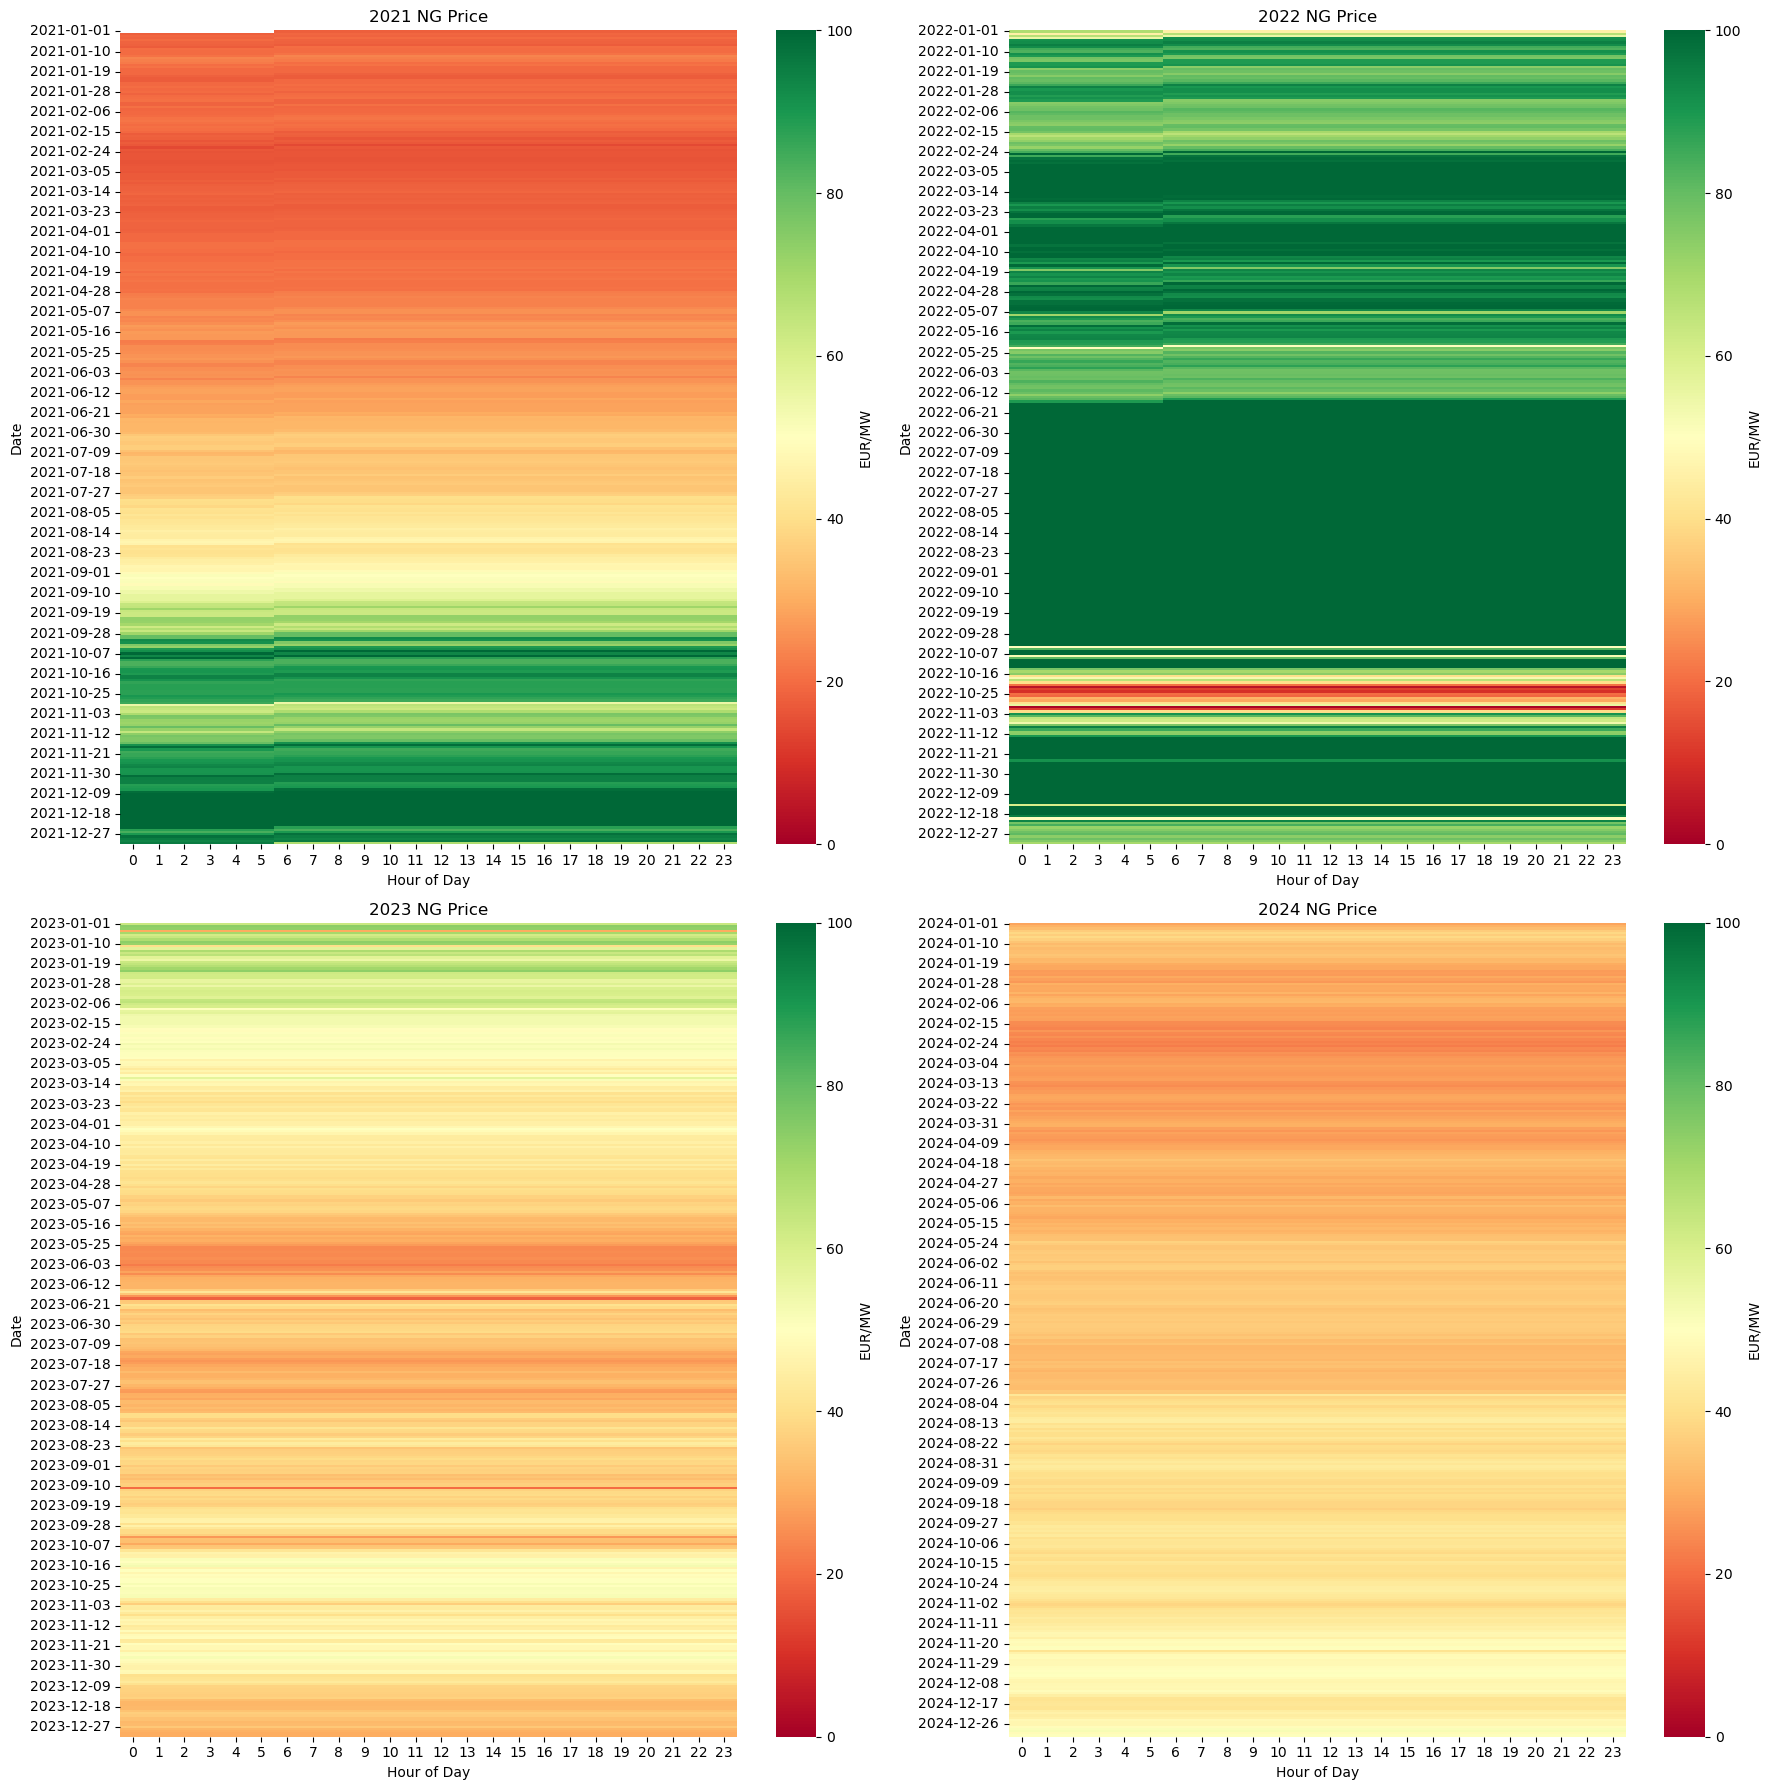

In [249]:
# Create a 3x2 figure
fig, axes = plt.subplots(2, 2, figsize=(18, 18))
axes = axes.flatten()

# --- ROW 1: RENEWABLE AVAILABILITY ---
plot_pypsa_heatmap(NG_price["MarginalPurchasePriceEUR_MWh"]["2021"], 
                   title="2021 NG Price", unit="EUR/MW", cmap="RdYlGn" ,ax=axes[0], vmin = 0, vmax = 100)

plot_pypsa_heatmap(NG_price["MarginalPurchasePriceEUR_MWh"]["2022"], 
                   title="2022 NG Price", unit="EUR/MW", cmap="RdYlGn",ax=axes[1], vmin = 0, vmax = 100)

# --- ROW 2: BATTERY OPERATIONS ---
plot_pypsa_heatmap(NG_price["MarginalPurchasePriceEUR_MWh"]["2023"], 
                   title="2023 NG Price", unit="EUR/MW", cmap="RdYlGn", ax=axes[2], vmin = 0, vmax = 100)

plot_pypsa_heatmap(NG_price["MarginalPurchasePriceEUR_MWh"]["2024"], 
                   title="2024 NG Price", unit="EUR/MW", cmap="RdYlGn",ax=axes[3], vmin = 0, vmax = 100)

plt.tight_layout()
plt.show()

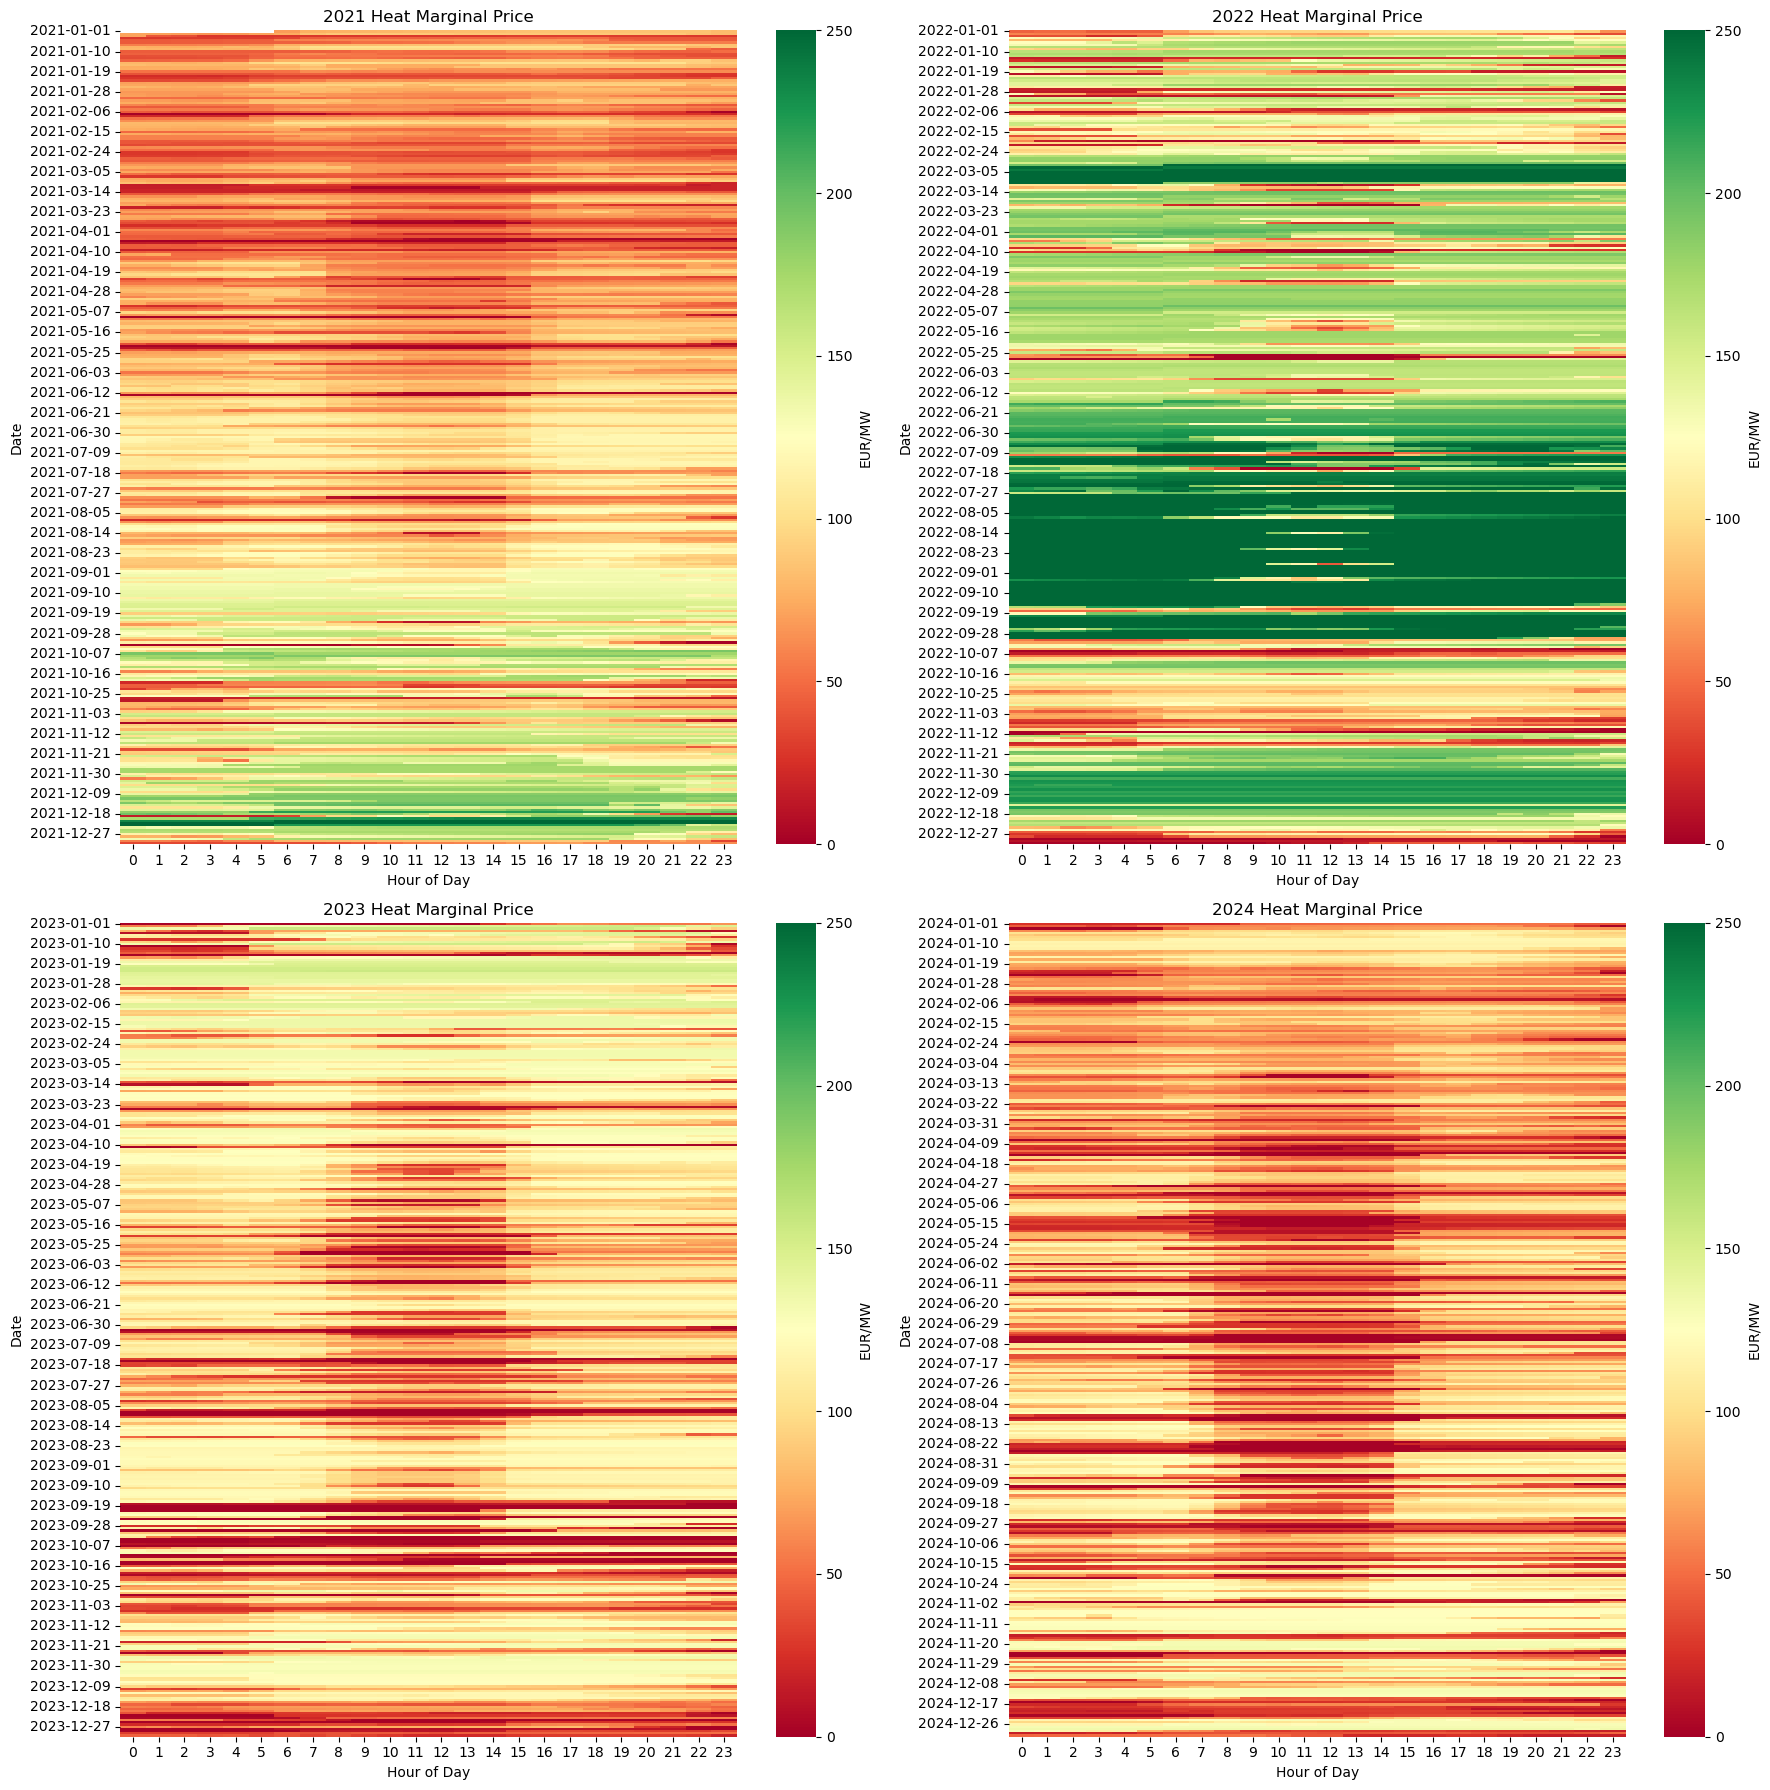

In [313]:
# Create a 3x2 figure
fig, axes = plt.subplots(2, 2, figsize=(18, 18))
axes = axes.flatten()

# --- ROW 1: RENEWABLE AVAILABILITY ---
plot_pypsa_heatmap(n21.buses_t.marginal_price["Heat_MT"], 
                   title="2021 Heat Marginal Price", unit="EUR/MW", cmap="RdYlGn", ax=axes[0],vmin =  0, vmax = 250)

plot_pypsa_heatmap(n22.buses_t.marginal_price["Heat_MT"], 
                   title="2022 Heat Marginal Price", unit="EUR/MW", cmap="RdYlGn", ax=axes[1],vmin =  0, vmax = 250)

# --- ROW 2: BATTERY OPERATIONS ---
plot_pypsa_heatmap(n23.buses_t.marginal_price["Heat_MT"], 
                   title="2023 Heat Marginal Price", unit="EUR/MW", cmap="RdYlGn", ax=axes[2],vmin =  0, vmax = 250)

plot_pypsa_heatmap(n24.buses_t.marginal_price["Heat_MT"], 
                   title="2024 Heat Marginal Price", unit="EUR/MW", cmap="RdYlGn", ax=axes[3],vmin =  0, vmax = 250)

plt.tight_layout()
plt.show()

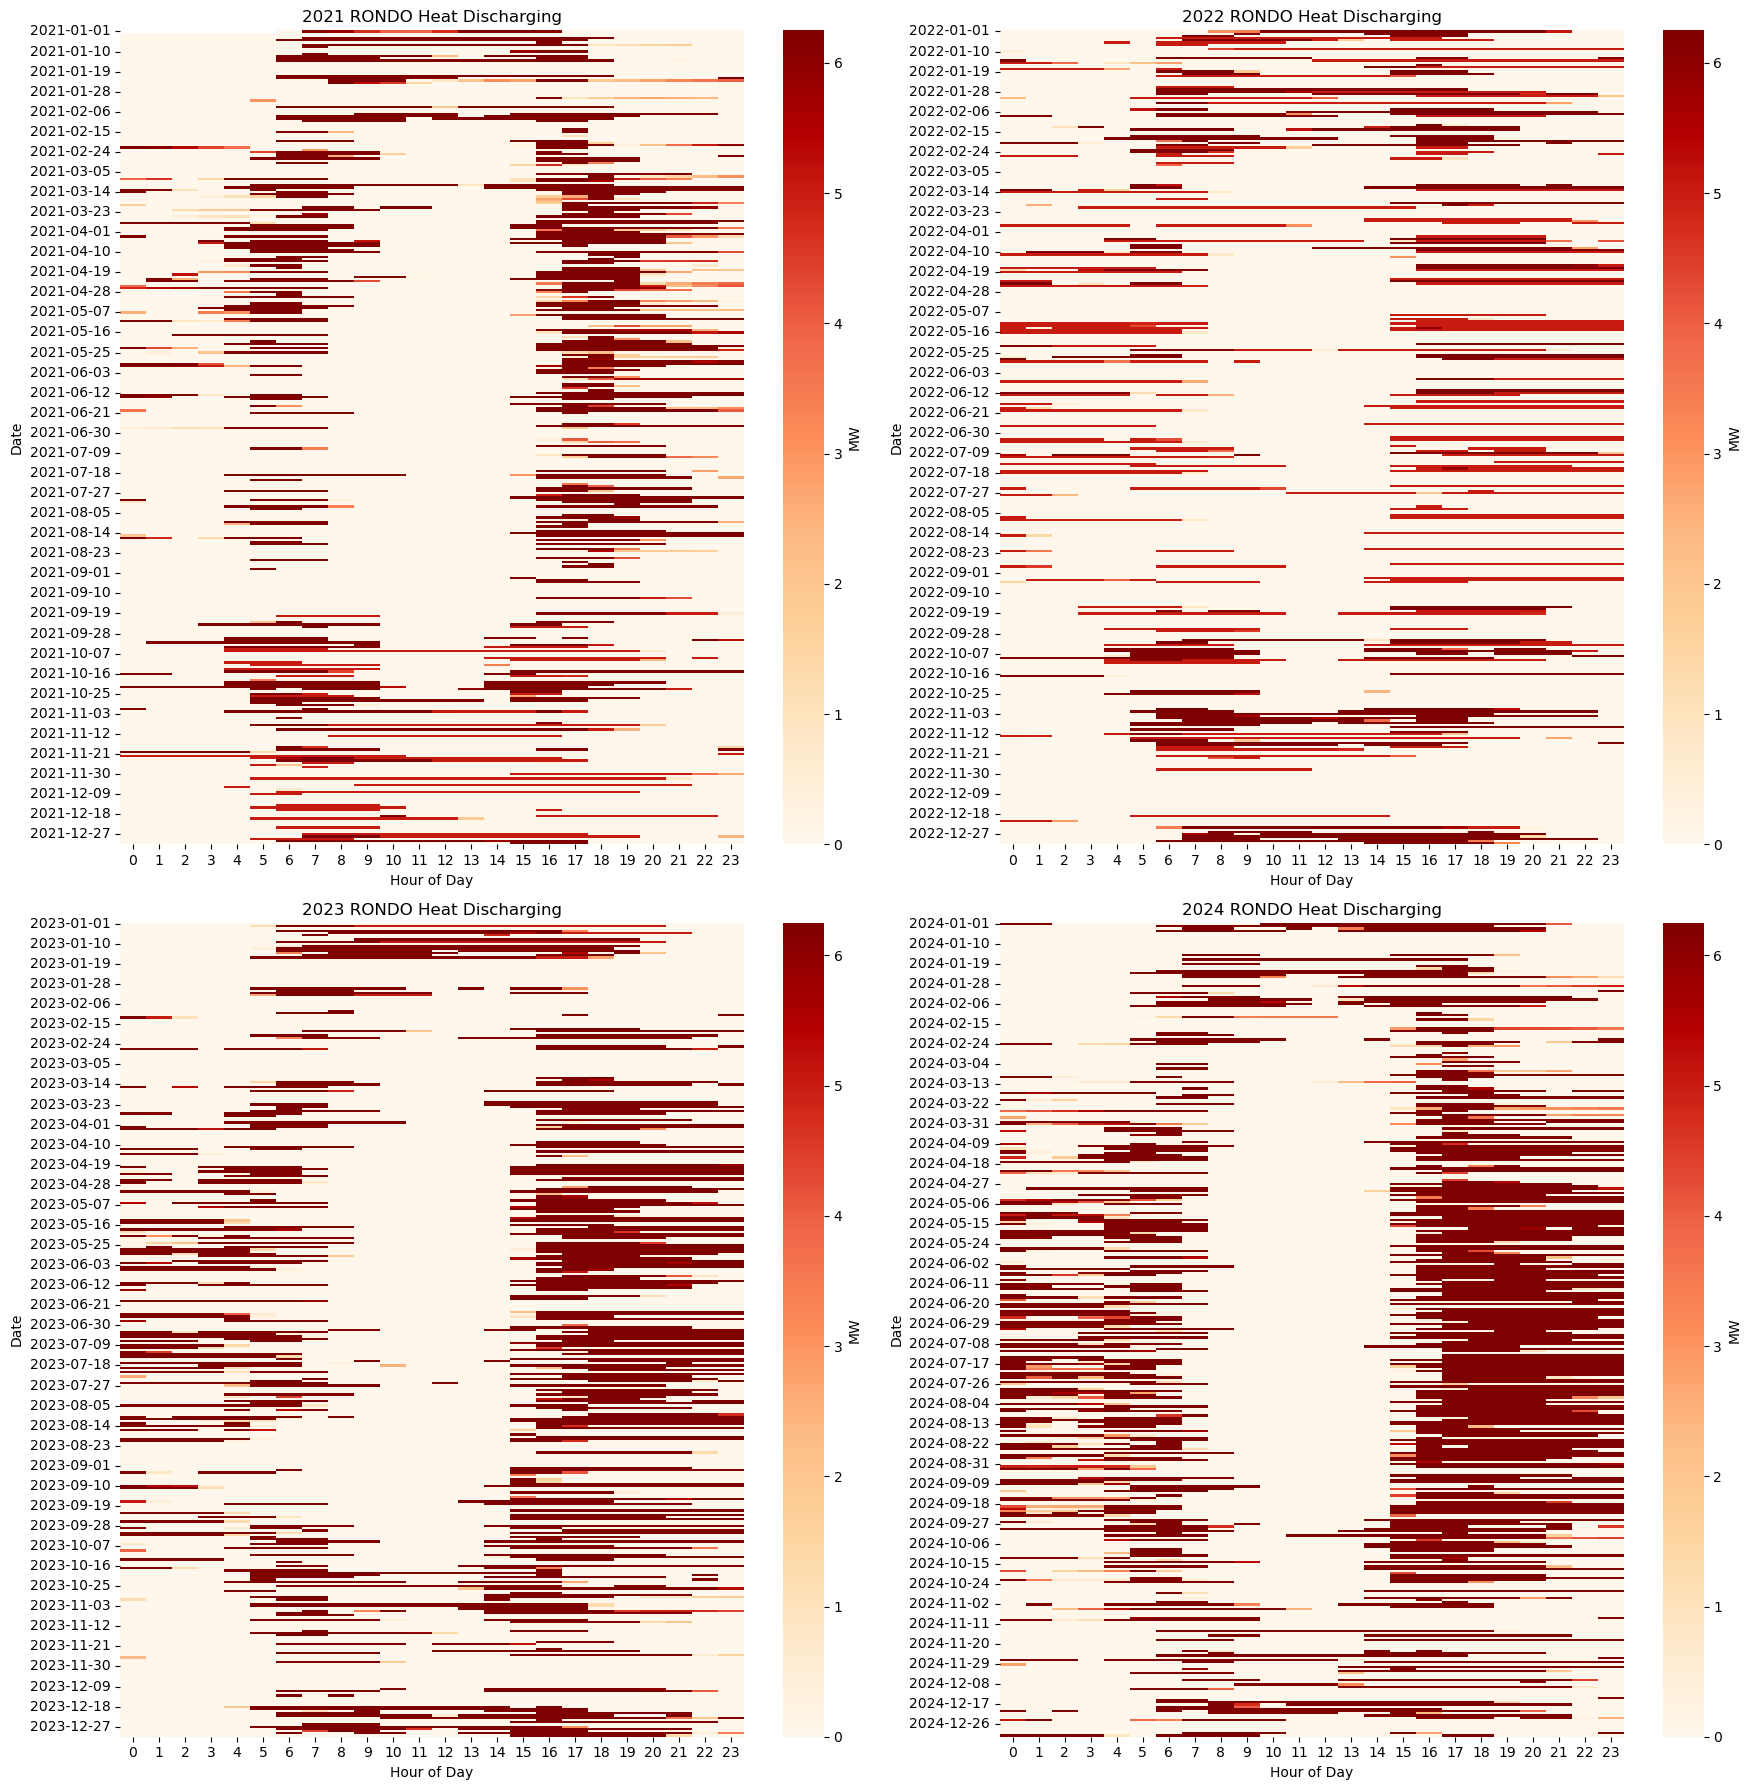

In [229]:


# Create a 3x2 figure
fig, axes = plt.subplots(2, 2, figsize=(18, 18))
axes = axes.flatten()

# --- ROW 1: RENEWABLE AVAILABILITY ---
plot_pypsa_heatmap(-n21.links_t.p1["TES_Rondo_to_Heat_Bus_Skive"], 
                   title="2021 RONDO Heat Discharging", unit="MW", cmap="OrRd", ax=axes[0])

plot_pypsa_heatmap(-n22.links_t.p1["TES_Rondo_to_Heat_Bus_Skive"], 
                   title="2022 RONDO Heat Discharging", unit="MW", cmap="OrRd", ax=axes[1])

# --- ROW 2: BATTERY OPERATIONS ---
plot_pypsa_heatmap(-n23.links_t.p1["TES_Rondo_to_Heat_Bus_Skive"], 
                   title="2023 RONDO Heat Discharging", unit="MW", cmap="OrRd", ax=axes[2])

plot_pypsa_heatmap(-n24.links_t.p1["TES_Rondo_to_Heat_Bus_Skive"], 
                   title="2024 RONDO Heat Discharging", unit="MW", cmap="OrRd", ax=axes[3])

plt.tight_layout()
plt.show()

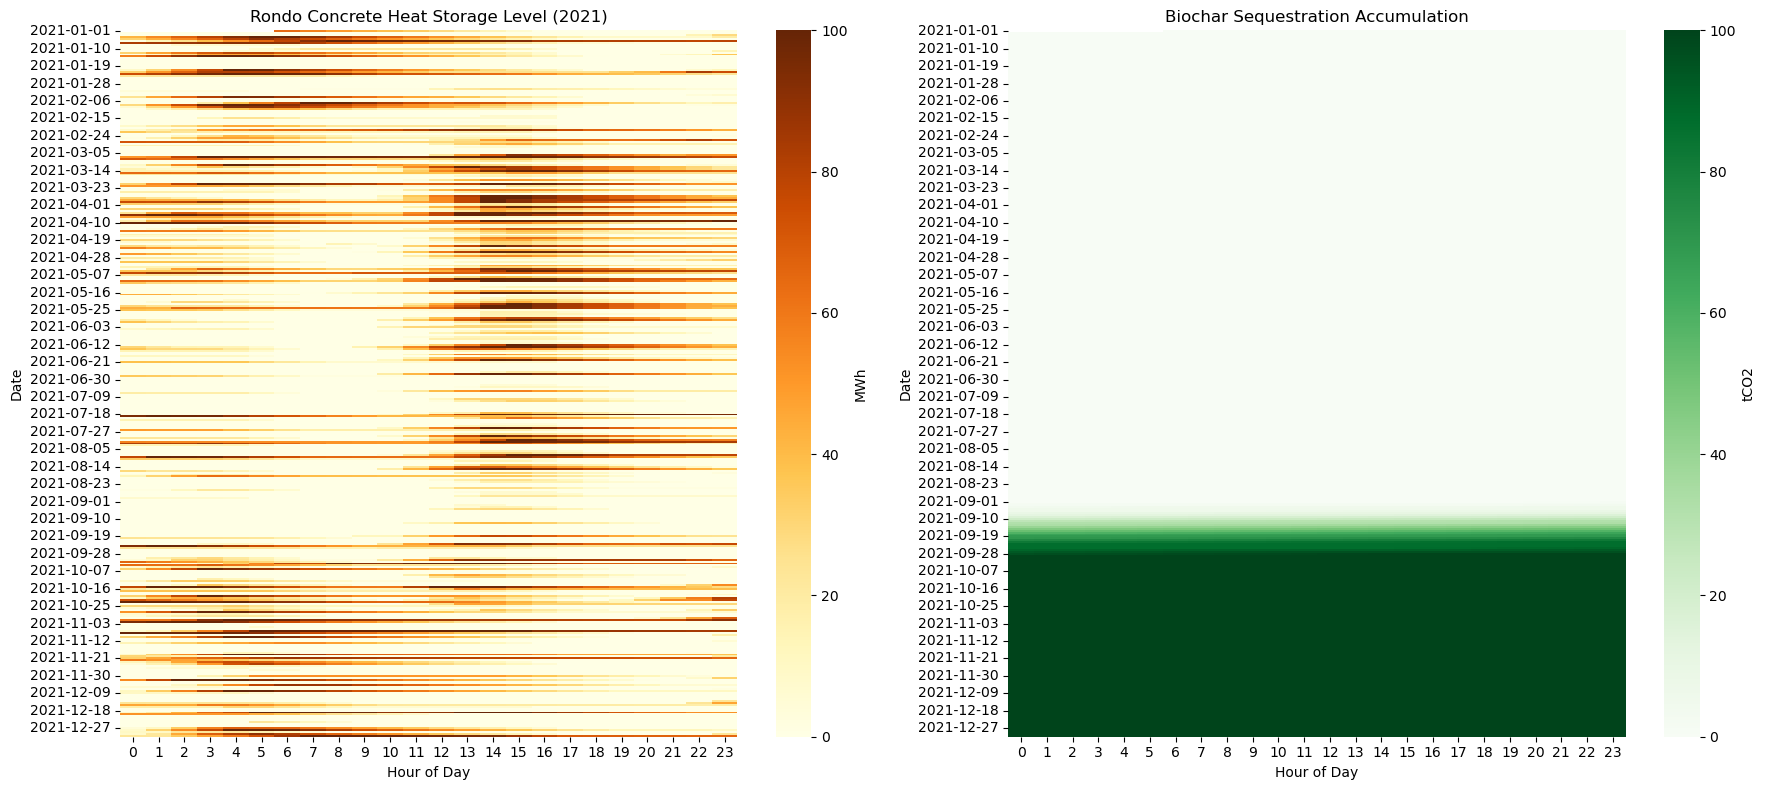

In [302]:
# Create a 1x2 figure
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 1. RONDO CONCRETE HEAT STORAGE
# This represents the thermal state (MWh) of the Rondo unit.
# We use 'YlOrBr' to reflect the heat levels.
plot_pypsa_heatmap(n21.stores_t.e["Rondo_Concrete_Heat_Storage"], 
                   title="Rondo Concrete Heat Storage Level (2021)", 
                   unit="MWh", cmap="YlOrBr", ax=axes[0],vmin = 0,vmax = 100)

# 2. BIOCHAR SEQUESTRED
# This typically represents the accumulated carbon (tCO2).
# We use 'Greens' for environmental/sequestration tracking.
plot_pypsa_heatmap(n21.stores_t.e["biochar sequestred"], 
                   title="Biochar Sequestration Accumulation", 
                   unit="tCO2", cmap="Greens", ax=axes[1],vmin = 0,vmax = 100)

plt.tight_layout()
plt.show()

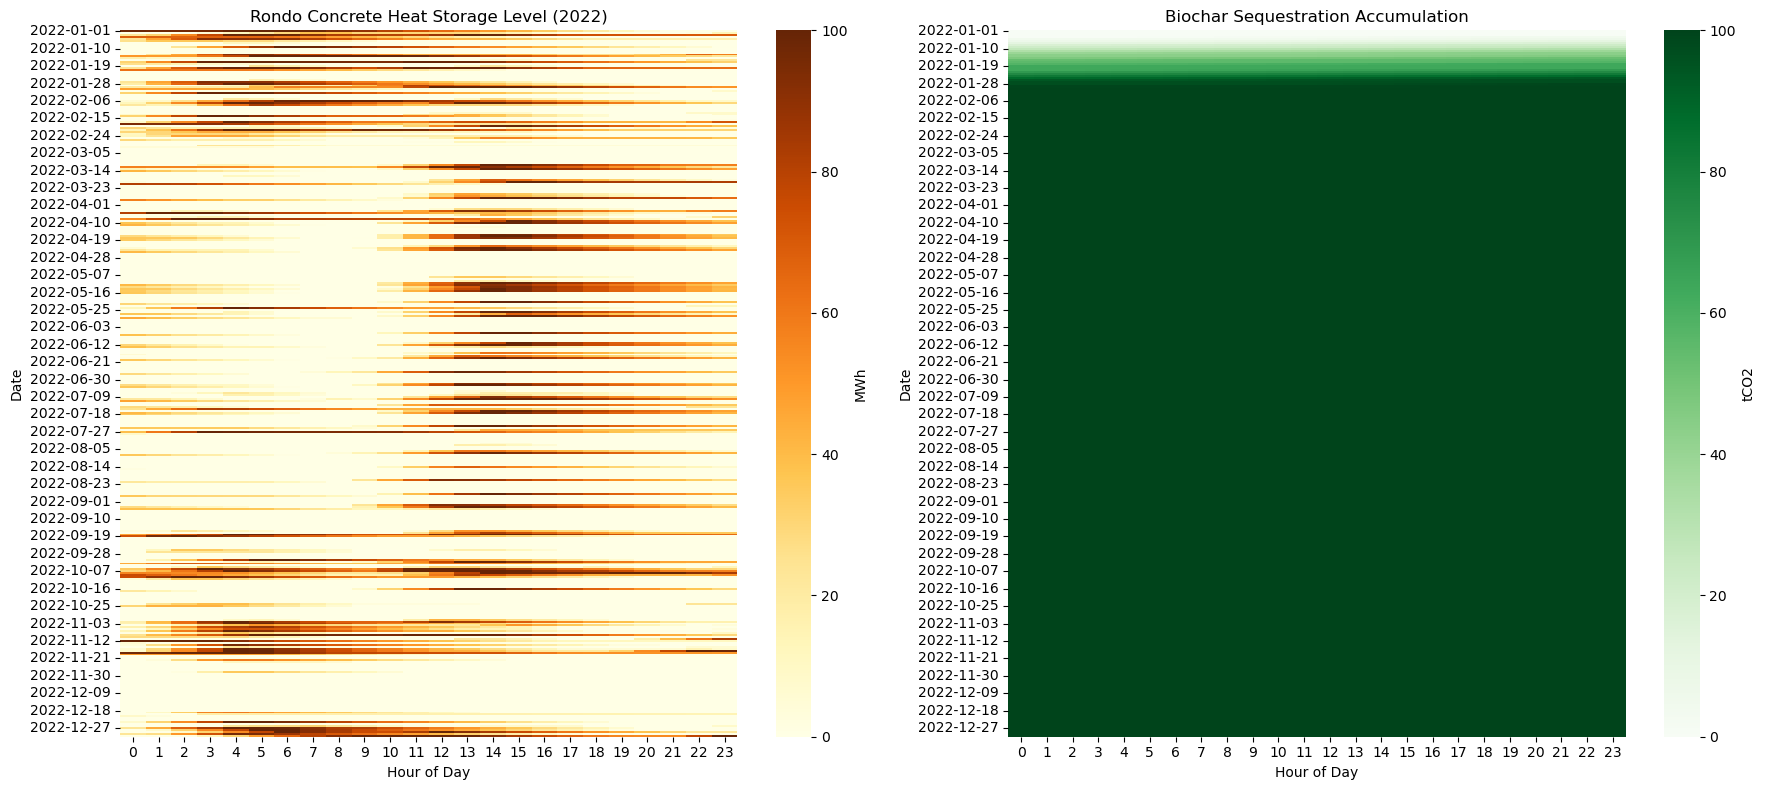

In [303]:
# Create a 1x2 figure
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 1. RONDO CONCRETE HEAT STORAGE
# This represents the thermal state (MWh) of the Rondo unit.
# We use 'YlOrBr' to reflect the heat levels.
plot_pypsa_heatmap(n22.stores_t.e["Rondo_Concrete_Heat_Storage"], 
                   title="Rondo Concrete Heat Storage Level (2022)", 
                   unit="MWh", cmap="YlOrBr", ax=axes[0],vmin = 0,vmax = 100)

# 2. BIOCHAR SEQUESTRED
# This typically represents the accumulated carbon (tCO2).
# We use 'Greens' for environmental/sequestration tracking.
plot_pypsa_heatmap(n22.stores_t.e["biochar sequestred"], 
                   title="Biochar Sequestration Accumulation", 
                   unit="tCO2", cmap="Greens", ax=axes[1],vmin = 0,vmax = 100)

plt.tight_layout()
plt.show()

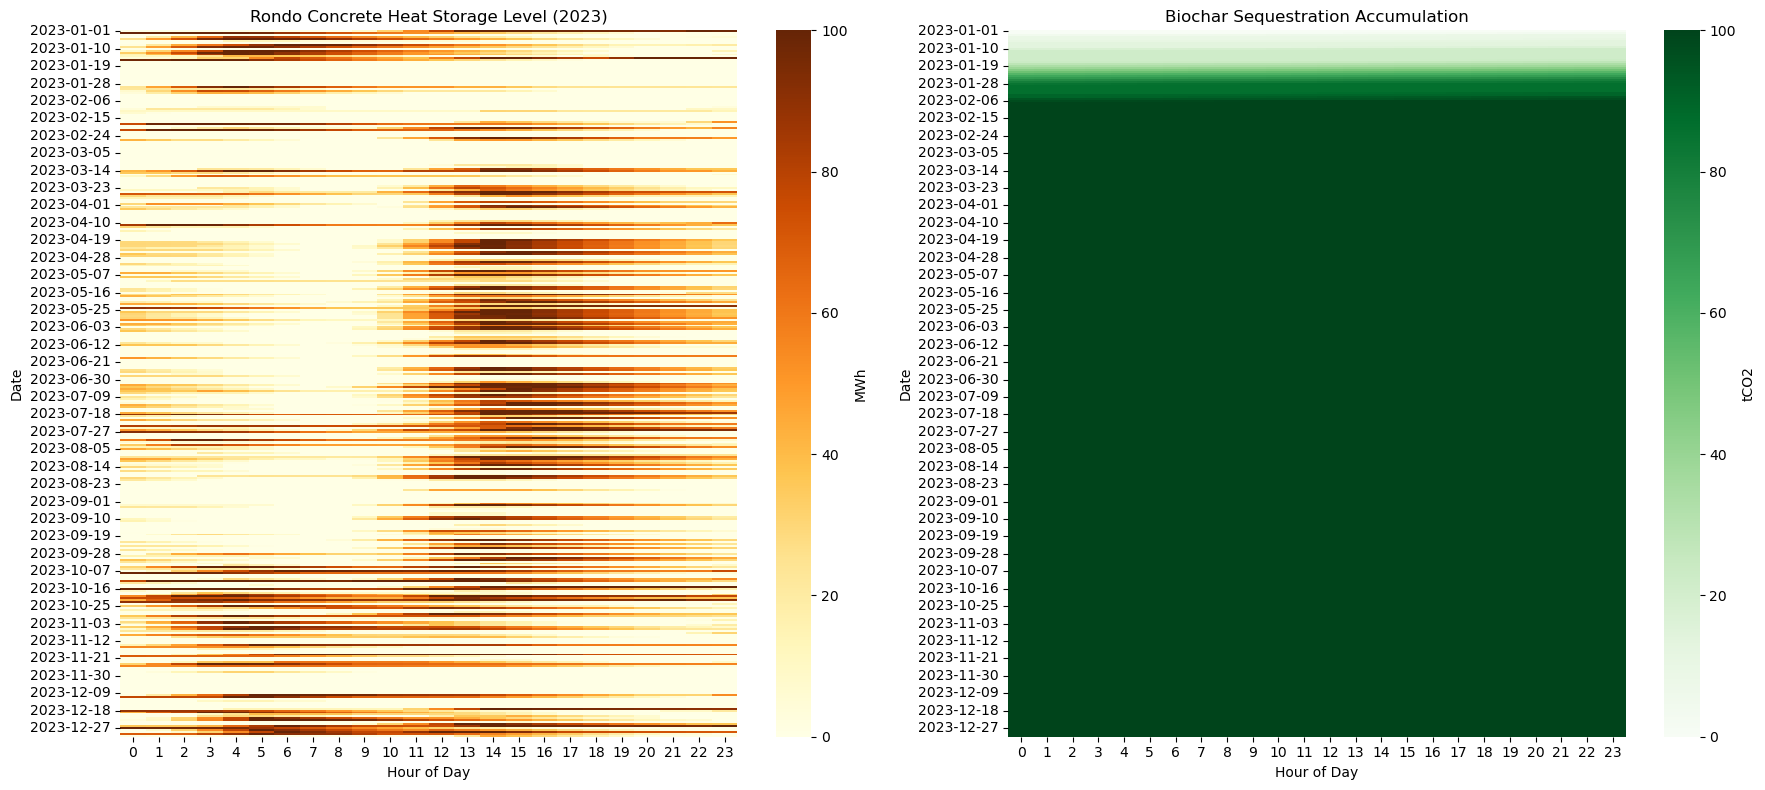

In [304]:
# Create a 1x2 figure
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 1. RONDO CONCRETE HEAT STORAGE
# This represents the thermal state (MWh) of the Rondo unit.
# We use 'YlOrBr' to reflect the heat levels.
plot_pypsa_heatmap(n23.stores_t.e["Rondo_Concrete_Heat_Storage"], 
                   title="Rondo Concrete Heat Storage Level (2023)", 
                   unit="MWh", cmap="YlOrBr", ax=axes[0],vmin = 0,vmax = 100)

# 2. BIOCHAR SEQUESTRED
# This typically represents the accumulated carbon (tCO2).
# We use 'Greens' for environmental/sequestration tracking.
plot_pypsa_heatmap(n23.stores_t.e["biochar sequestred"], 
                   title="Biochar Sequestration Accumulation", 
                   unit="tCO2", cmap="Greens", ax=axes[1],vmin = 0,vmax = 100)

plt.tight_layout()
plt.show()

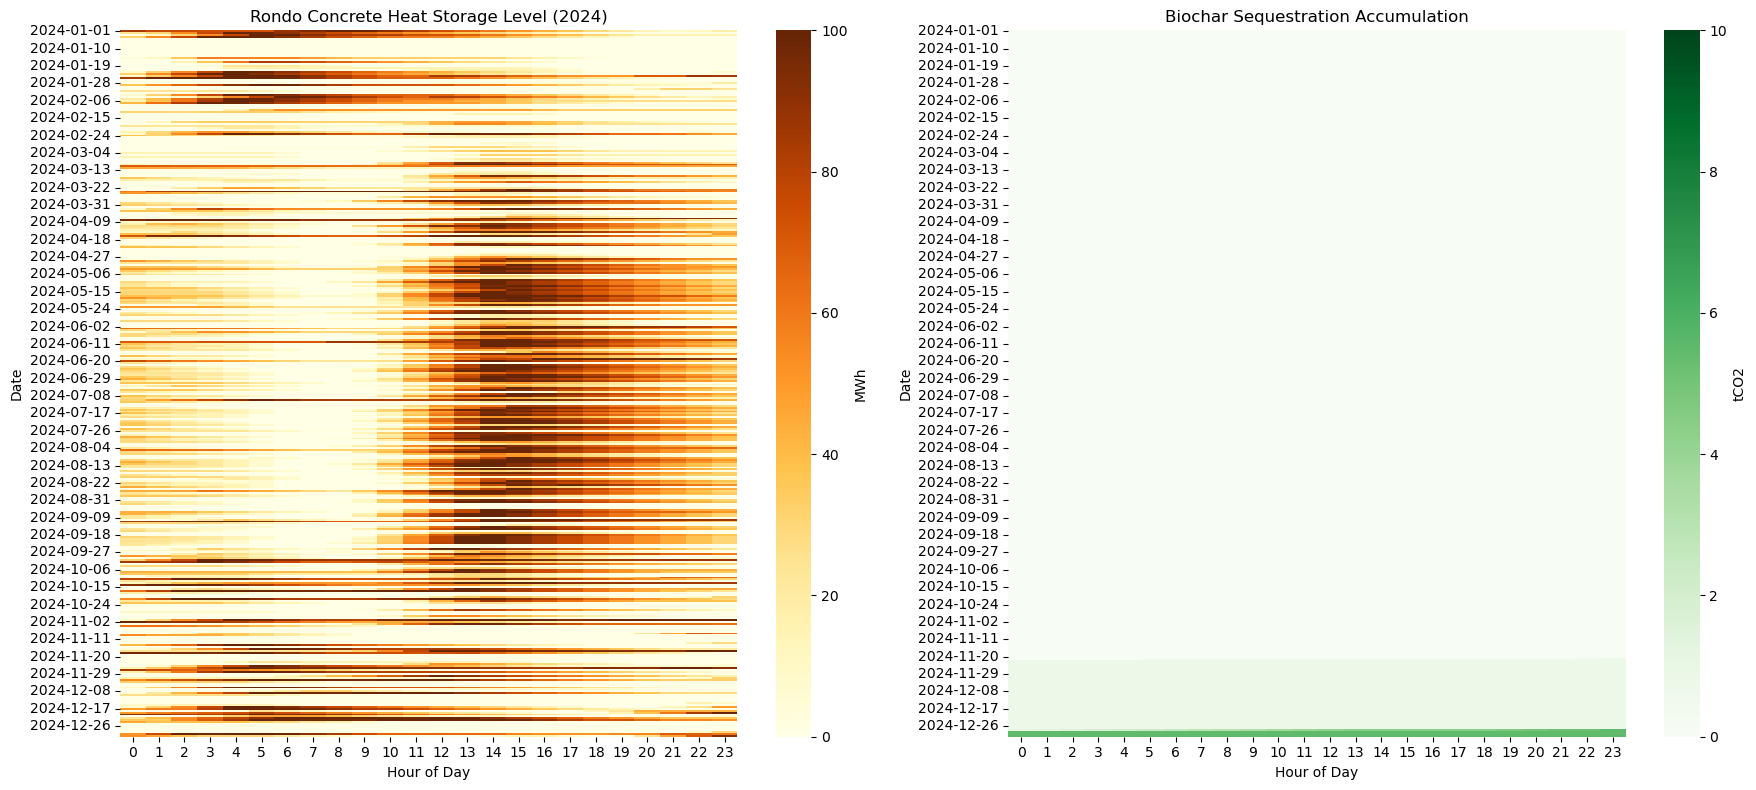

In [306]:
# Create a 1x2 figure
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 1. RONDO CONCRETE HEAT STORAGE
# This represents the thermal state (MWh) of the Rondo unit.
# We use 'YlOrBr' to reflect the heat levels.
plot_pypsa_heatmap(n24.stores_t.e["Rondo_Concrete_Heat_Storage"], 
                   title="Rondo Concrete Heat Storage Level (2024)", 
                   unit="MWh", cmap="YlOrBr", ax=axes[0],vmin = 0,vmax = 100)

# 2. BIOCHAR SEQUESTRED
# This typically represents the accumulated carbon (tCO2).
# We use 'Greens' for environmental/sequestration tracking.
plot_pypsa_heatmap(n24.stores_t.e["biochar sequestred"], 
                   title="Biochar Sequestration Accumulation", 
                   unit="tCO2", cmap="Greens", ax=axes[1],vmin = 0,vmax = 10)

plt.tight_layout()
plt.show()

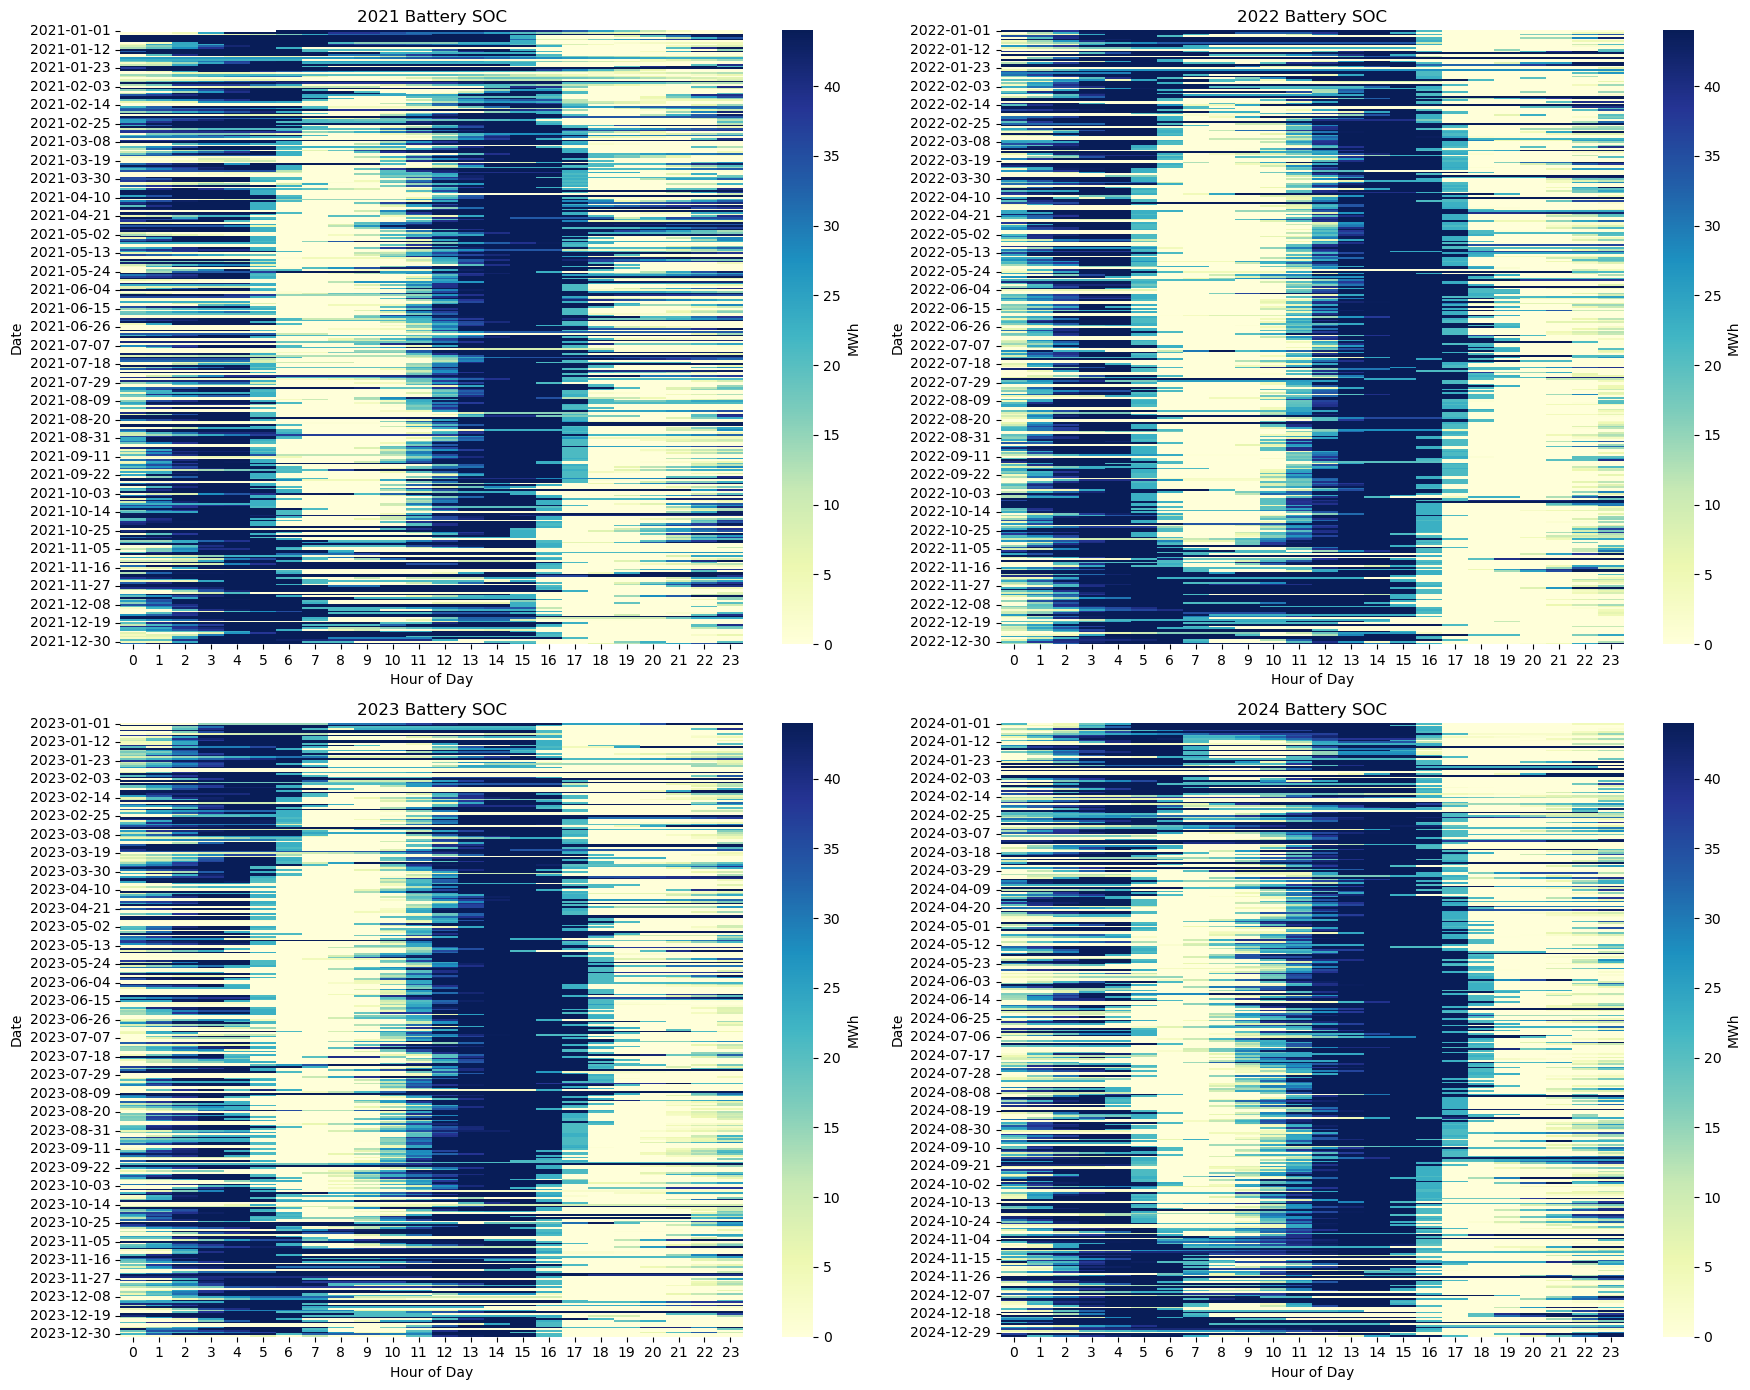

In [291]:


# 2. Create the 2x2 figure
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

# 3. Plot each year with a synchronized scale (0 to 44 MWh)
plot_pypsa_heatmap(n21.storage_units_t.state_of_charge["Skive_Battery"], 
                   title="2021 Battery SOC", unit="MWh", cmap="YlGnBu", 
                   ax=axes[0], vmin=0, vmax=44)

plot_pypsa_heatmap(n22.storage_units_t.state_of_charge["Skive_Battery"], 
                   title="2022 Battery SOC", unit="MWh", cmap="YlGnBu", 
                   ax=axes[1], vmin=0, vmax=44)

plot_pypsa_heatmap(n23.storage_units_t.state_of_charge["Skive_Battery"], 
                   title="2023 Battery SOC", unit="MWh", cmap="YlGnBu", 
                   ax=axes[2], vmin=0, vmax=44)

plot_pypsa_heatmap(n24.storage_units_t.state_of_charge["Skive_Battery"], 
                   title="2024 Battery SOC", unit="MWh", cmap="YlGnBu", 
                   ax=axes[3], vmin=0, vmax=44)

plt.tight_layout()
plt.show()

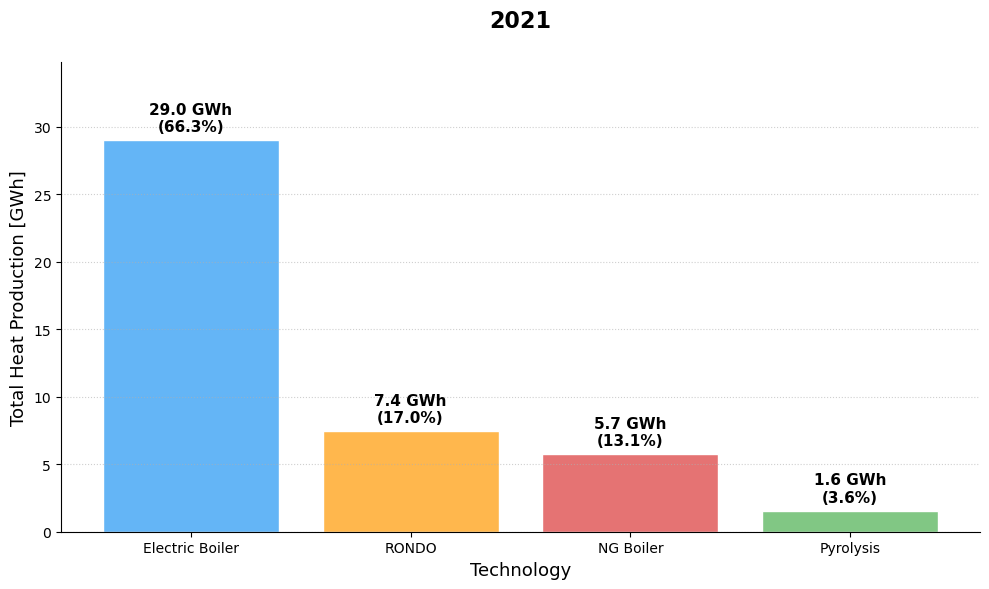

In [230]:
# Summing the hourly MW values gives total MWh; divide by 1000 for GWh
annual_heat = pd.Series({
    "RONDO": (-n21.links_t.p1["Heat_Exchanger_Rondo"]).sum() / 1e3,
    "Electric Boiler": (-n21.links_t.p1["Boiler_Skive"]).sum() / 1e3,
    "NG Boiler": (-n21.links_t.p1["NG boiler"]).sum() / 1e3,
    "Pyrolysis": (-n21.links_t.p1["pyrolysis"]).sum() / 1e3
})

# Calculate percentages for labels
total_gwh = annual_heat.sum()
percentages = (annual_heat / total_gwh * 100).round(1)

# 2. Define Professional Palette (matching your previous plot)
nice_colors = ['#FFB74D', '#64B5F6', '#E57373', '#81C784']

# 3. Create the Bar Chart
fig, ax = plt.subplots(figsize=(10, 6))

# Sort values to show the merit order or largest contributors first
annual_heat_sorted = annual_heat.sort_values(ascending=False)
colors_sorted = [dict(zip(annual_heat.index, nice_colors))[idx] for idx in annual_heat_sorted.index]

bars = ax.bar(annual_heat_sorted.index, annual_heat_sorted.values, color=colors_sorted, edgecolor='white', linewidth=1)

# 4. Add Data Labels (GWh and %)
for bar, pct in zip(bars, percentages[annual_heat_sorted.index]):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + (total_gwh * 0.01),
            f'{height:.1f} GWh\n({pct}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 5. Formatting
plt.title("2021", fontsize=16, fontweight='bold', pad=25)
plt.ylabel("Total Heat Production [GWh]", fontsize=13)
plt.xlabel("Technology", fontsize=13)

# Aesthetic clean-up
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle=':', alpha=0.6)

# Increase y-limit slightly to fit labels
plt.ylim(0, annual_heat_sorted.max() * 1.2)

plt.tight_layout()
plt.show()

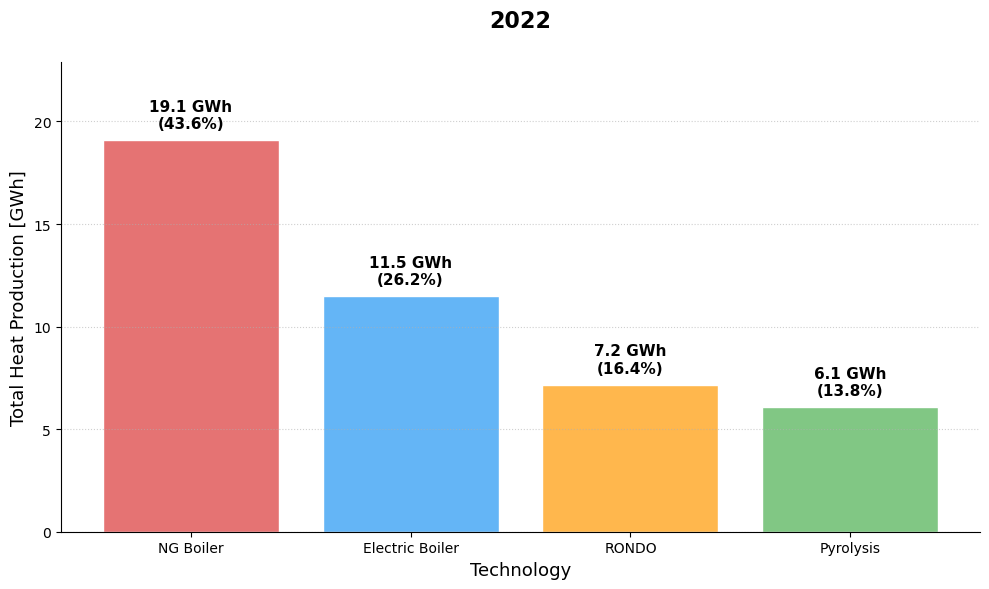

In [232]:
# Summing the hourly MW values gives total MWh; divide by 1000 for GWh
annual_heat = pd.Series({
    "RONDO": (-n22.links_t.p1["Heat_Exchanger_Rondo"]).sum() / 1e3,
    "Electric Boiler": (-n22.links_t.p1["Boiler_Skive"]).sum() / 1e3,
    "NG Boiler": (-n22.links_t.p1["NG boiler"]).sum() / 1e3,
    "Pyrolysis": (-n22.links_t.p1["pyrolysis"]).sum() / 1e3
})

# Calculate percentages for labels
total_gwh = annual_heat.sum()
percentages = (annual_heat / total_gwh * 100).round(1)

# 2. Define Professional Palette (matching your previous plot)
nice_colors = ['#FFB74D', '#64B5F6', '#E57373', '#81C784']

# 3. Create the Bar Chart
fig, ax = plt.subplots(figsize=(10, 6))

# Sort values to show the merit order or largest contributors first
annual_heat_sorted = annual_heat.sort_values(ascending=False)
colors_sorted = [dict(zip(annual_heat.index, nice_colors))[idx] for idx in annual_heat_sorted.index]

bars = ax.bar(annual_heat_sorted.index, annual_heat_sorted.values, color=colors_sorted, edgecolor='white', linewidth=1)

# 4. Add Data Labels (GWh and %)
for bar, pct in zip(bars, percentages[annual_heat_sorted.index]):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + (total_gwh * 0.01),
            f'{height:.1f} GWh\n({pct}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 5. Formatting
plt.title("2022", fontsize=16, fontweight='bold', pad=25)
plt.ylabel("Total Heat Production [GWh]", fontsize=13)
plt.xlabel("Technology", fontsize=13)

# Aesthetic clean-up
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle=':', alpha=0.6)

# Increase y-limit slightly to fit labels
plt.ylim(0, annual_heat_sorted.max() * 1.2)

plt.tight_layout()
plt.show()

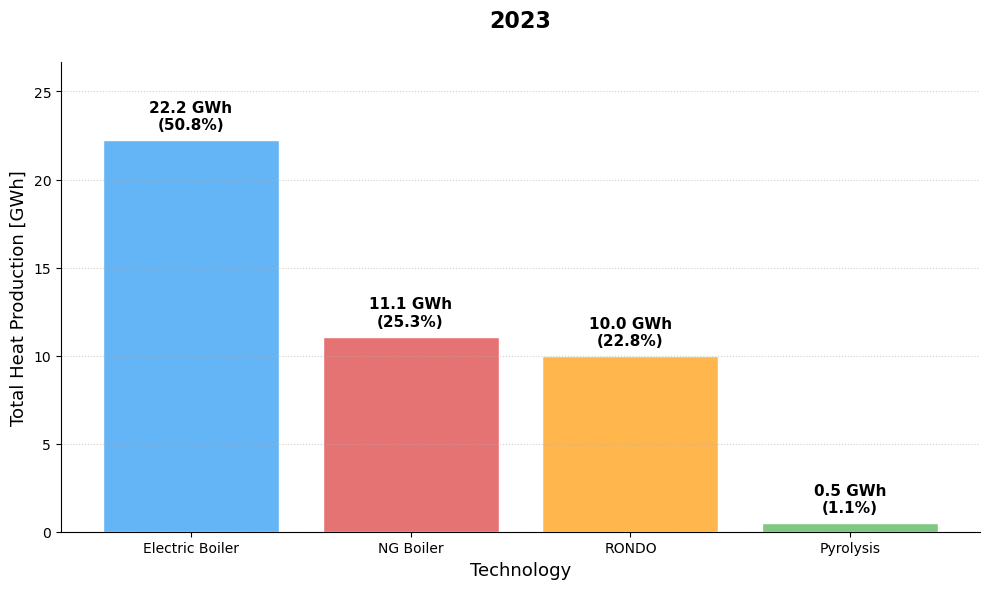

In [233]:
# Summing the hourly MW values gives total MWh; divide by 1000 for GWh
annual_heat = pd.Series({
    "RONDO": (-n23.links_t.p1["Heat_Exchanger_Rondo"]).sum() / 1e3,
    "Electric Boiler": (-n23.links_t.p1["Boiler_Skive"]).sum() / 1e3,
    "NG Boiler": (-n23.links_t.p1["NG boiler"]).sum() / 1e3,
    "Pyrolysis": (-n23.links_t.p1["pyrolysis"]).sum() / 1e3
})

# Calculate percentages for labels
total_gwh = annual_heat.sum()
percentages = (annual_heat / total_gwh * 100).round(1)

# 2. Define Professional Palette (matching your previous plot)
nice_colors = ['#FFB74D', '#64B5F6', '#E57373', '#81C784']

# 3. Create the Bar Chart
fig, ax = plt.subplots(figsize=(10, 6))

# Sort values to show the merit order or largest contributors first
annual_heat_sorted = annual_heat.sort_values(ascending=False)
colors_sorted = [dict(zip(annual_heat.index, nice_colors))[idx] for idx in annual_heat_sorted.index]

bars = ax.bar(annual_heat_sorted.index, annual_heat_sorted.values, color=colors_sorted, edgecolor='white', linewidth=1)

# 4. Add Data Labels (GWh and %)
for bar, pct in zip(bars, percentages[annual_heat_sorted.index]):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + (total_gwh * 0.01),
            f'{height:.1f} GWh\n({pct}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 5. Formatting
plt.title("2023", fontsize=16, fontweight='bold', pad=25)
plt.ylabel("Total Heat Production [GWh]", fontsize=13)
plt.xlabel("Technology", fontsize=13)

# Aesthetic clean-up
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle=':', alpha=0.6)

# Increase y-limit slightly to fit labels
plt.ylim(0, annual_heat_sorted.max() * 1.2)

plt.tight_layout()
plt.show()

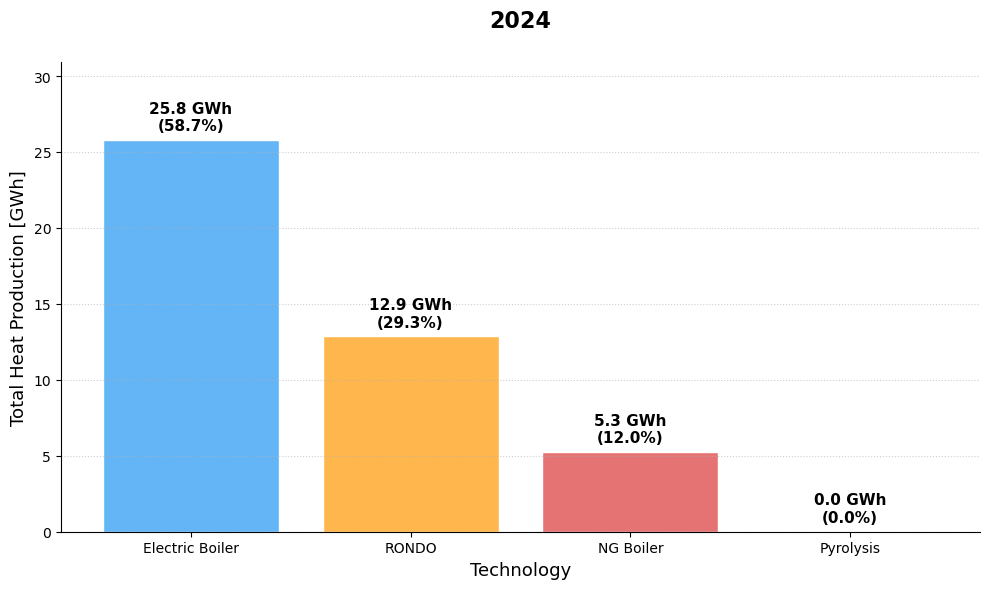

In [234]:
# Summing the hourly MW values gives total MWh; divide by 1000 for GWh
annual_heat = pd.Series({
    "RONDO": (-n24.links_t.p1["Heat_Exchanger_Rondo"]).sum() / 1e3,
    "Electric Boiler": (-n24.links_t.p1["Boiler_Skive"]).sum() / 1e3,
    "NG Boiler": (-n24.links_t.p1["NG boiler"]).sum() / 1e3,
    "Pyrolysis": (-n24.links_t.p1["pyrolysis"]).sum() / 1e3
})

# Calculate percentages for labels
total_gwh = annual_heat.sum()
percentages = (annual_heat / total_gwh * 100).round(1)

# 2. Define Professional Palette (matching your previous plot)
nice_colors = ['#FFB74D', '#64B5F6', '#E57373', '#81C784']

# 3. Create the Bar Chart
fig, ax = plt.subplots(figsize=(10, 6))

# Sort values to show the merit order or largest contributors first
annual_heat_sorted = annual_heat.sort_values(ascending=False)
colors_sorted = [dict(zip(annual_heat.index, nice_colors))[idx] for idx in annual_heat_sorted.index]

bars = ax.bar(annual_heat_sorted.index, annual_heat_sorted.values, color=colors_sorted, edgecolor='white', linewidth=1)

# 4. Add Data Labels (GWh and %)
for bar, pct in zip(bars, percentages[annual_heat_sorted.index]):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + (total_gwh * 0.01),
            f'{height:.1f} GWh\n({pct}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 5. Formatting
plt.title("2024", fontsize=16, fontweight='bold', pad=25)
plt.ylabel("Total Heat Production [GWh]", fontsize=13)
plt.xlabel("Technology", fontsize=13)

# Aesthetic clean-up
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle=':', alpha=0.6)

# Increase y-limit slightly to fit labels
plt.ylim(0, annual_heat_sorted.max() * 1.2)

plt.tight_layout()
plt.show()

<Axes: xlabel='snapshot'>

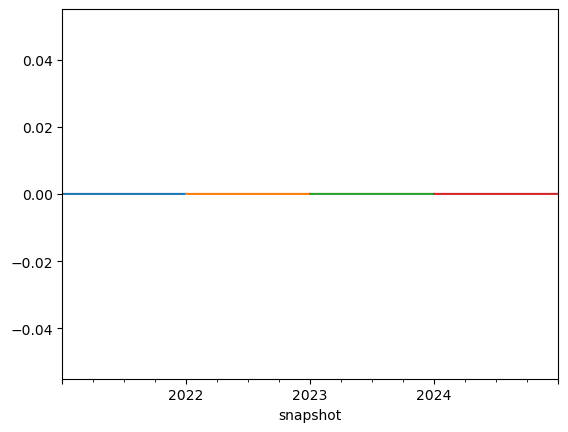

In [280]:
n21.links_t.p0["Electrolyser"].plot()
n22.links_t.p0["Electrolyser"].plot()
n23.links_t.p0["Electrolyser"].plot()
n24.links_t.p0["Electrolyser"].plot()

<Axes: xlabel='snapshot'>

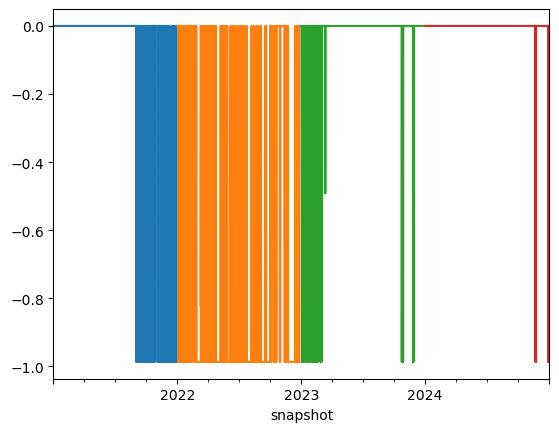

In [235]:
n21.links_t.p1["pyrolysis"].plot()
n22.links_t.p1["pyrolysis"].plot()
n23.links_t.p1["pyrolysis"].plot()
n24.links_t.p1["pyrolysis"].plot()

<Axes: xlabel='snapshot'>

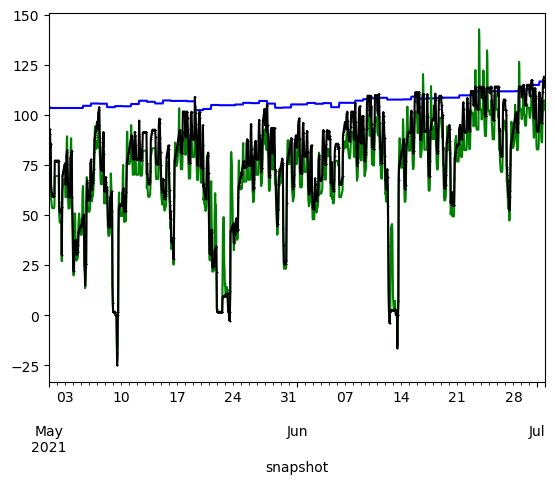

In [317]:
plt.figure()
#n21.buses_t.marginal_price["Heat_Exchanger_Bus"]["2021-05-01":"2021-07-01"].plot(color = "red", label = "MC RONDO")
n21.buses_t.marginal_price["NG"]["2021-05-01":"2021-07-01"].plot(color = "blue")
n21.buses_t.marginal_price["Greenlab"]["2021-05-01":"2021-07-01"].plot(color = "green")
n21.buses_t.marginal_price["Heat_MT"]["2021-05-01":"2021-07-01"].plot(marker = "x", markersize = 0.75,color = "black")

<Axes: xlabel='snapshot'>

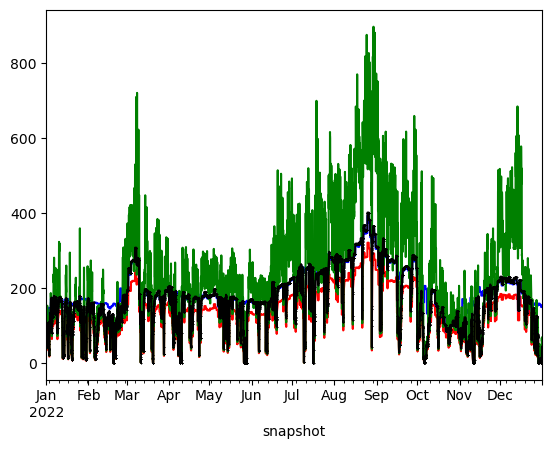

In [322]:
plt.figure()
n22.buses_t.marginal_price["Heat_Exchanger_Bus"].plot(color = "red", label = "MC RONDO")
n22.buses_t.marginal_price["NG"].plot(color = "blue")
n22.buses_t.marginal_price["Greenlab"].plot(color = "green")
n22.buses_t.marginal_price["Heat_MT"].plot(marker = "x", markersize = 0.75,color = "black")

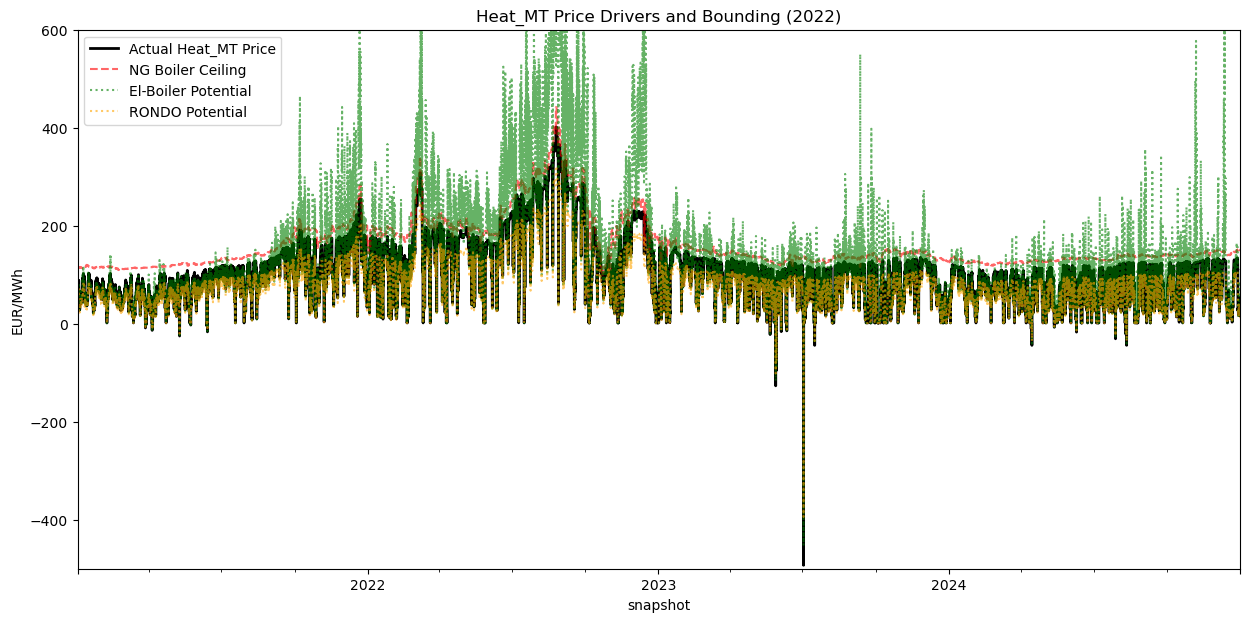

In [340]:
plt.figure(figsize=(15, 7))

# Actual price at the bus
n21.buses_t.marginal_price["Heat_MT"].plot(label="Actual Heat_MT Price", color="black", linewidth=2)
# Theoretical costs (The 'Ceiling' and 'Floor')
# Adjust for efficiency (e.g., 0.9 for gas, 0.98 for electric)
(n21.buses_t.marginal_price["NG"] / 0.9 + 4.88).plot(label="NG Boiler Ceiling", alpha=0.6, linestyle="--", color = "red")
(n21.buses_t.marginal_price["Greenlab"] / 0.98).plot(label="El-Boiler Potential", alpha=0.6, linestyle=":",color = "green")
(n21.buses_t.marginal_price["Heat_Exchanger_Bus"]).plot(label="RONDO Potential", alpha=0.6, linestyle=":", color = "orange")
plt.legend()

n22.buses_t.marginal_price["Heat_MT"].plot(label="Actual Heat_MT Price", color="black", linewidth=2)
(n22.buses_t.marginal_price["NG"] / 0.9 + 4.88).plot(label="NG Boiler Ceiling", alpha=0.6, linestyle="--", color = "red")
(n22.buses_t.marginal_price["Greenlab"] / 0.98).plot(label="El-Boiler Potential", alpha=0.6, linestyle=":",color = "green")
(n22.buses_t.marginal_price["Heat_Exchanger_Bus"]).plot(label="RONDO Potential", alpha=0.6, linestyle=":", color = "orange")


n23.buses_t.marginal_price["Heat_MT"].plot(label="Actual Heat_MT Price", color="black", linewidth=2)
(n23.buses_t.marginal_price["NG"] / 0.9 + 4.88).plot(label="NG Boiler Ceiling", alpha=0.6, linestyle="--", color = "red")
(n23.buses_t.marginal_price["Greenlab"] / 0.98).plot(label="El-Boiler Potential", alpha=0.6, linestyle=":",color = "green")
(n23.buses_t.marginal_price["Heat_Exchanger_Bus"]).plot(label="RONDO Potential", alpha=0.6, linestyle=":", color = "orange")


n24.buses_t.marginal_price["Heat_MT"].plot(label="Actual Heat_MT Price", color="black", linewidth=2)
(n24.buses_t.marginal_price["NG"] / 0.9 + 4.88).plot(label="NG Boiler Ceiling", alpha=0.6, linestyle="--", color = "red")
(n24.buses_t.marginal_price["Greenlab"] / 0.98).plot(label="El-Boiler Potential", alpha=0.6, linestyle=":",color = "green")
(n24.buses_t.marginal_price["Heat_Exchanger_Bus"]).plot(label="RONDO Potential", alpha=0.6, linestyle=":", color = "orange")


plt.ylim(-500,600)

plt.title("Heat_MT Price Drivers and Bounding (2022)")
plt.ylabel("EUR/MWh")
plt.show()

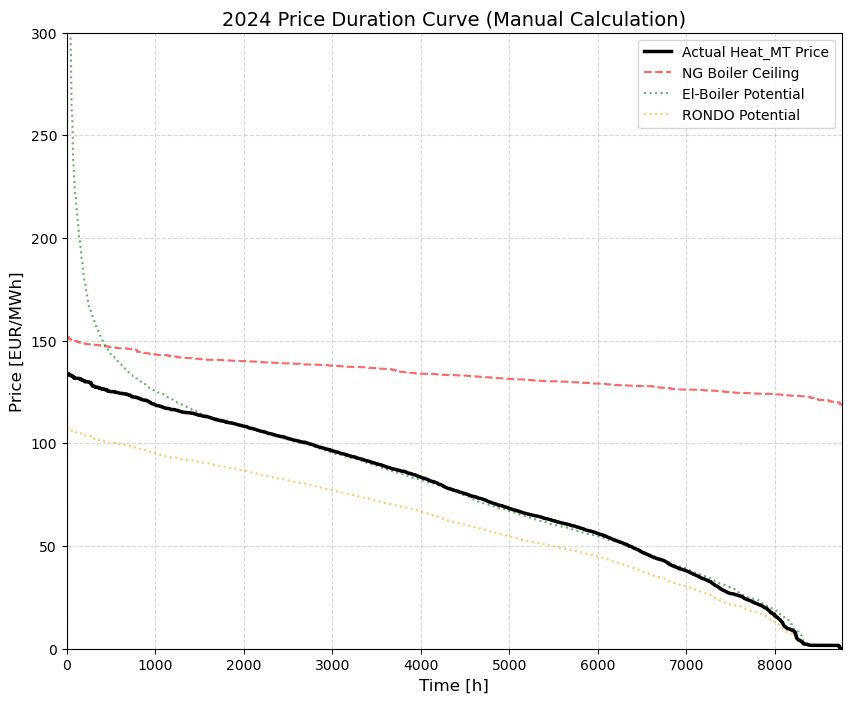

In [377]:
plt.figure(figsize=(10, 8))
plt.plot(n24.buses_t.marginal_price["Heat_MT"].sort_values(ascending=False).values, label="Actual Heat_MT Price", color="black", linewidth=2.5, zorder=5)
plt.plot((n24.buses_t.marginal_price["NG"] / 0.9 + 4.88).sort_values(ascending=False).values, label="NG Boiler Ceiling", color="red", linestyle="--", alpha=0.6)
plt.plot((n24.buses_t.marginal_price["Greenlab"] / 0.98).sort_values(ascending=False).values, label="El-Boiler Potential", color="green", linestyle=":", alpha=0.6)
plt.plot(n24.buses_t.marginal_price["Heat_Exchanger_Bus"].sort_values(ascending=False).values, label="RONDO Potential", color="orange", linestyle=":", alpha=0.6)

# 4. Formatting the manual plot
plt.title("2024 Price Duration Curve (Manual Calculation)", fontsize=14)
plt.xlabel("Time [h]", fontsize=12)
plt.ylabel("Price [EUR/MWh]", fontsize=12)
plt.ylim(0, 300) # Manual Y-limit to keep the focus on relevant prices
plt.xlim(0,8760)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

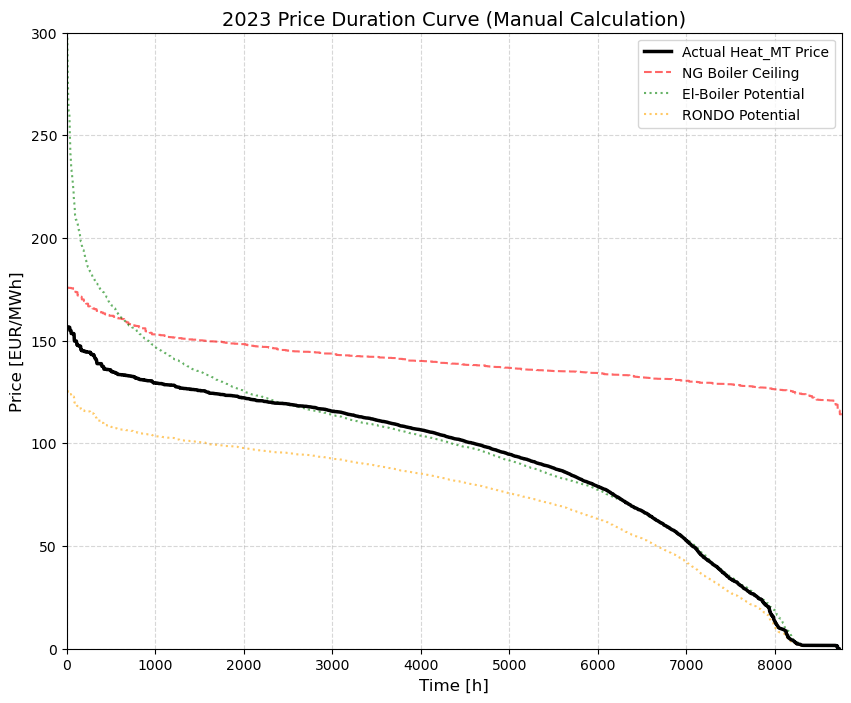

In [376]:
plt.figure(figsize=(10, 8))
plt.plot(n23.buses_t.marginal_price["Heat_MT"].sort_values(ascending=False).values, label="Actual Heat_MT Price", color="black", linewidth=2.5, zorder=5)
plt.plot((n23.buses_t.marginal_price["NG"] / 0.9 + 4.88).sort_values(ascending=False).values, label="NG Boiler Ceiling", color="red", linestyle="--", alpha=0.6)
plt.plot( (n23.buses_t.marginal_price["Greenlab"] / 0.98).sort_values(ascending=False).values, label="El-Boiler Potential", color="green", linestyle=":", alpha=0.6)
plt.plot(n23.buses_t.marginal_price["Heat_Exchanger_Bus"].sort_values(ascending=False).values, label="RONDO Potential", color="orange", linestyle=":", alpha=0.6)

# 4. Formatting the manual plot
plt.title("2023 Price Duration Curve (Manual Calculation)", fontsize=14)
plt.xlabel("Time [h]", fontsize=12)
plt.ylabel("Price [EUR/MWh]", fontsize=12)
plt.ylim(0, 300) # Manual Y-limit to keep the focus on relevant prices
plt.xlim(0,8760)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

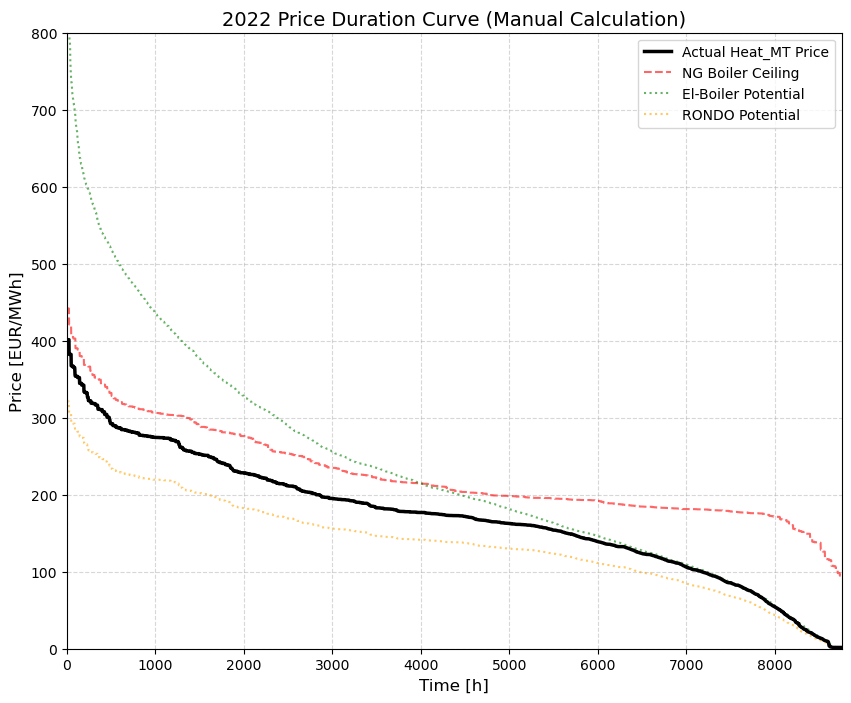

In [380]:
plt.figure(figsize=(10, 8))
plt.plot(n22.buses_t.marginal_price["Heat_MT"].sort_values(ascending=False).values, label="Actual Heat_MT Price", color="black", linewidth=2.5, zorder=5)
plt.plot((n22.buses_t.marginal_price["NG"] / 0.9 + 4.88).sort_values(ascending=False).values, label="NG Boiler Ceiling", color="red", linestyle="--", alpha=0.6)
plt.plot( (n22.buses_t.marginal_price["Greenlab"] / 0.98).sort_values(ascending=False).values, label="El-Boiler Potential", color="green", linestyle=":", alpha=0.6)
plt.plot(n22.buses_t.marginal_price["Heat_Exchanger_Bus"].sort_values(ascending=False).values, label="RONDO Potential", color="orange", linestyle=":", alpha=0.6)

# 4. Formatting the manual plot
plt.title("2022 Price Duration Curve (Manual Calculation)", fontsize=14)
plt.xlabel("Time [h]", fontsize=12)
plt.ylabel("Price [EUR/MWh]", fontsize=12)
plt.ylim(0, 800) # Manual Y-limit to keep the focus on relevant prices
plt.xlim(0,8760)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

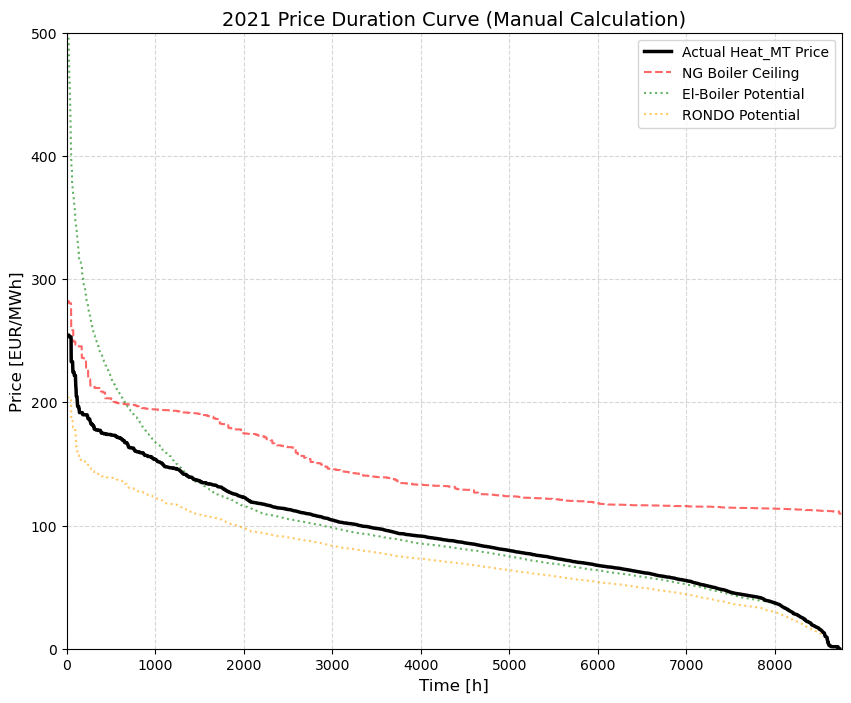

In [375]:
plt.figure(figsize=(10, 8))
plt.plot(n21.buses_t.marginal_price["Heat_MT"].sort_values(ascending=False).values, label="Actual Heat_MT Price", color="black", linewidth=2.5, zorder=5)
plt.plot((n21.buses_t.marginal_price["NG"] / 0.9 + 4.88).sort_values(ascending=False).values, label="NG Boiler Ceiling", color="red", linestyle="--", alpha=0.6)
plt.plot( (n21.buses_t.marginal_price["Greenlab"] / 0.98).sort_values(ascending=False).values, label="El-Boiler Potential", color="green", linestyle=":", alpha=0.6)
plt.plot(n21.buses_t.marginal_price["Heat_Exchanger_Bus"].sort_values(ascending=False).values, label="RONDO Potential", color="orange", linestyle=":", alpha=0.6)

# 4. Formatting the manual plot
plt.title("2021 Price Duration Curve (Manual Calculation)", fontsize=14)
plt.xlabel("Time [h]", fontsize=12)
plt.ylabel("Price [EUR/MWh]", fontsize=12)
plt.ylim(0, 500) # Manual Y-limit to keep the focus on relevant prices
plt.xlim(0,8760)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()